In [3]:
import pandas as pd
from IPython.display import display

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# create a function for summarising values in a dataframe

def summarise_df(df: pd.DataFrame,
                column_info_page_views_and_duration_list:list=column_info_page_views_and_duration_list,
                column_info_google_analytics_list:list=column_info_google_analytics_list, 
                column_info_time_categories_list:list=column_info_time_categories_list) -> list:
    
    # Create four empty dicts according the category groups outlined earlier
    # We will in the loops below add summarised values from each column to these dicts.
    column_info_page_views_and_duration_summary = {}
    column_info_google_analytics_summary = {}
    column_info_time_categories_summary = {}
    column_info_misc_categories_summary = {}

    # Iterate over each column in the session DataFrame
    for col in df.columns:

        # The Pandas API types module provides efficient functions for checking datatypes.
        # First lets check if the column contains numerical values.
        if pd.api.types.is_numeric_dtype(df[col]):

            # Next lets check which category grouping it belongs to.
            if col in column_info_page_views_and_duration_list:

                # For numerical regression data we want to know the max, min, mean values and the standard deviation
                column_info_page_views_and_duration_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'max_value' : df[col].max(),
                                    'min_value' : df[col].min(),
                                    'mean_value' : df[col].mean(),
                                    'standard_deviation' : df[col].std()
                                    }
                
            elif col in column_info_google_analytics_list:

                column_info_google_analytics_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'max_value' : df[col].max(),
                                    'min_value' : df[col].min(),
                                    'mean_value' : df[col].mean(),
                                    'standard_deviation' : df[col].std()
                                    }
                
            elif col in column_info_time_categories_list:

                column_info_time_categories_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'max_value' : df[col].max(),
                                    'min_value' : df[col].min(),
                                    'mean_value' : df[col].mean(),
                                    'standard_deviation' : df[col].std()
                                    }
            else:
                # For classification data, numerical or object, we want to know the unique values, their counts (including NaNs!) and top & bottom
                list_of_tuples_of_key_value_pairs_from_value_counts = [(key, int(value)) for key, value in df[col].value_counts(dropna=False).to_dict().items()]
                column_info_misc_categories_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'unique_values' : df[col].unique(),
                                    'value_counts' : list_of_tuples_of_key_value_pairs_from_value_counts,
                                    'top_value' : list_of_tuples_of_key_value_pairs_from_value_counts[0],
                                    'bottom_value' : list_of_tuples_of_key_value_pairs_from_value_counts[-1]
                                    }
        
        else:
            list_of_tuples_of_key_value_pairs_from_value_counts = [(key, int(value)) for key, value in df[col].value_counts(dropna=False).to_dict().items()]
            column_info_misc_categories_summary[col] = {
                                    'data_type' : df[col].dtype,
                                    'unique_values' : df[col].unique(),
                                    'value_counts' : list_of_tuples_of_key_value_pairs_from_value_counts,
                                    'top_value' : list_of_tuples_of_key_value_pairs_from_value_counts[0],
                                    'bottom_value' : list_of_tuples_of_key_value_pairs_from_value_counts[-1]
                                    }

    # convert summary dicts into dataframes for better visualisation   
    page_views_and_duration_summary_df = pd.DataFrame(column_info_page_views_and_duration_summary)  
    column_info_google_analytics_summary_df = pd.DataFrame(column_info_google_analytics_summary)
    column_info_time_categories_summary_df = pd.DataFrame(column_info_time_categories_summary)
    column_info_misc_categories_summary_df = pd.DataFrame(column_info_misc_categories_summary)

    summary_dfs_list = [page_views_and_duration_summary_df, column_info_google_analytics_summary_df, column_info_time_categories_summary_df, column_info_misc_categories_summary_df]
    
    # display dataframes with HTML in notebooks using the display method
    for df in summary_dfs_list:

        display(df)
    # display(page_views_and_duration_summary_df)
    # display(column_info_google_analytics_summary_df)
    # display(column_info_time_categories_summary_df)
    # display(column_info_misc_categories_summary_df)

    return summary_dfs_list

In [24]:
session_data_df = pd.read_csv('project_data.csv')

column_descriptions = {
                    "Administrative" : "Number of page visits within this category",
                    "Administrative_Duration" : "Time spent within this category",
                    "Informational" : "Number of page visits within this category",
                    "Informational_Duration" : "Time spent within this category", 
                    "ProductRelated" : "Number of page visits within this category", 
                    "ProductRelated_Duration" : "Time spent within this category",
                    "BounceRates" : "Bounce rate of current page",
                    "ExitRates" : "Exit rate value of current page",
                    "PageValues" : "Page value of current page",
                    "SpecialDay" : "Proximity in time of the session to a special day (e.g. Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina’s day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.",
                    "Month" : "Month of session",
                    "Weekend" : "Boolean if the session day was in the weekend",
                    "OperatingSystems" : "Different OS' represented by different integers",
                    "Browser" : "Different browsers represented by different integers",
                    "Region" : "Different regions represented by different integers",
                    "TrafficType" : "Different traffic types represented by different integers",
                    "VisitorType" :  "Different visitor types represented by different categorical values",
                    }

column_info_page_views_and_duration_list = ['Administrative', 'Administrative_Duration', 'Informational','Informational_Duration', 'ProductRelated','ProductRelated_Duration']
column_info_google_analytics_list = ['BounceRates','ExitRates','PageValues']
column_info_time_categories_list = ['SpecialDay', 'Month', 'Weekend']
column_info_misc_categories_list = ['OperatingSystems','Browser','Region','TrafficType','VisitorType']
  

In [25]:
summarise_df(session_data_df, column_info_page_views_and_duration_list, column_info_google_analytics_list, column_info_time_categories_list)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,27,989493.0,24,2549.375,705,63973.52223
min_value,-10,0.0,0,0.0,0,0.0
mean_value,2.2382,1269.776004,0.503569,34.472398,31.731468,1194.74622
standard_deviation,3.409269,34071.46693,1.270156,140.749294,44.475503,1913.669288


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,2.098952,0.2,361.763742
min_value,-0.49868,0.0,0.0
mean_value,0.044239,0.043073,5.889258
standard_deviation,0.239735,0.048597,18.568437


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.06126
standard_deviation,0.19865


,Unnamed: 0,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,int64,object,int64,float64,float64,int64,object,object,object
unique_values,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[Feb, Mar, May, Turc, Oct, June, Jul, Aug, Nov...","[1, 2, 4, 3, 7, 6, 8, 5]","[nan, 2.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 10.0,...","[1.0, nan, 2.0, 3.0, 4.0, 9.0, 5.0, 6.0, 7.0, ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[Returning_Visitor, New_Visitor, Other]","[False, True, Name:Zara]","[False, nan, True]"
value_counts,"[(12329, 1), (0, 1), (1, 1), (2, 1), (3, 1), (...","[(May, 3196), (Nov, 2998), (Mar, 1907), (Dec, ...","[(2, 6601), (1, 2585), (3, 2555), (4, 478), (8...","[(2.0, 7835), (1.0, 2424), (4.0, 725), (5.0, 4...","[(1.0, 4695), (3.0, 2345), (4.0, 1157), (2.0, ...","[(2, 3913), (1, 2451), (3, 2052), (4, 1069), (...","[(Returning_Visitor, 10551), (New_Visitor, 169...","[(False, 9273), (True, 2868), (Name:Zara, 189)]","[(False, 10303), (True, 1880), (nan, 147)]"
top_value,"(12329, 1)","(May, 3196)","(2, 6601)","(2.0, 7835)","(1.0, 4695)","(2, 3913)","(Returning_Visitor, 10551)","(False, 9273)","(False, 10303)"
bottom_value,"(10, 1)","(Sept, 89)","(5, 6)","(9.0, 1)","(nan, 246)","(17, 1)","(Other, 85)","(Name:Zara, 189)","(nan, 147)"


[                   Administrative Administrative_Duration Informational  \
 data_type                   int64                 float64         int64   
 max_value                      27                989493.0            24   
 min_value                     -10                     0.0             0   
 mean_value                 2.2382             1269.776004      0.503569   
 standard_deviation       3.409269             34071.46693      1.270156   
 
                    Informational_Duration ProductRelated  \
 data_type                         float64          int64   
 max_value                        2549.375            705   
 min_value                             0.0              0   
 mean_value                      34.472398      31.731468   
 standard_deviation             140.749294      44.475503   
 
                    ProductRelated_Duration  
 data_type                          float64  
 max_value                      63973.52223  
 min_value                          

In [26]:
def analyze_negative_values(df, column_name, target_column='Revenue'):
    """
    Analyze rows with negative values in a specified column.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to analyze
    column_name : str
        The column to check for negative values
    target_column : str, default='Revenue'
        The target column to analyze conversion rates
        
    Returns:
    --------
    tuple
        (df with negative values, df with positive values, row indices to remove)
    """
    # Create filter for negative values
    neg_values_filter = df[column_name] < 0
    
    # Get dataframes with negative and positive values
    neg_values_df = df[neg_values_filter]
    pos_values_df = df[~neg_values_filter]
    
    # Print basic statistics
    total_rows = len(df)
    neg_rows = len(neg_values_df)
    neg_pct = round(neg_rows / total_rows, 4)
    
    print(f"Found {neg_rows} rows with negative values in {column_name} ({neg_pct * 100}% of all data)")
    
    # Check target column distribution if it exists
    if target_column in df.columns:
        target_total = len(df[df[target_column] == True])
        target_neg = len(neg_values_df[neg_values_df[target_column] == True])
        target_pct = round(target_neg / target_total, 4)
        
        print(f"Of these, {target_neg} are conversions ({target_pct * 100}% of all conversions)")
    
    # Summarize the negative value rows
    print("\nSummary of rows with negative values:")
    summarise_df(neg_values_df)
    
    # If numeric column, compare metrics
    if pd.api.types.is_numeric_dtype(df[column_name]):
        # Create "per-unit" measures if applicable
        # This is specific to each column and would need customization
        
        if column_name.endswith('_Duration'):
            # For duration columns, calculate duration per page view
            base_col = column_name.replace('_Duration', '')
            
            # For positive values
            pos_values_df['Per unit metric'] = pos_values_df[column_name] / pos_values_df[base_col].replace(0, np.nan)
            pos_mean = round(pos_values_df['Per unit metric'].mean(), 4)
            
            # For negative values - make them positive for calculation
            temp_neg_df = neg_values_df.copy()
            temp_neg_df[column_name] = temp_neg_df[column_name].abs()
            temp_neg_df['Per unit metric'] = temp_neg_df[column_name] / temp_neg_df[base_col].replace(0, np.nan)
            neg_mean = round(temp_neg_df['Per unit metric'].mean(), 4)
            
            print(f"\nMean {column_name} per {base_col}:")
            print(f"- Positive rows: {pos_mean}")
            print(f"- Negative rows (absolute): {neg_mean}")
            print(f"- Ratio: {round(pos_mean / neg_mean, 4)}")
        else:
            # For other numeric columns, just compare basic stats
            pos_mean = round(pos_values_df[column_name].mean(), 4)
            neg_mean_abs = round(neg_values_df[column_name].abs().mean(), 4)
            
            print(f"\nMean {column_name}:")
            print(f"- Positive rows: {pos_mean}")
            print(f"- Negative rows (absolute): {neg_mean_abs}")
    
    # Get indices of negative rows for potential removal
    rows_with_neg_values_ids = neg_values_df.index
    
    return neg_values_df, pos_values_df, rows_with_neg_values_ids

In [27]:
column_info_page_views_and_duration_list = ['Administrative', 'Administrative_Duration', 'Informational','Informational_Duration', 'ProductRelated','ProductRelated_Duration']
column_info_google_analytics_list = ['BounceRates','ExitRates','PageValues']
column_info_time_categories_list = ['SpecialDay', 'Month', 'Weekend']
column_info_misc_categories_list = ['OperatingSystems','Browser','Region','TrafficType','VisitorType']

In [28]:
analyze_negative_values(session_data_df, 'Administrative')

Found 123 rows with negative values in Administrative (1.0% of all data)
Of these, 16 are conversions (0.8500000000000001% of all conversions)

Summary of rows with negative values:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
data_type,int64,float64,int64,float64,int64,float64
max_value,-1,1028.833333,9,1779.166667,338,13265.35595
min_value,-10,0.0,0,0.0,1,0.0
mean_value,-5.642276,68.211843,0.536585,63.774797,31.113821,1120.042206
standard_deviation,2.716465,150.812857,1.338538,261.488216,45.460161,1802.345859


,BounceRates,ExitRates,PageValues
data_type,float64,float64,float64
max_value,1.80952,0.2,120.587914
min_value,-0.38211,0.003226,0.0
mean_value,0.066005,0.047877,4.659112
standard_deviation,0.268121,0.055342,16.330311


,SpecialDay
data_type,float64
max_value,1.0
min_value,0.0
mean_value,0.112605
standard_deviation,0.261208


,Unnamed: 0,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
data_type,int64,object,int64,float64,float64,int64,object,object,object
unique_values,"[143, 149, 150, 190, 201, 223, 268, 315, 329, ...","[Feb, Mar, Turc, May, June, Oct, Aug, Jul, Nov...","[2, 1, 3, 8]","[2.0, nan, 1.0, 4.0, 6.0, 5.0, 10.0, 8.0]","[2.0, 1.0, nan, 4.0, 3.0, 7.0, 6.0, 9.0, 5.0, ...","[3, 1, 9, 8, 2, 10, 6, 7, 13, 4, 20, 5, 11]","[Returning_Visitor, New_Visitor]","[False, True, Name:Zara]","[False, True, nan]"
value_counts,"[(143, 1), (149, 1), (150, 1), (190, 1), (201,...","[(May, 34), (Nov, 30), (Mar, 27), (Dec, 13), (...","[(2, 63), (1, 35), (3, 24), (8, 1)]","[(2.0, 75), (1.0, 30), (4.0, 8), (5.0, 4), (8....","[(1.0, 52), (3.0, 22), (2.0, 12), (4.0, 11), (...","[(2, 37), (1, 23), (3, 21), (13, 9), (4, 8), (...","[(Returning_Visitor, 106), (New_Visitor, 17)]","[(False, 103), (True, 19), (Name:Zara, 1)]","[(False, 106), (True, 16), (nan, 1)]"
top_value,"(143, 1)","(May, 34)","(2, 63)","(2.0, 75)","(1.0, 52)","(2, 37)","(Returning_Visitor, 106)","(False, 103)","(False, 106)"
bottom_value,"(12133, 1)","(Sep, 1)","(8, 1)","(10.0, 1)","(8.0, 2)","(5, 1)","(New_Visitor, 17)","(Name:Zara, 1)","(nan, 1)"



Mean Administrative:
- Positive rows: 2.3176
- Negative rows (absolute): 5.6423


(       Unnamed: 0  Administrative  Administrative_Duration  Informational  \
 143           143              -3                 0.000000              0   
 149           149              -8                 0.000000              0   
 150           150              -1                 0.000000              0   
 190           190              -7                 0.000000              0   
 201           201             -10                 0.000000              0   
 ...           ...             ...                      ...            ...   
 11537       11537              -6              1028.833333              1   
 11632       11632             -10                64.500000              0   
 11675       11675              -5                 0.000000              0   
 11905       11905              -9                 0.000000              1   
 12133       12133              -8                97.000000              3   
 
        Informational_Duration  ProductRelated  ProductRelated

<Axes: xlabel='Revenue', ylabel='Administrative'>

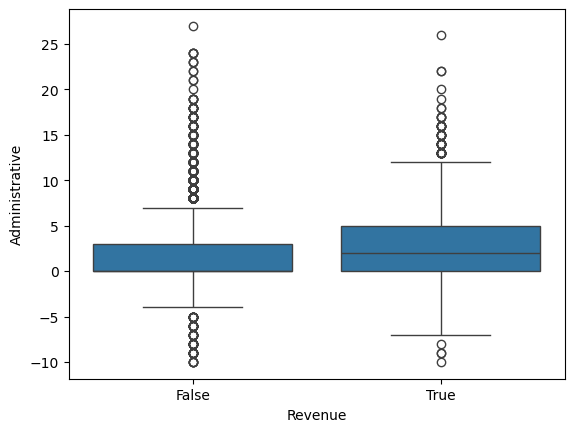

In [7]:
sns.boxplot(data=session_data_df, x='Revenue', y='Administrative')

In [8]:
test_dict = {'A' : {'Value': 2, 'Value': 4}, "B" : {'Value': 3, 'Value': 6}}

In [9]:
pd.DataFrame(test_dict)

,A,B
Value,4,6


In [10]:
test_dict = {'A' : [None, 4, -6], "B" : [4, None, 9]}

In [11]:
test_dict_df = pd.DataFrame(test_dict)

test_dict_df


,A,B
0,NaN,4.0
1,4.0,NaN
2,-6.0,9.0


In [12]:
test_dict_df.loc[test_dict_df['A'] < 0, 'A'] = test_dict_df.loc[test_dict_df['A'] < 0, 'A'] * -1

In [13]:
test_dict_df

,A,B
0,NaN,4.0
1,4.0,NaN
2,6.0,9.0


In [16]:
fill_nans_with = {'A' : 0, 'B' : 'Unknown'}

In [17]:
test_dict_df.fillna(fill_nans_with)

,A,B
0,0.0,4.0
1,4.0,Unknown
2,6.0,9.0


In [18]:
test_dict_df

,A,B
0,NaN,4.0
1,4.0,NaN
2,6.0,9.0


In [14]:
test_dict_df.drop(test_dict_df[test_dict_df['A'] == 2].index, axis=0, inplace=True)

In [15]:
test_dict_df

,A,B
0,NaN,4.0
1,4.0,NaN
2,6.0,9.0


In [139]:
test_dict_df.dropna(subset='A')

,A,B
1,4.0,8
2,6.0,9


In [128]:
test_dict_df[test_dict_df['A'] == 2]

,A,B
0,2,4


In [29]:
# Dictionary with all the columns + description of each. The decription in the dict is my interpretation of the source
# documentation which was sparse on column descriptions.
column_descriptions = {
    "Administrative": {
        "description": "Number of page visits within this category",
        "type": "numeric",
        "data_type": "int64"
    },
    "Administrative_Duration": {
        "description": "Time spent within this category",
        "type": "numeric",
        "data_type": "float64"
    },
    "Informational": {
        "description": "Number of page visits within this category",
        "type": "numeric",
        "data_type": "int64"
    },
    "Informational_Duration": {
        "description": "Time spent within this category",
        "type": "numeric",
        "data_type": "float64"
    },
    "ProductRelated": {
        "description": "Number of page visits within this category",
        "type": "numeric",
        "data_type": "int64"
    },
    "ProductRelated_Duration": {
        "description": "Time spent within this category",
        "type": "numeric",
        "data_type": "float64"
    },
    "BounceRates": {
        "description": "Bounce rate of current page",
        "type": "numeric",
        "data_type": "float64"
    },
    "ExitRates": {
        "description": "Exit rate value of current page",
        "type": "numeric",
        "data_type": "float64"
    },
    "PageValues": {
        "description": "Page value of current page",
        "type": "numeric",
        "data_type": "float64"
    },
    "SpecialDay": {
        "description": "Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.",
        "type": "numeric",
        "data_type": "float64"
    },
    "Month": {
        "description": "Month of session",
        "type": "categorical",
        "data_type": "object"
    },
    "Weekend": {
        "description": "Boolean if the session day was in the weekend",
        "type": "categorical",
        "data_type": "object" 
    },
    "OperatingSystems": {
        "description": "Different OS' represented by different integers",
        "type": "categorical",  
        "data_type": "int64"
    },
    "Browser": {
        "description": "Different browsers represented by different integers",
        "type": "categorical",  
        "data_type": "float64" 
    },
    "Region": {
        "description": "Different regions represented by different integers",
        "type": "categorical", 
        "data_type": "float64"  
    },
    "TrafficType": {
        "description": "Different traffic types represented by different integers",
        "type": "categorical",  
        "data_type": "int64"
    },
    "VisitorType": {
        "description": "Different visitor types represented by different categorical values",
        "type": "categorical",
        "data_type": "object"
    },
    "Revenue": {
        "description": "Whether revenue was generated during this session (target variable)",
        "type": "categorical",
        "data_type": "object" 
    }
}

# Lists grouping together columns of similar kind.
column_info_page_views_and_duration_list = ['Administrative', 'Administrative_Duration', 'Informational','Informational_Duration', 'ProductRelated','ProductRelated_Duration']
column_info_google_analytics_list = ['BounceRates','ExitRates','PageValues']
column_info_time_categories_list = ['SpecialDay', 'Month', 'Weekend']
column_info_misc_categories_list = ['OperatingSystems','Browser','Region','TrafficType','VisitorType']

In [30]:
def plot_feature_eda(df, column_descriptions, figsize=(18, 6), revenue_col='Revenue'):
    """
    Generates exploratory data analysis plots for each feature in the dataset.
    
    For each feature, creates a pair of relevant plots based on its data type:
    - Numeric features: Distribution plot and relationship with target
    - Categorical features: Count plot and relationship with target
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing all features
    column_descriptions : dict
        Dictionary with feature descriptions and types
    figsize : tuple, optional (default=(18, 6))
        Width, height of each row of plots
    revenue_col : str, optional (default='Revenue')
        Name of the target variable column
        
    Returns:
    --------
    None. Displays plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from scipy import stats
    
    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue  # Skip the target variable
            
        if isinstance(info, dict):  # If using the structured dictionary format
            if info["type"] == "numeric":
                numeric_features.append(col)
            else:
                categorical_features.append(col)
        else:  # If using the string-based format
            if "Type: numeric" in info:
                numeric_features.append(col)
            else:
                categorical_features.append(col)
    
    # Function to create plots for numeric features
    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Left plot: Distribution with KDE
        sns.histplot(df[feature].dropna(), kde=True, ax=axes[0])
        axes[0].set_title(f'Distribution of {feature}')
        axes[0].set_xlabel(feature)
        
        # Add mean and median lines
        mean_val = df[feature].mean()
        median_val = df[feature].median()
        axes[0].axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axes[0].axvline(median_val, color='g', linestyle='-.', label=f'Median: {median_val:.2f}')
        axes[0].legend()
        
        # Right plot: Box plot by Revenue
        sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
        axes[1].set_title(f'{feature} by {revenue_col}')
        
        # Add statistical test for significance
        try:
            true_vals = df[df[revenue_col] == True][feature].dropna()
            false_vals = df[df[revenue_col] == False][feature].dropna()
            
            if len(true_vals) > 0 and len(false_vals) > 0:
                t_stat, p_val = stats.ttest_ind(true_vals, false_vals, equal_var=False)
                axes[1].set_xlabel(f'{revenue_col} (t-test p-value: {p_val:.4f})')
                
                # Add means for each group
                axes[1].text(0, df[feature].max() * 0.95, 
                         f'Mean: {false_vals.mean():.2f}', 
                         ha='center', fontweight='bold')
                axes[1].text(1, df[feature].max() * 0.95, 
                         f'Mean: {true_vals.mean():.2f}', 
                         ha='center', fontweight='bold')
        except:
            pass
            
        plt.tight_layout()
        plt.show()
    
    # Function to create plots for categorical features
    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Left plot: Count plot
        value_counts = df[feature].value_counts().sort_values(ascending=False)
        sns.countplot(y=feature, data=df, order=value_counts.index, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)
        
        # Add percentage labels
        total = len(df)
        for i, p in enumerate(axes[0].patches):
            percentage = f'{100 * p.get_width() / total:.1f}%'
            axes[0].annotate(percentage, (p.get_width(), p.get_y() + p.get_height()/2),
                            va='center', ha='left', fontsize=10, color='black', xytext=(5, 0),
                            textcoords='offset points')
        
        # Right plot: Stacked percentage bar chart by Revenue
        pivot = pd.crosstab(df[feature], df[revenue_col], normalize='index') * 100
        pivot.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2')
        axes[1].set_title(f'Conversion Rate by {feature}')
        axes[1].set_xlabel('Percentage (%)')
        axes[1].set_ylabel(feature)
        
        # Add conversion rate labels
        if True in pivot.columns:
            for i, (idx, row) in enumerate(pivot.iterrows()):
                if True in row.index:
                    conversion_rate = f'{row[True]:.1f}%'
                    axes[1].text(row[True] / 2, i, conversion_rate, 
                                va='center', ha='center', fontsize=10, color='white', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
    # Function to handle special cases
    def plot_feature(feature):
        print(f"\n{'='*50}")
        
        # Extract and print feature description
        if isinstance(column_descriptions[feature], dict):
            desc = column_descriptions[feature]["description"]
        else:
            desc = column_descriptions[feature].split("Type:")[0].strip()
            
        print(f"Feature: {feature}")
        print(f"Description: {desc}")
        print(f"Data Shape: {df[feature].shape}")
        print(f"Missing Values: {df[feature].isna().sum()} ({df[feature].isna().mean():.2%})")
        
        if feature in numeric_features:
            # Print summary statistics
            stats_df = pd.DataFrame({
                'Min': df[feature].min(),
                'Max': df[feature].max(),
                'Mean': df[feature].mean(),
                'Median': df[feature].median(),
                'Std Dev': df[feature].std(),
                'Skew': df[feature].skew()
            }, index=[0])
            print("\nSummary Statistics:")
            print(stats_df.to_string(index=False))
            
            plot_numeric_feature(feature)
        else:
            # Print frequency statistics
            value_counts = df[feature].value_counts()
            print("\nTop 5 Categories:")
            print(value_counts.head(5).to_string())
            
            plot_categorical_feature(feature)
    
    # Plot each numeric feature first
    for feature in numeric_features:
        plot_feature(feature)
    
    # Then plot each categorical feature
    for feature in categorical_features:
        plot_feature(feature)


Feature: Administrative
Description: Number of page visits within this category
Data Shape: (12330,)
Missing Values: 0 (0.00%)

Summary Statistics:
 Min  Max   Mean  Median  Std Dev     Skew
 -10   27 2.2382     1.0 3.409269 1.694161


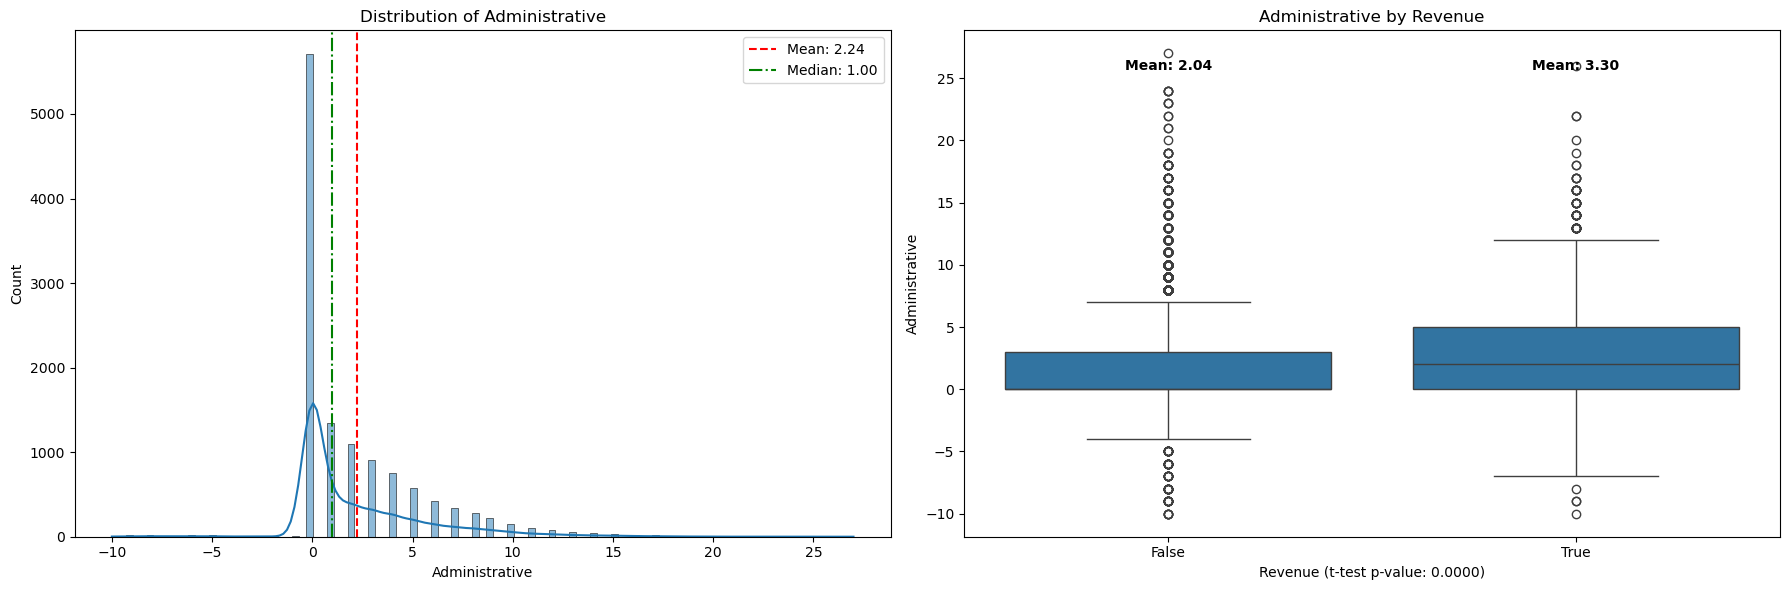


Feature: Administrative_Duration
Description: Time spent within this category
Data Shape: (12330,)
Missing Values: 0 (0.00%)

Summary Statistics:
 Min      Max        Mean  Median     Std Dev      Skew
 0.0 989493.0 1269.776004     8.0 34071.46693 28.623477


KeyboardInterrupt: 

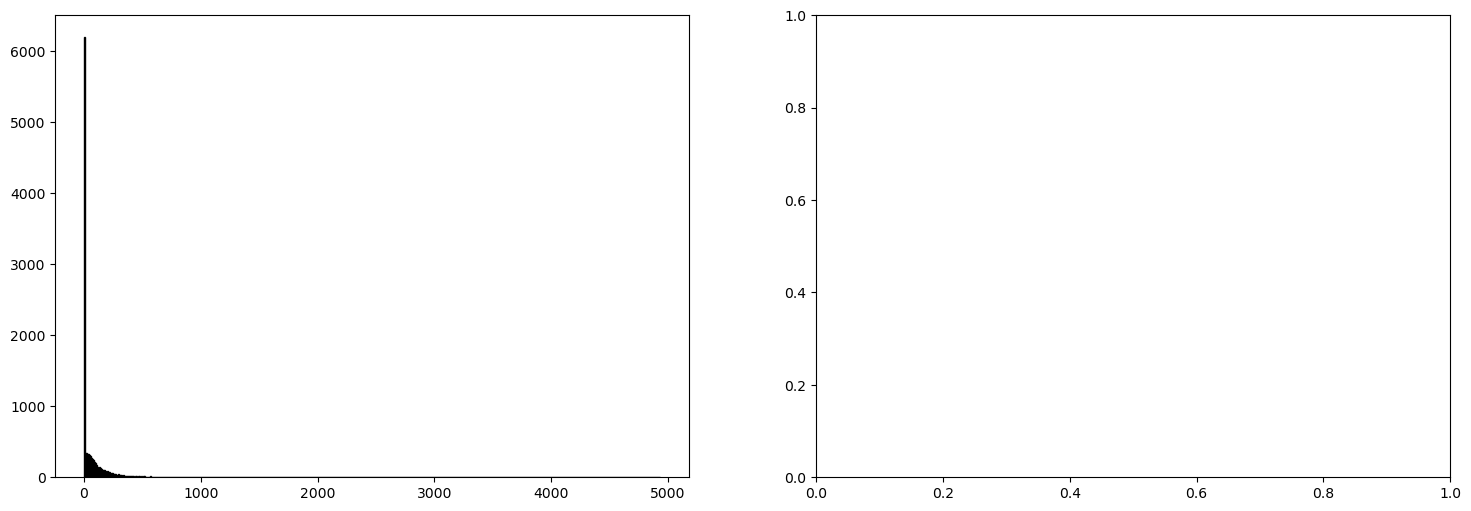

In [32]:
plot_feature_eda(session_data_df, column_descriptions)

In [33]:
def plot_feature_eda(df, column_descriptions, figsize=(16, 5), revenue_col='Revenue', n_cols=2):
    """
    Generates lightweight exploratory data analysis plots for each feature in the dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing all features
    column_descriptions : dict
        Dictionary with feature descriptions and types
    figsize : tuple, optional (default=(16, 5))
        Width, height of each row of plots
    revenue_col : str, optional (default='Revenue')
        Name of the target variable column
    n_cols : int, optional (default=2)
        Number of columns in the subplot grid
        
    Returns:
    --------
    None. Displays plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    
    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue  # Skip the target variable
            
        if isinstance(info, dict):  # If using the structured dictionary format
            if info["type"] == "numeric":
                numeric_features.append(col)
            else:
                categorical_features.append(col)
        else:  # If using the string-based format
            if "Type: numeric" in info:
                numeric_features.append(col)
            else:
                categorical_features.append(col)
    
    # Function to create plots for numeric features
    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Simple histogram
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[0])
        axes[0].set_title(f'Distribution of {feature}')
        axes[0].set_xlabel(feature)
        
        # Right plot: Box plot by Revenue
        sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
        axes[1].set_title(f'{feature} by {revenue_col}')
            
        plt.tight_layout()
        plt.show()
    
    # Function to create plots for categorical features
    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Simple count plot
        top_categories = df[feature].value_counts().nlargest(10).index
        temp_df = df.copy()
        temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'
        sns.countplot(y=feature, data=temp_df, order=temp_df[feature].value_counts().index, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)
        
        # Right plot: Stacked bar chart by Revenue
        pd.crosstab(df[feature], df[revenue_col], normalize='index').plot(
            kind='barh', stacked=True, ax=axes[1], colormap='viridis'
        )
        axes[1].set_title(f'Conversion Rate by {feature}')
        axes[1].set_xlabel('Proportion')
        axes[1].set_ylabel(feature)
        
        plt.tight_layout()
        plt.show()
    
    # Function to show basic stats before plotting
    def plot_feature(feature):
        print(f"\n{'='*40}")
        
        # Extract and print feature description
        if isinstance(column_descriptions[feature], dict):
            desc = column_descriptions[feature]["description"]
        else:
            desc = column_descriptions[feature].split("Type:")[0].strip()
            
        print(f"Feature: {feature}")
        print(f"Description: {desc}")
        print(f"Missing Values: {df[feature].isna().sum()} ({df[feature].isna().mean():.2%})")
        
        if feature in numeric_features:
            # Print only basic summary statistics
            stats_df = pd.DataFrame({
                'Min': df[feature].min(),
                'Max': df[feature].max(),
                'Mean': df[feature].mean(),
                'Median': df[feature].median()
            }, index=[0])
            print("\nBasic Statistics:")
            print(stats_df.to_string(index=False))
            
            plot_numeric_feature(feature)
        else:
            # Print only top categories
            value_counts = df[feature].value_counts()
            print("\nTop 5 Categories:")
            print(value_counts.head(5).to_string())
            
            plot_categorical_feature(feature)
    
    # Plot each feature
    for feature in numeric_features + categorical_features:
        plot_feature(feature)


Feature: Administrative
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max   Mean  Median
 -10   27 2.2382     1.0


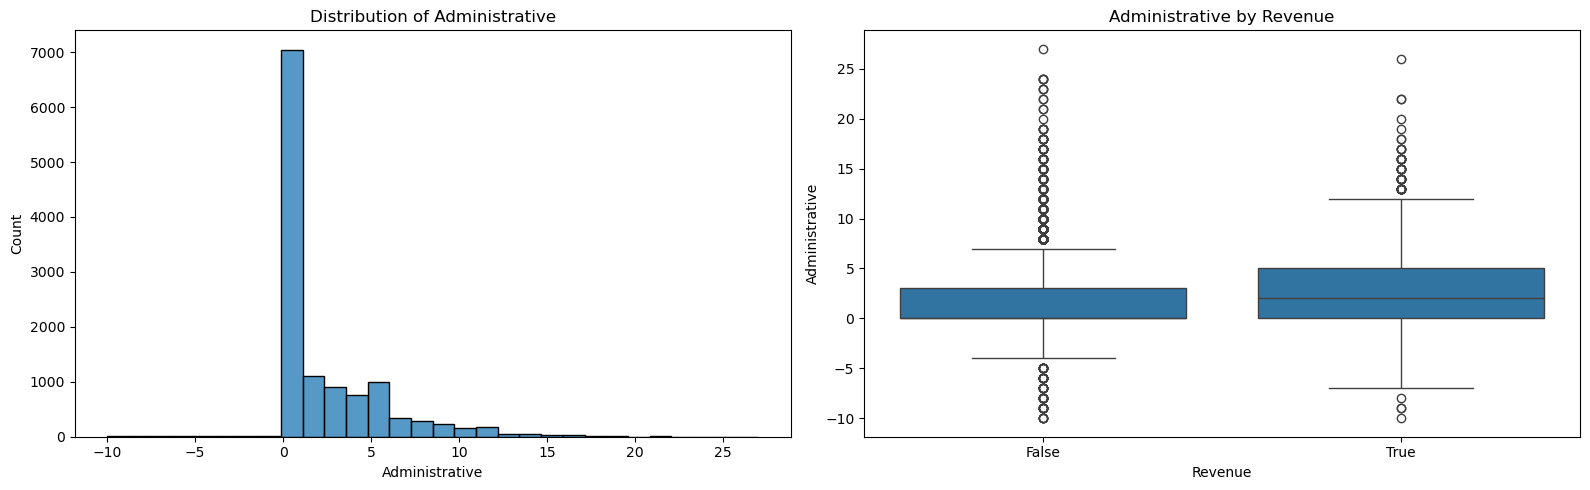


Feature: Administrative_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max        Mean  Median
 0.0 989493.0 1269.776004     8.0


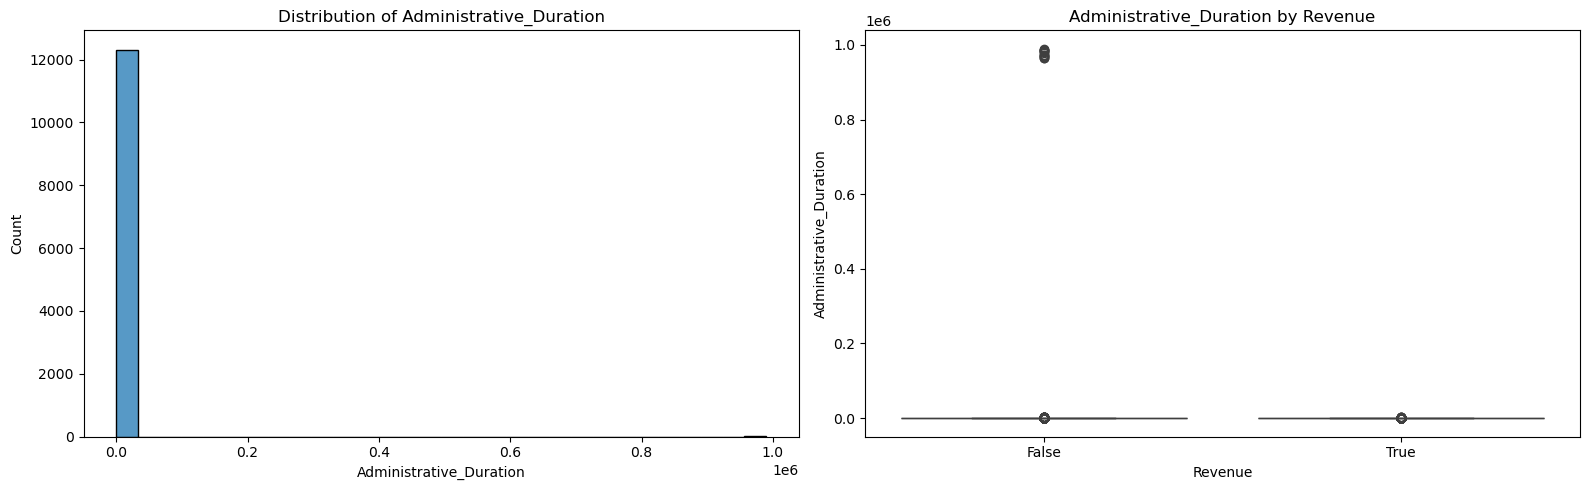


Feature: Informational
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean  Median
   0   24 0.503569     0.0


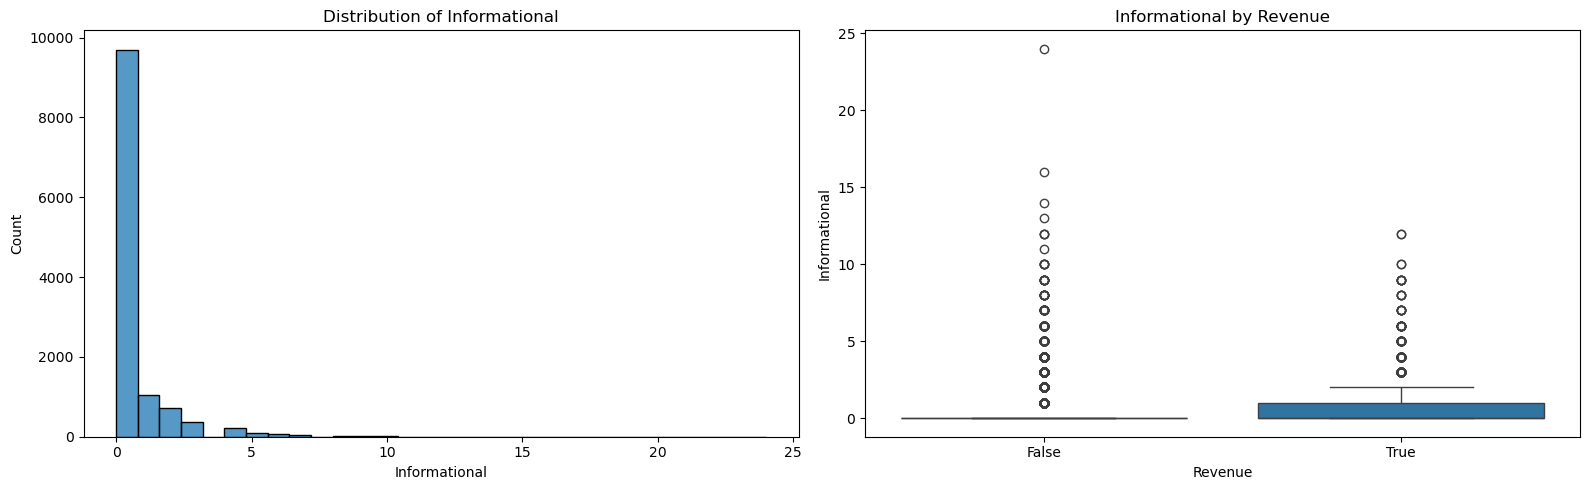


Feature: Informational_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max      Mean  Median
 0.0 2549.375 34.472398     0.0


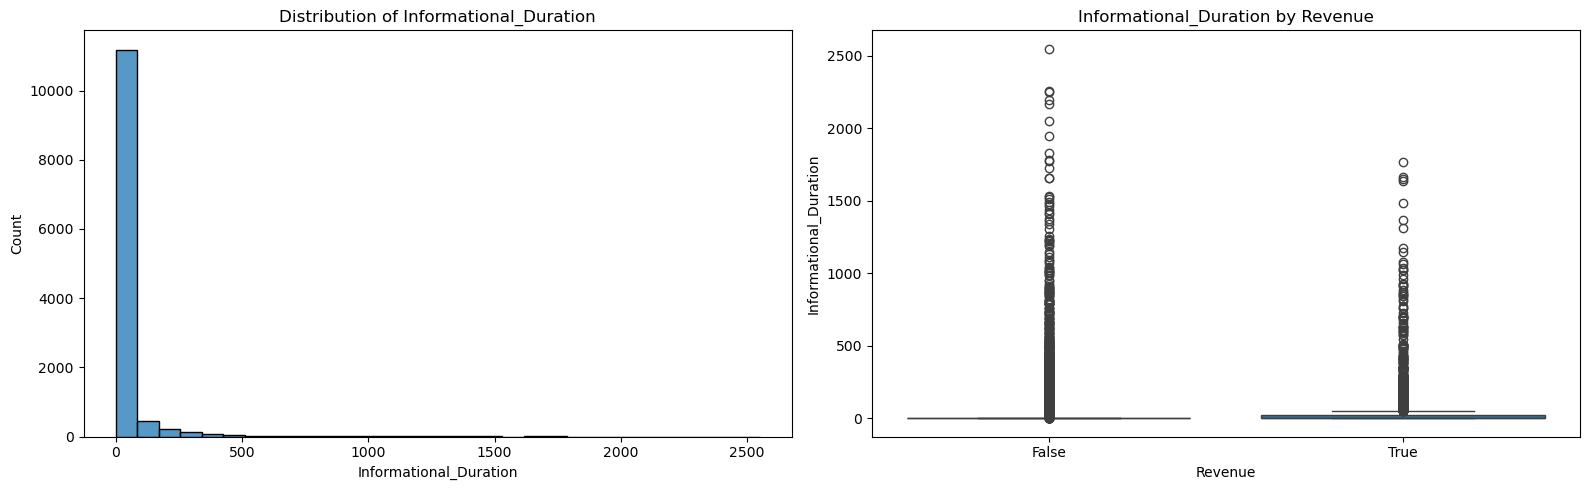


Feature: ProductRelated
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max      Mean  Median
   0  705 31.731468    18.0


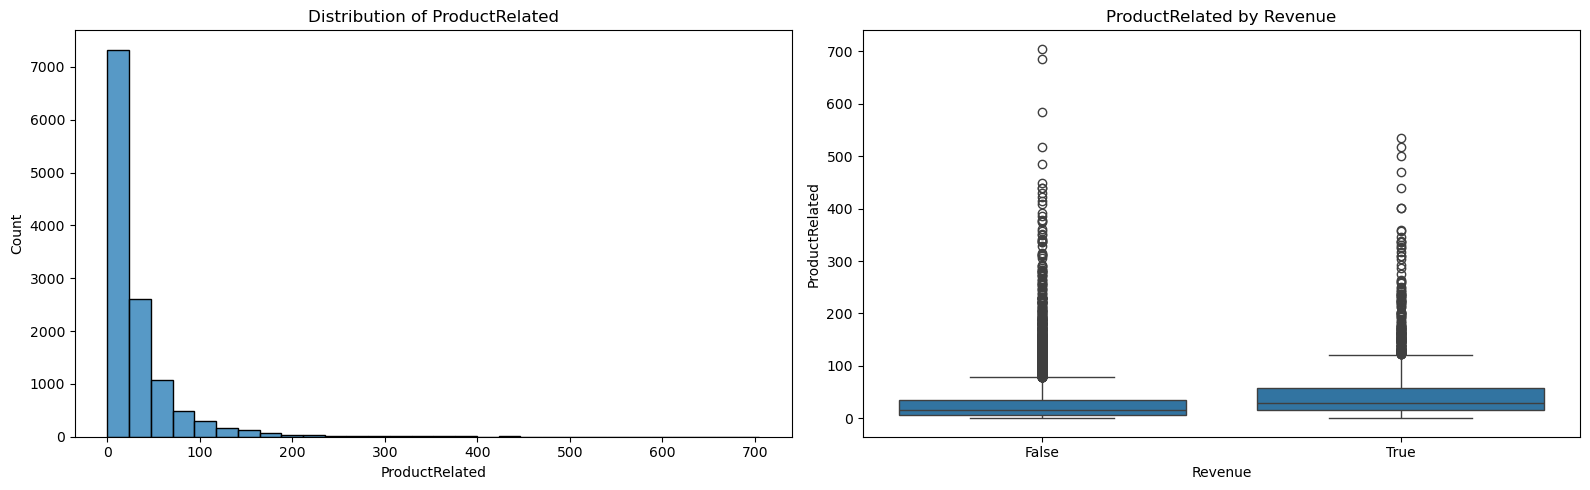


Feature: ProductRelated_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min         Max       Mean     Median
 0.0 63973.52223 1194.74622 598.936905


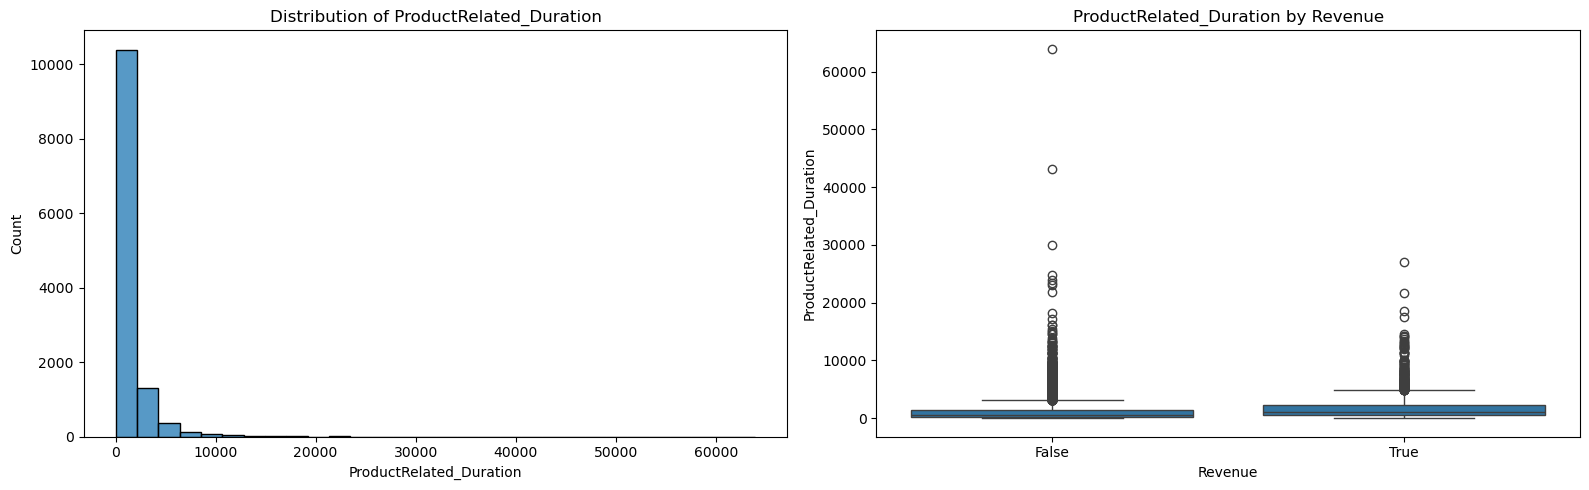


Feature: BounceRates
Description: Bounce rate of current page
Missing Values: 0 (0.00%)

Basic Statistics:
     Min      Max     Mean   Median
-0.49868 2.098952 0.044239 0.002896


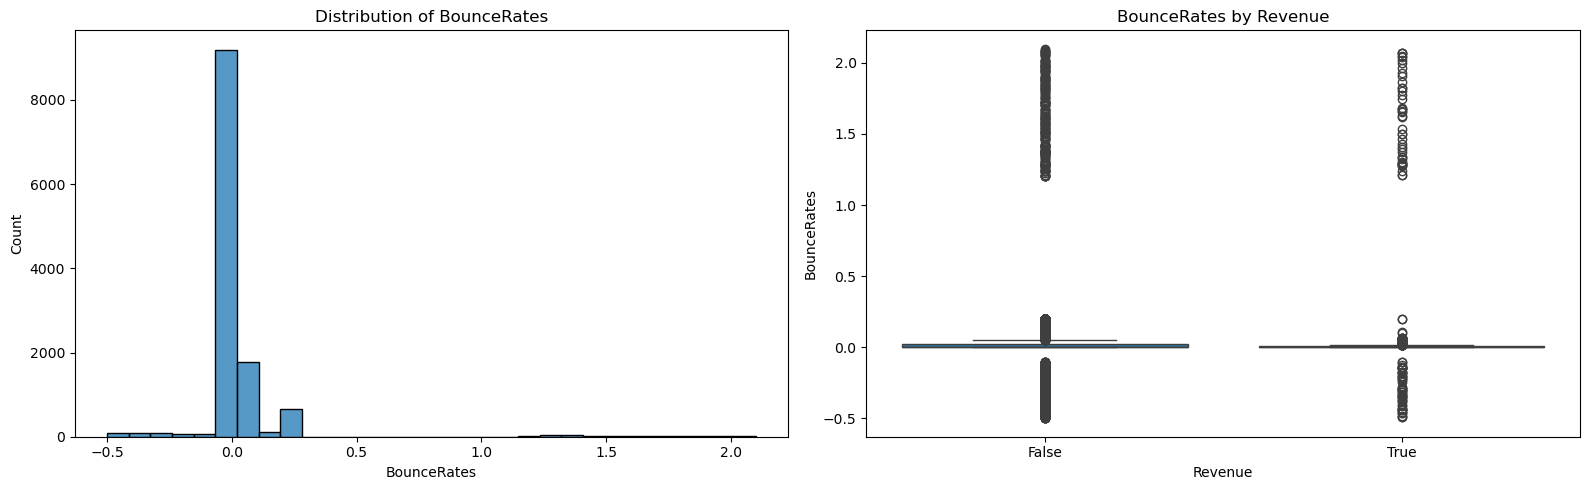


Feature: ExitRates
Description: Exit rate value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean   Median
 0.0  0.2 0.043073 0.025156


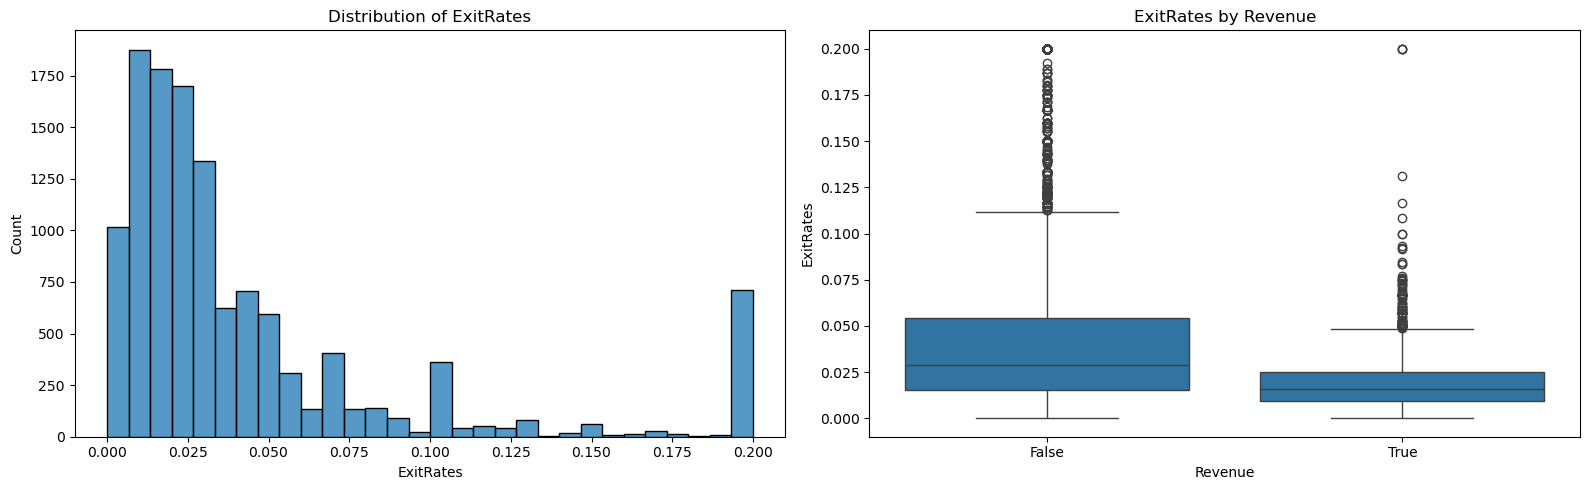


Feature: PageValues
Description: Page value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min        Max     Mean  Median
 0.0 361.763742 5.889258     0.0


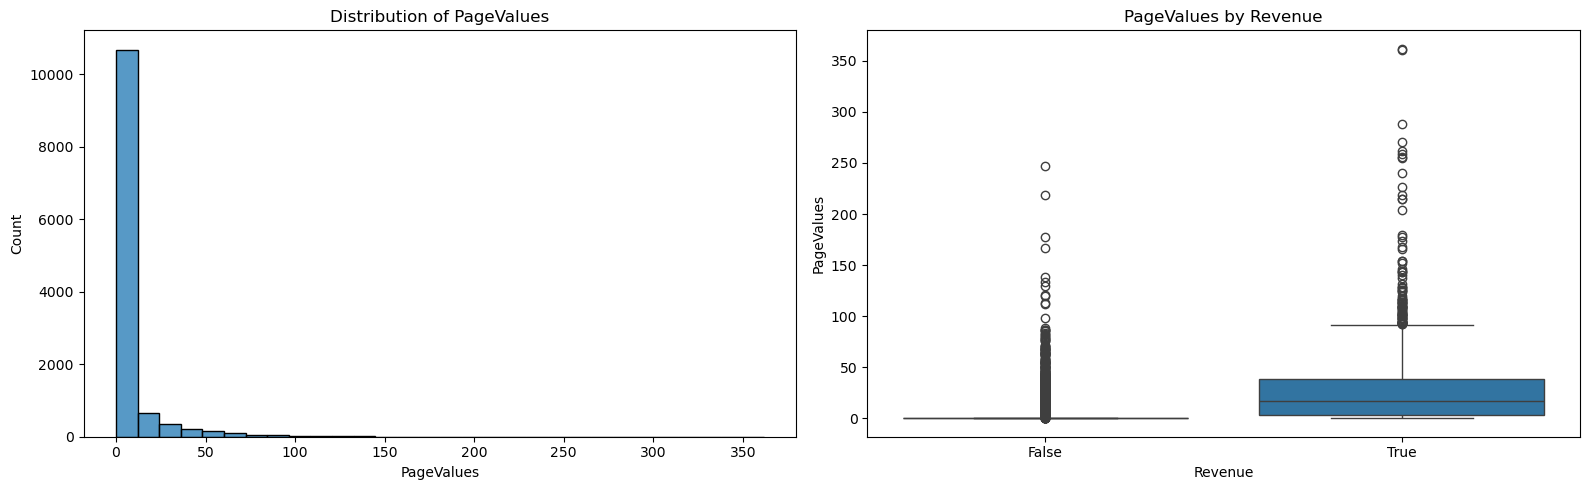


Feature: SpecialDay
Description: Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.
Missing Values: 123 (1.00%)

Basic Statistics:
 Min  Max    Mean  Median
 0.0  1.0 0.06126     0.0


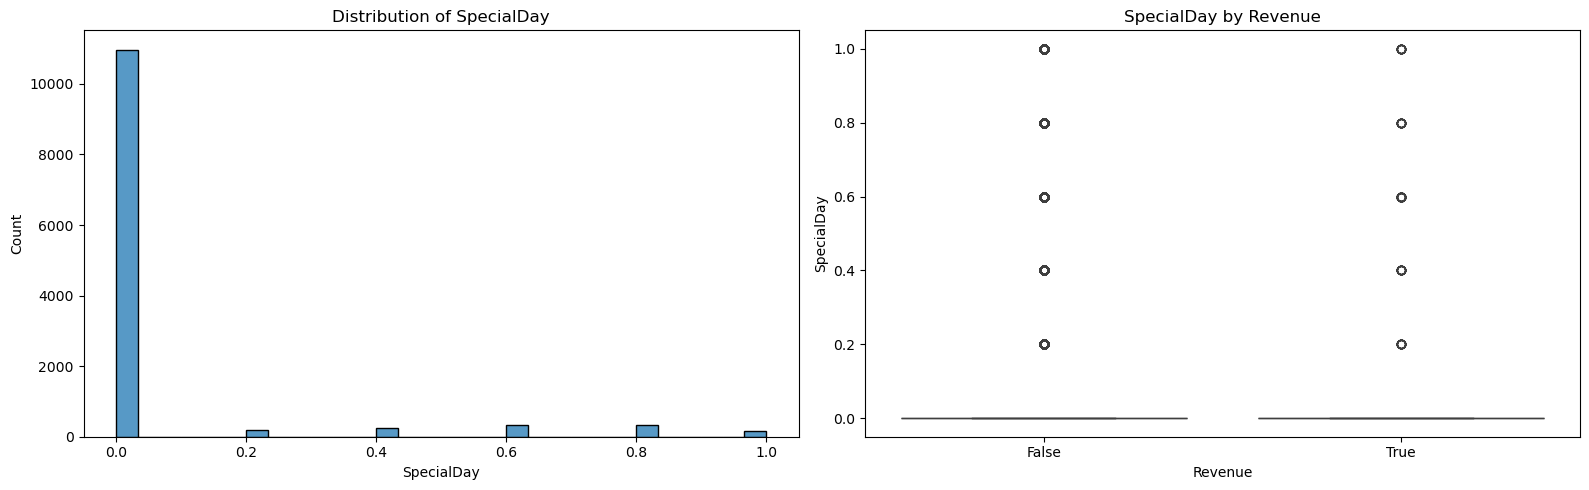


Feature: Month
Description: Month of session
Missing Values: 0 (0.00%)

Top 5 Categories:
Month
May    3196
Nov    2998
Mar    1907
Dec    1727
Oct     549


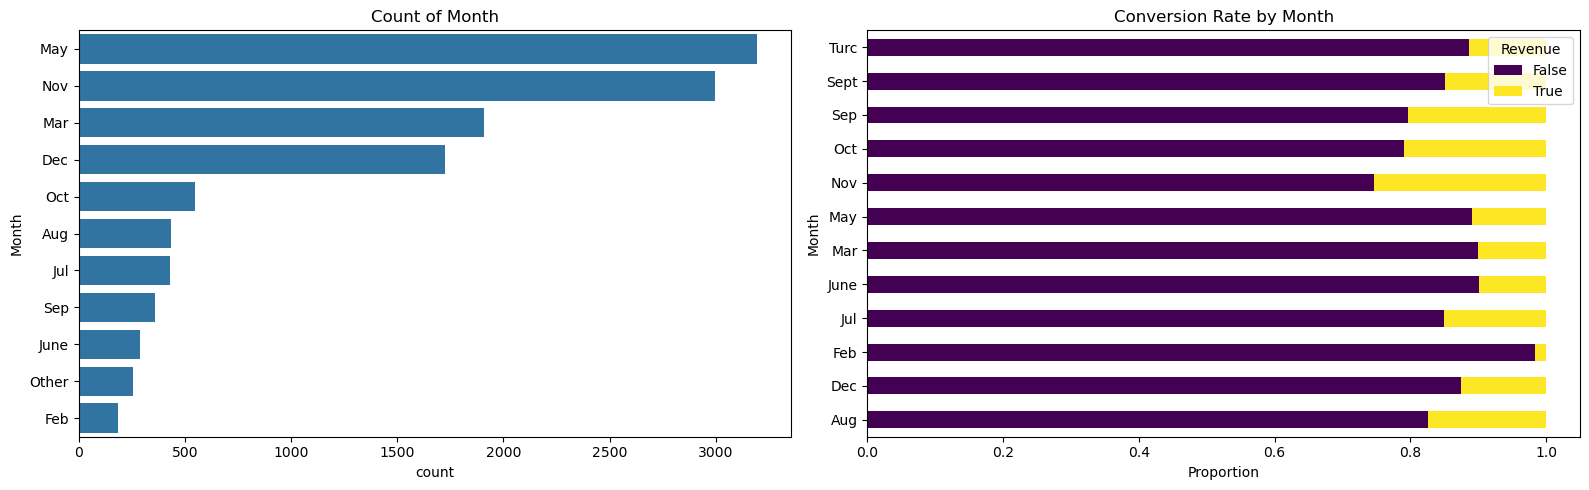


Feature: Weekend
Description: Boolean if the session day was in the weekend
Missing Values: 0 (0.00%)

Top 5 Categories:
Weekend
False        9273
True         2868
Name:Zara     189


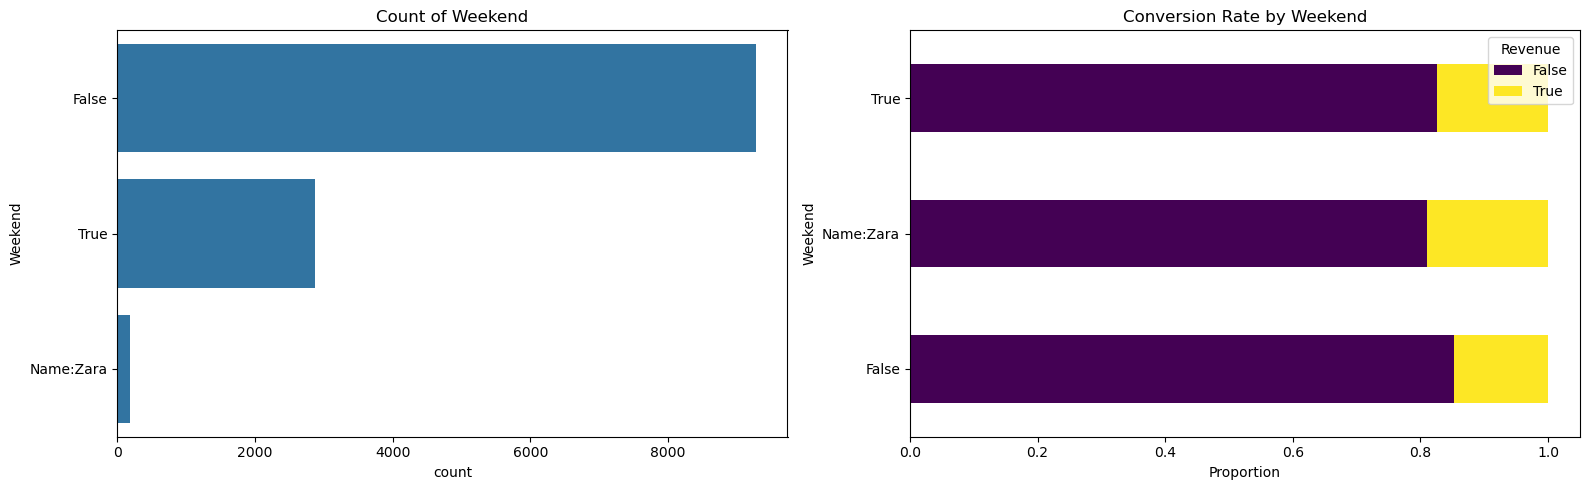


Feature: OperatingSystems
Description: Different OS' represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79


C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_18084\1480229353.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'


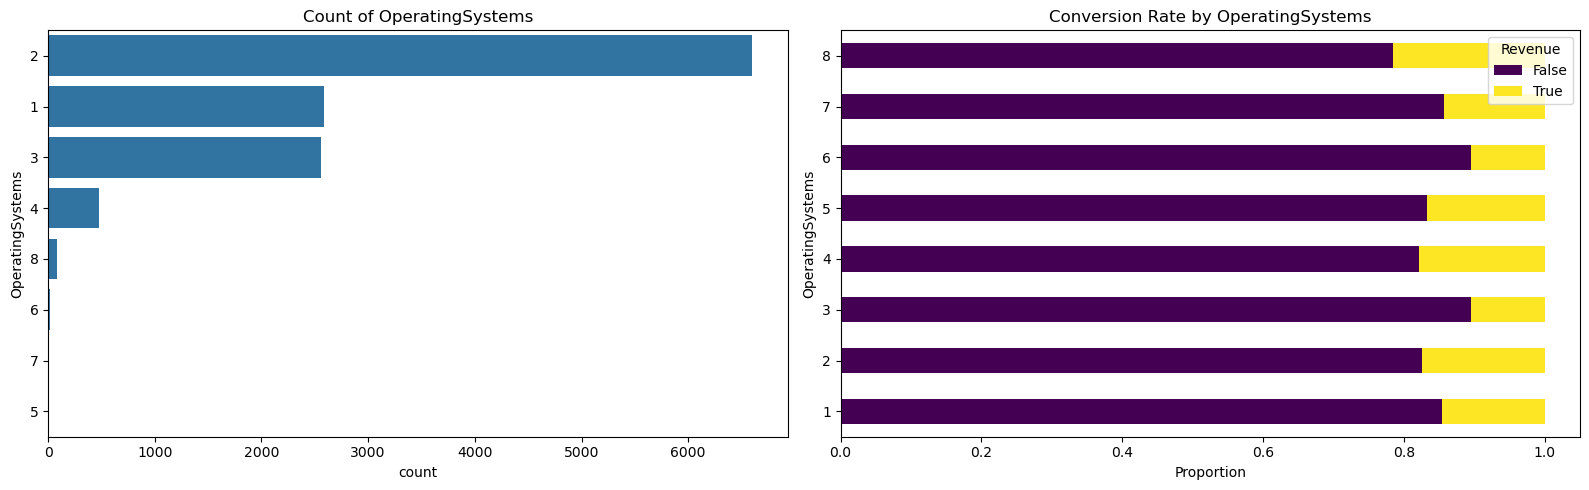


Feature: Browser
Description: Different browsers represented by different integers
Missing Values: 184 (1.49%)

Top 5 Categories:
Browser
2.0    7835
1.0    2424
4.0     725
5.0     465
6.0     171


C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_18084\1480229353.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'


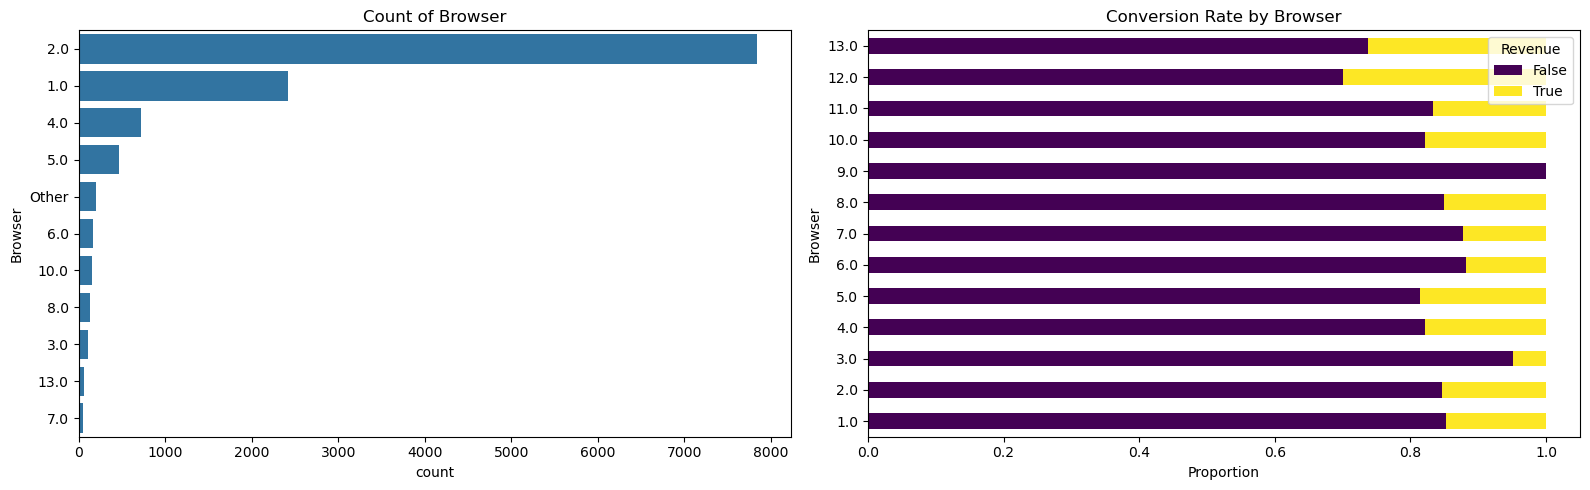


Feature: Region
Description: Different regions represented by different integers
Missing Values: 246 (2.00%)

Top 5 Categories:
Region
1.0    4695
3.0    2345
4.0    1157
2.0    1113
6.0     787


C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_18084\1480229353.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'


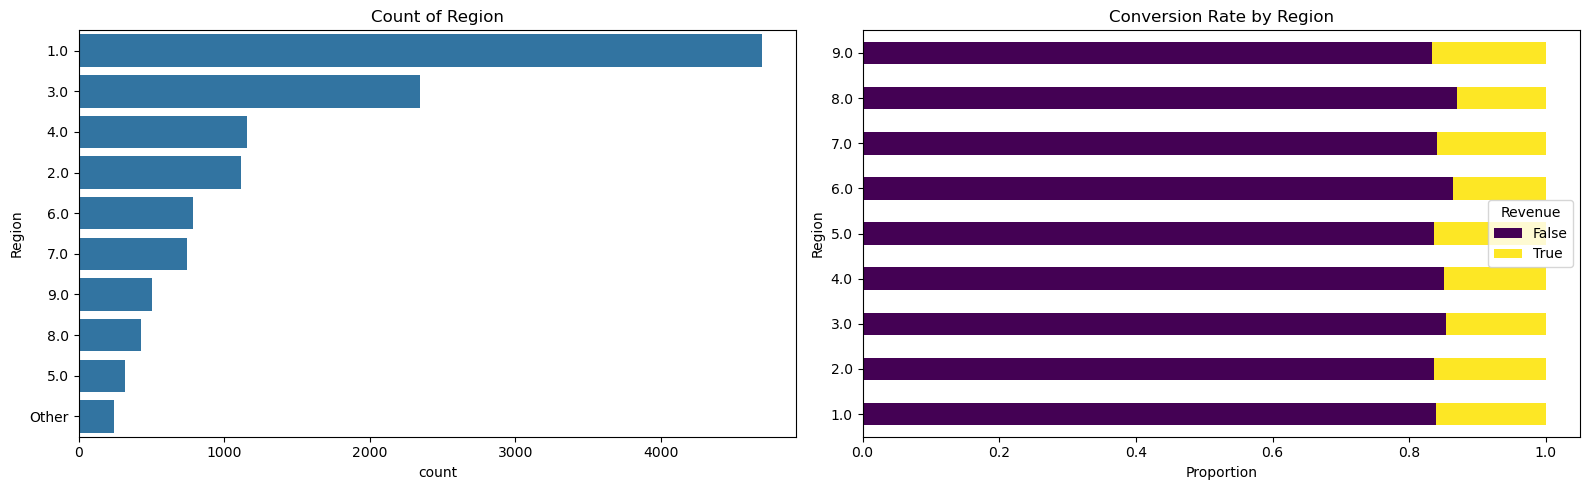


Feature: TrafficType
Description: Different traffic types represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738


C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_18084\1480229353.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'


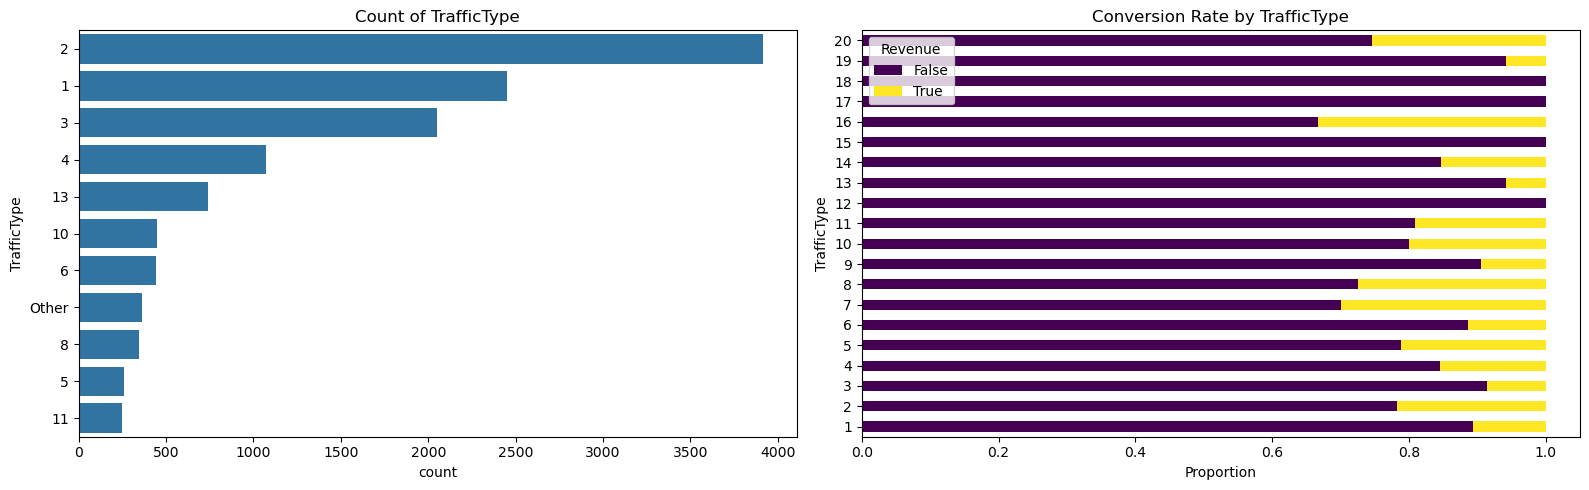


Feature: VisitorType
Description: Different visitor types represented by different categorical values
Missing Values: 0 (0.00%)

Top 5 Categories:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85


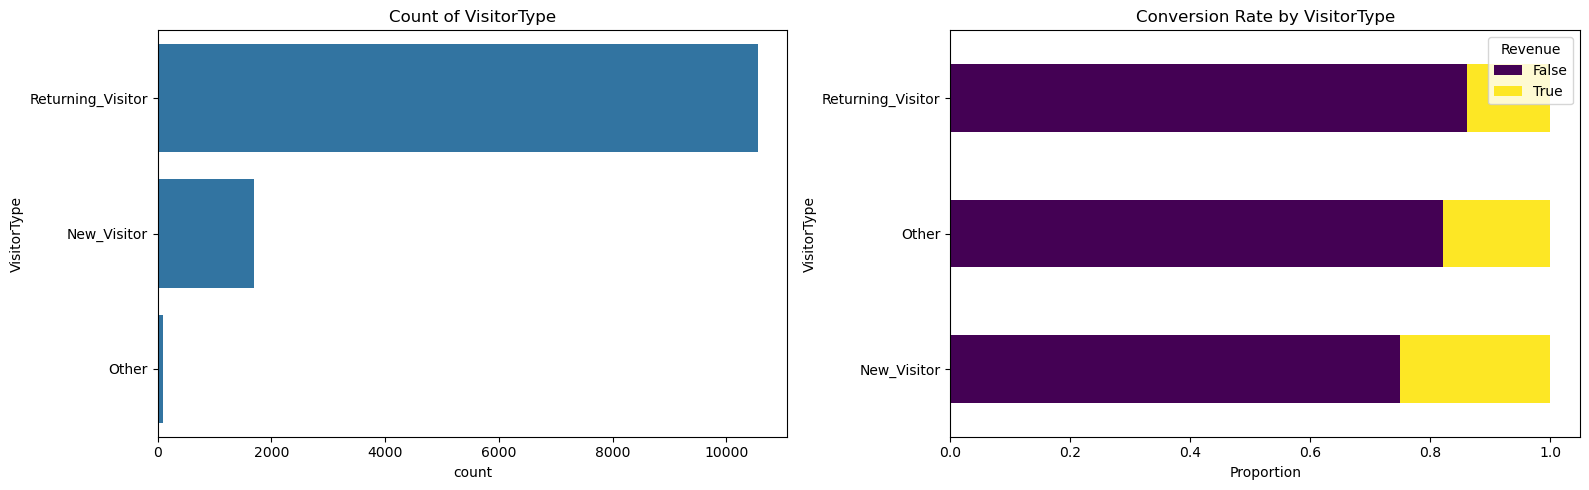

In [34]:
plot_feature_eda(session_data_df, column_descriptions)

In [35]:
def plot_feature_eda(df, column_descriptions, figsize=(16, 5), revenue_col='Revenue', n_cols=2):
    """
    Generates lightweight exploratory data analysis plots for each feature in the dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing all features
    column_descriptions : dict
        Dictionary with feature descriptions and types
    figsize : tuple, optional (default=(16, 5))
        Width, height of each row of plots
    revenue_col : str, optional (default='Revenue')
        Name of the target variable column
    n_cols : int, optional (default=2)
        Number of columns in the subplot grid
        
    Returns:
    --------
    None. Displays plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    
    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue  # Skip the target variable
            
        if isinstance(info, dict):  # If using the structured dictionary format
            if info["type"] == "numeric":
                numeric_features.append(col)
            else:
                categorical_features.append(col)
        else:  # If using the string-based format
            if "Type: numeric" in info:
                numeric_features.append(col)
            else:
                categorical_features.append(col)
    
    # Function to create plots for numeric features
    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Simple histogram with mean and median lines
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[0])
        
        # Add mean line (red dotted)
        mean_val = df[feature].mean()
        axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                       label=f'Mean: {mean_val:.2f}')
        
        # Add median line (green dotted)
        median_val = df[feature].median()
        axes[0].axvline(median_val, color='green', linestyle=':', linewidth=1.5,
                       label=f'Median: {median_val:.2f}')
        
        axes[0].legend(loc='best')
        axes[0].set_title(f'Distribution of {feature}')
        axes[0].set_xlabel(feature)
        
        # Right plot: Box plot by Revenue with mean and median annotations
        sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
        
        # Add mean and median for each group
        for i, rev_val in enumerate([False, True]):
            group_data = df[df[revenue_col] == rev_val][feature].dropna()
            
            if len(group_data) > 0:
                group_mean = group_data.mean()
                group_median = group_data.median()
                
                # Annotate mean
                axes[1].text(i, group_mean, f"μ: {group_mean:.2f}", 
                           ha='center', va='bottom', color='red', fontweight='bold')
                
                # Annotate median
                axes[1].text(i, group_median, f"m: {group_median:.2f}", 
                           ha='center', va='top', color='green', fontweight='bold')
                
        axes[1].set_title(f'{feature} by {revenue_col}')
            
        plt.tight_layout()
        plt.show()
    
    # Function to create plots for categorical features
    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Simple count plot
        top_categories = df[feature].value_counts().nlargest(10).index
        temp_df = df.copy()
        temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'
        sns.countplot(y=feature, data=temp_df, order=temp_df[feature].value_counts().index, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)
        
        # Right plot: Stacked bar chart by Revenue
        crosstab = pd.crosstab(df[feature], df[revenue_col], normalize='index')
        crosstab.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
        
        # Add mean and median lines if the feature has numeric encoding
        try:
            if feature in ['OperatingSystems', 'Browser', 'Region', 'TrafficType']:
                # Convert categorical values to numeric for calculating mean/median
                numeric_values = pd.to_numeric(df[feature].dropna())
                
                # Calculate mean and median
                mean_val = numeric_values.mean()
                median_val = numeric_values.median()
                
                # Find where these values would be in the y-axis
                y_positions = {cat: i for i, cat in enumerate(crosstab.index)}
                
                # Check if mean and median values exist in the index
                if mean_val in y_positions:
                    axes[1].axhline(y=y_positions[mean_val], color='red', linestyle='--', 
                                   linewidth=1.5, label=f'Mean: {mean_val:.2f}')
                
                if median_val in y_positions:
                    axes[1].axhline(y=y_positions[median_val], color='green', linestyle=':', 
                                   linewidth=1.5, label=f'Median: {median_val:.2f}')
                
                # Add legend if any lines were added
                if mean_val in y_positions or median_val in y_positions:
                    axes[1].legend(loc='lower right')
        except:
            # If converting to numeric fails, silently continue without mean/median lines
            pass
            
        axes[1].set_title(f'Conversion Rate by {feature}')
        axes[1].set_xlabel('Proportion')
        axes[1].set_ylabel(feature)
        
        plt.tight_layout()
        plt.show()
    
    # Function to show basic stats before plotting
    def plot_feature(feature):
        print(f"\n{'='*40}")
        
        # Extract and print feature description
        if isinstance(column_descriptions[feature], dict):
            desc = column_descriptions[feature]["description"]
        else:
            desc = column_descriptions[feature].split("Type:")[0].strip()
            
        print(f"Feature: {feature}")
        print(f"Description: {desc}")
        print(f"Missing Values: {df[feature].isna().sum()} ({df[feature].isna().mean():.2%})")
        
        if feature in numeric_features:
            # Print only basic summary statistics
            stats_df = pd.DataFrame({
                'Min': df[feature].min(),
                'Max': df[feature].max(),
                'Mean': df[feature].mean(),
                'Median': df[feature].median()
            }, index=[0])
            print("\nBasic Statistics:")
            print(stats_df.to_string(index=False))
            
            plot_numeric_feature(feature)
        else:
            # Print only top categories
            value_counts = df[feature].value_counts()
            print("\nTop 5 Categories:")
            print(value_counts.head(5).to_string())
            
            plot_categorical_feature(feature)
    
    # Plot each feature
    for feature in numeric_features + categorical_features:
        plot_feature(feature)


Feature: Administrative
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max   Mean  Median
 -10   27 2.2382     1.0


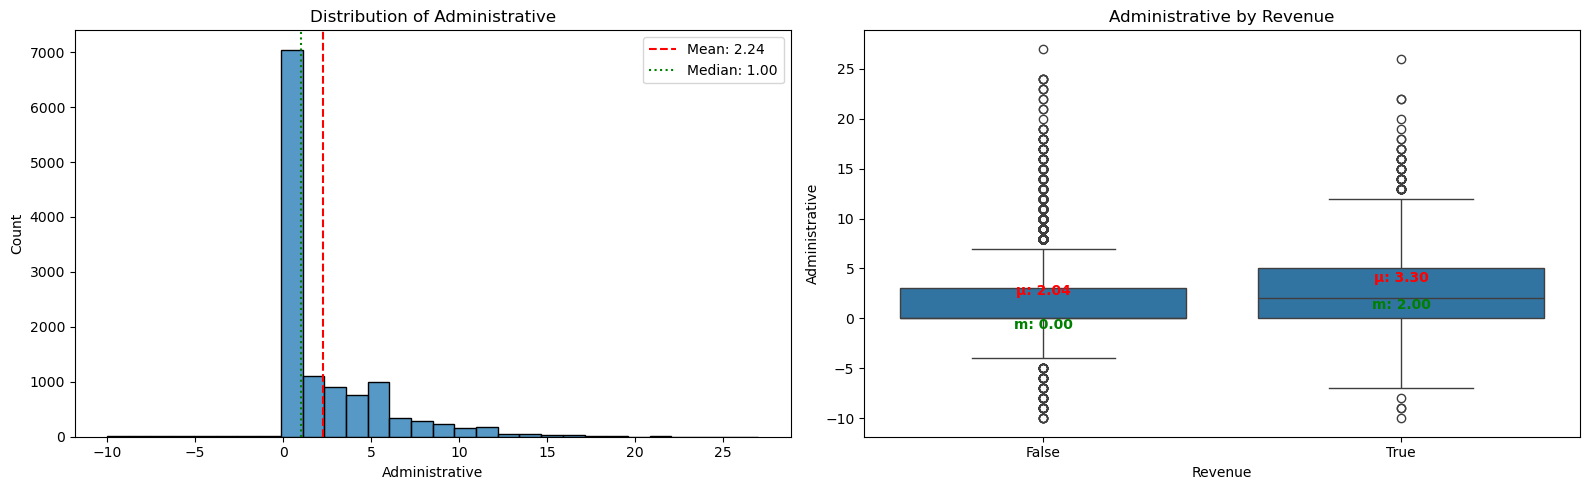


Feature: Administrative_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max        Mean  Median
 0.0 989493.0 1269.776004     8.0


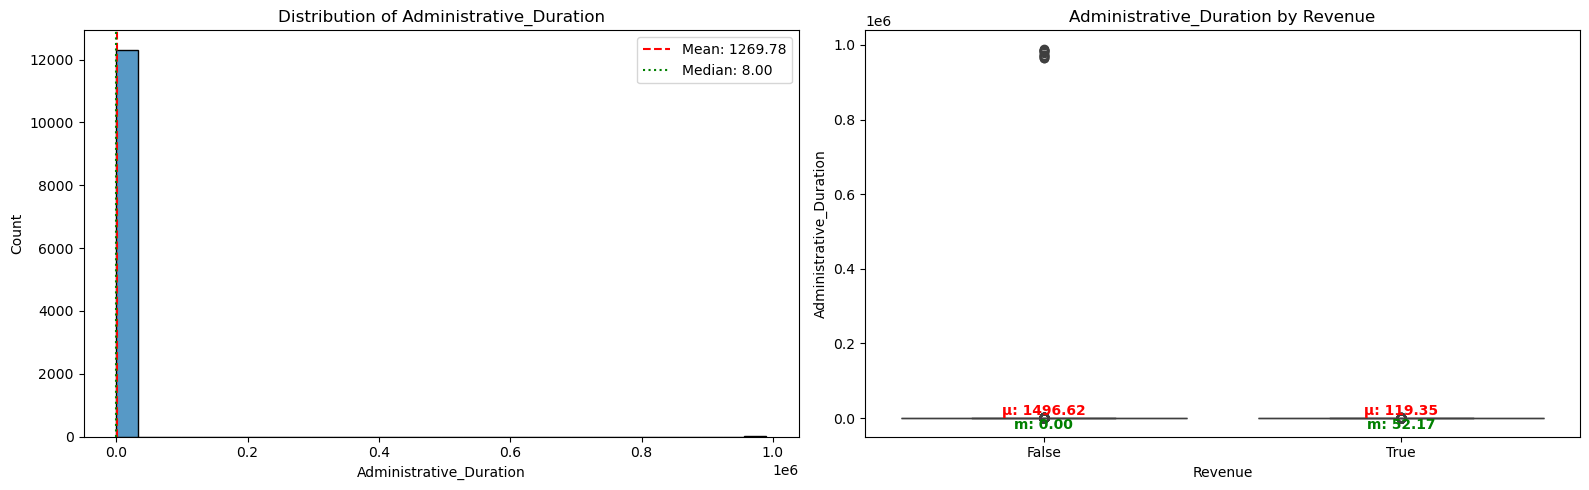


Feature: Informational
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean  Median
   0   24 0.503569     0.0


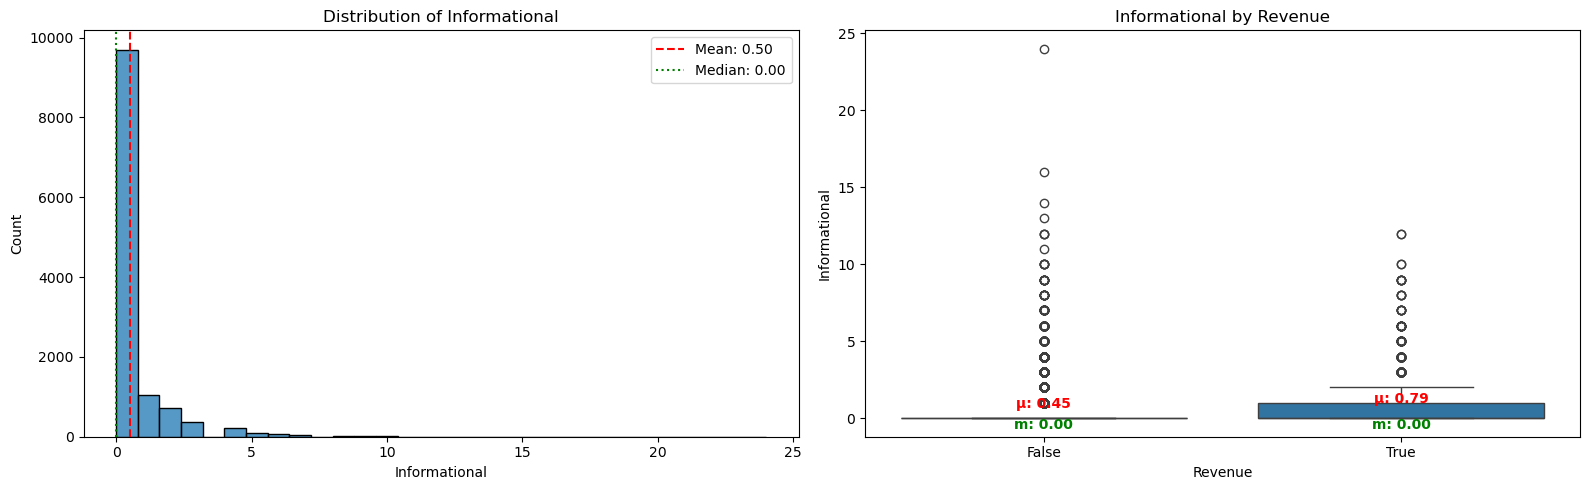


Feature: Informational_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max      Mean  Median
 0.0 2549.375 34.472398     0.0


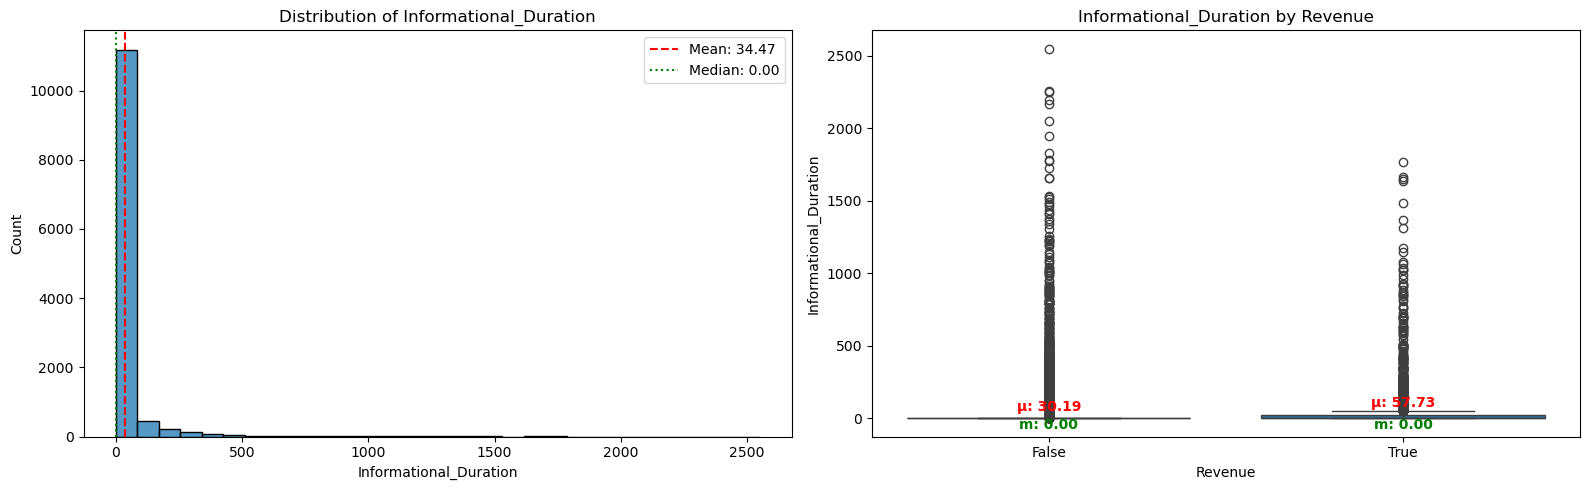


Feature: ProductRelated
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max      Mean  Median
   0  705 31.731468    18.0


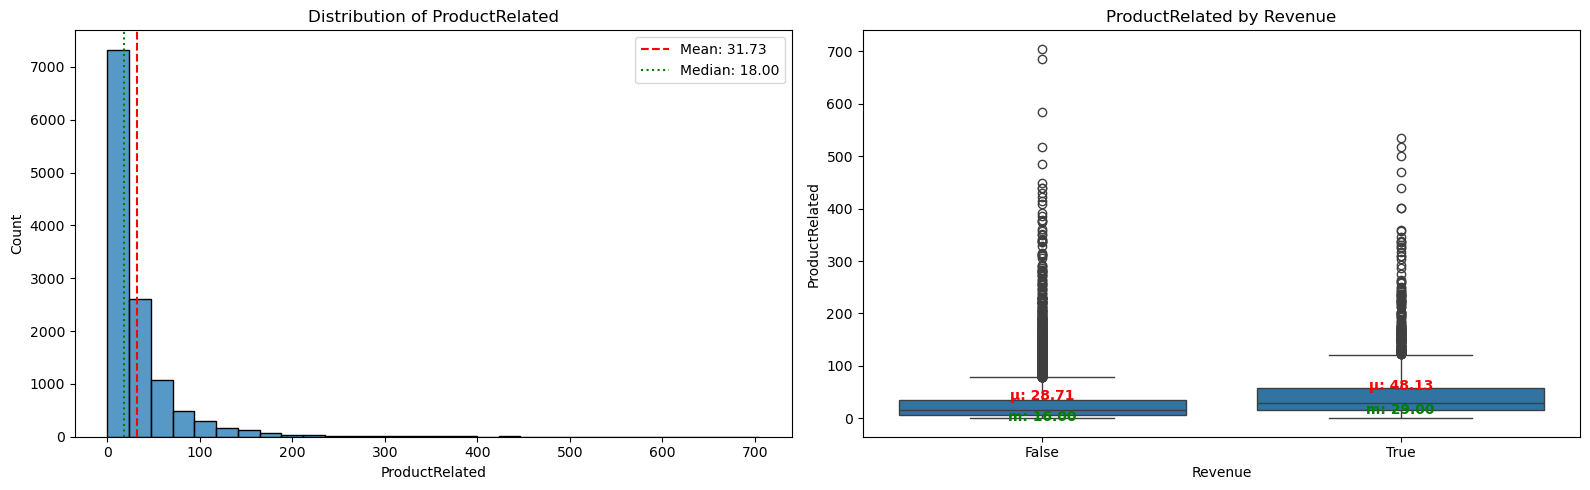


Feature: ProductRelated_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min         Max       Mean     Median
 0.0 63973.52223 1194.74622 598.936905


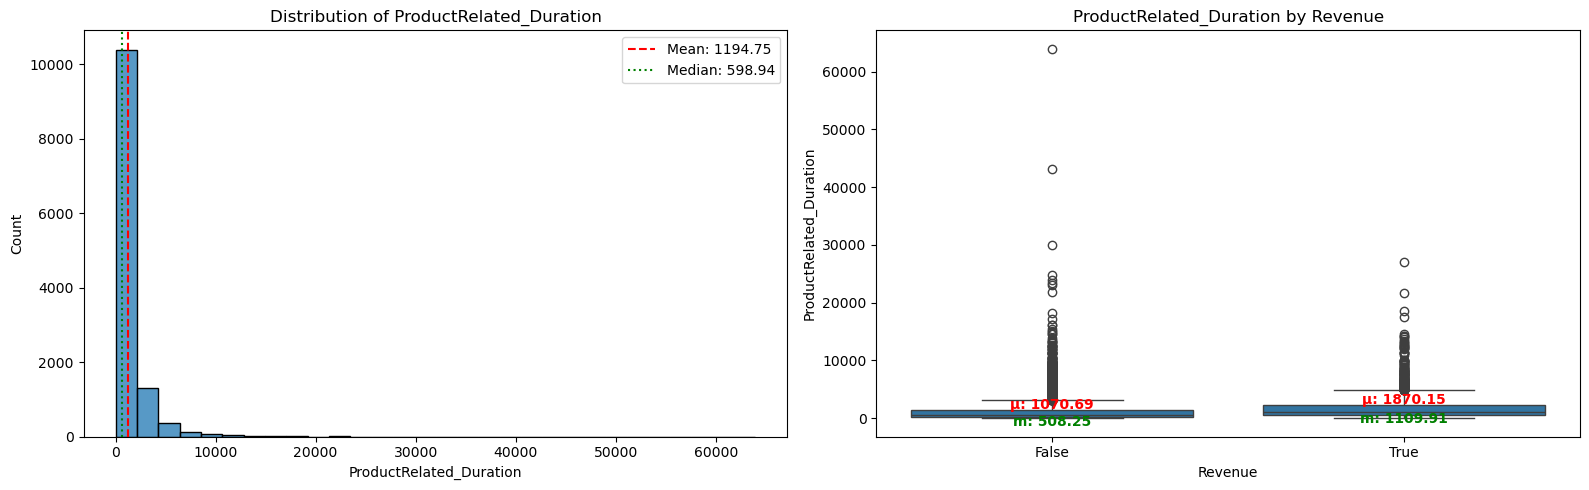


Feature: BounceRates
Description: Bounce rate of current page
Missing Values: 0 (0.00%)

Basic Statistics:
     Min      Max     Mean   Median
-0.49868 2.098952 0.044239 0.002896


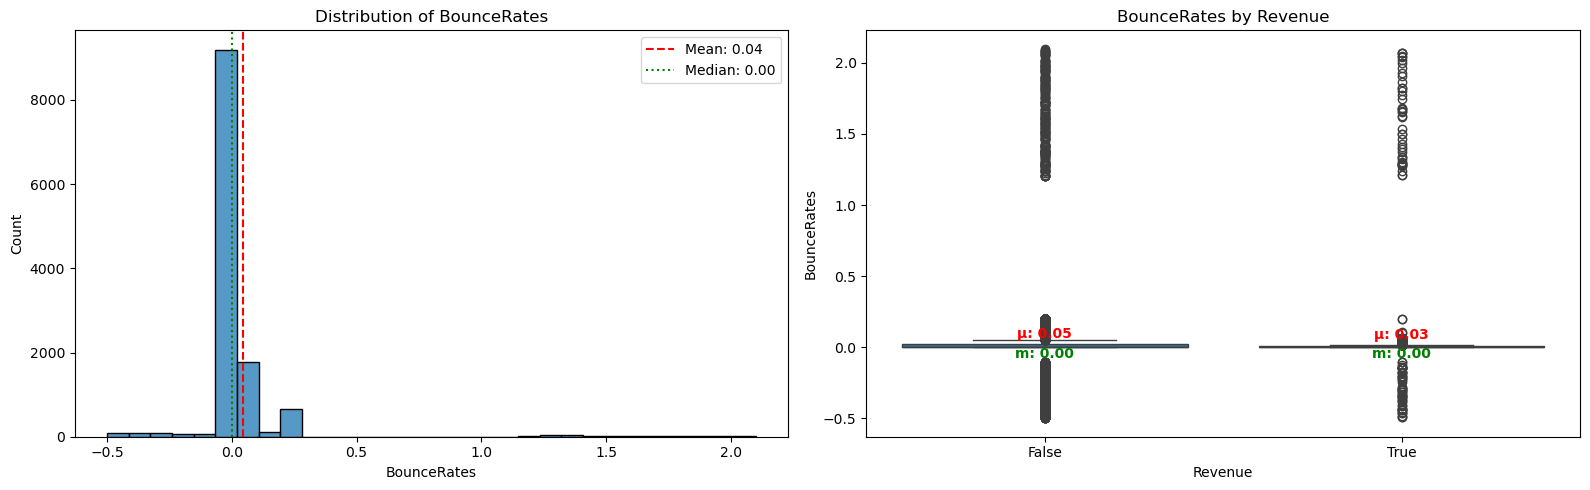


Feature: ExitRates
Description: Exit rate value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean   Median
 0.0  0.2 0.043073 0.025156


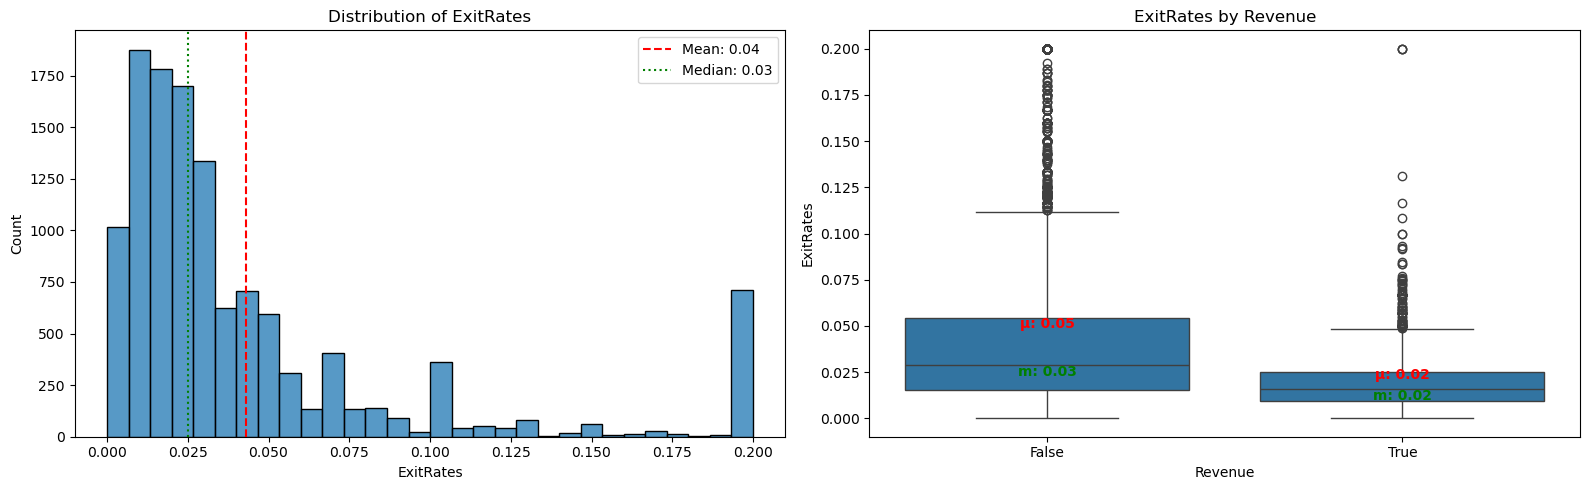


Feature: PageValues
Description: Page value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min        Max     Mean  Median
 0.0 361.763742 5.889258     0.0


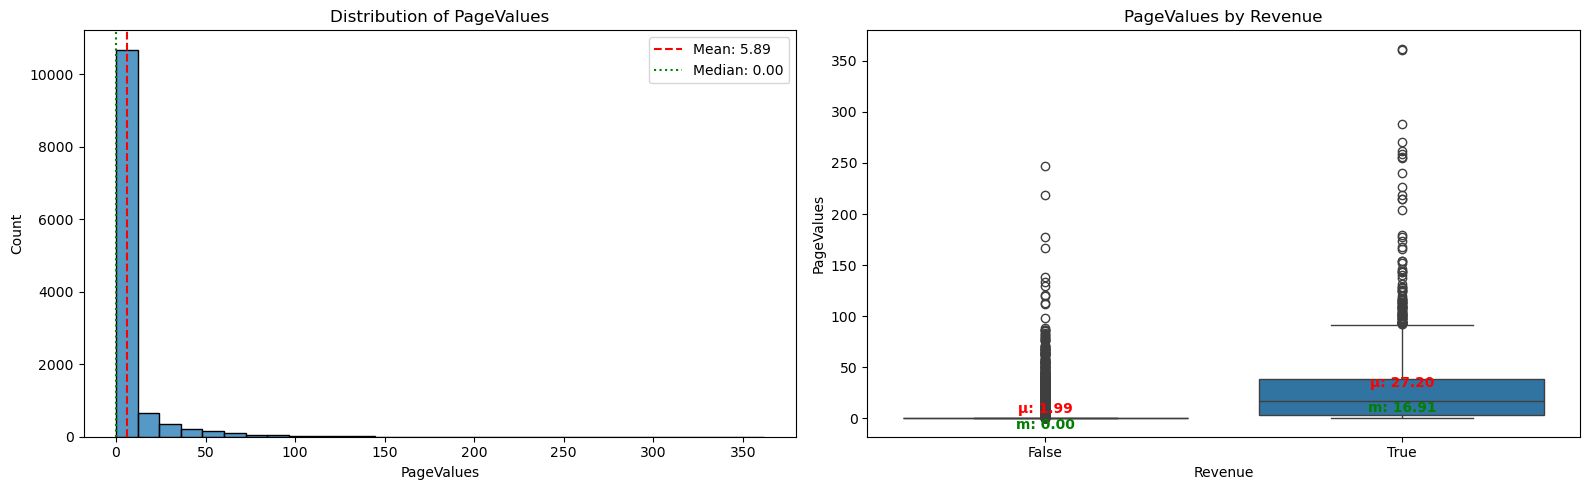


Feature: SpecialDay
Description: Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.
Missing Values: 123 (1.00%)

Basic Statistics:
 Min  Max    Mean  Median
 0.0  1.0 0.06126     0.0


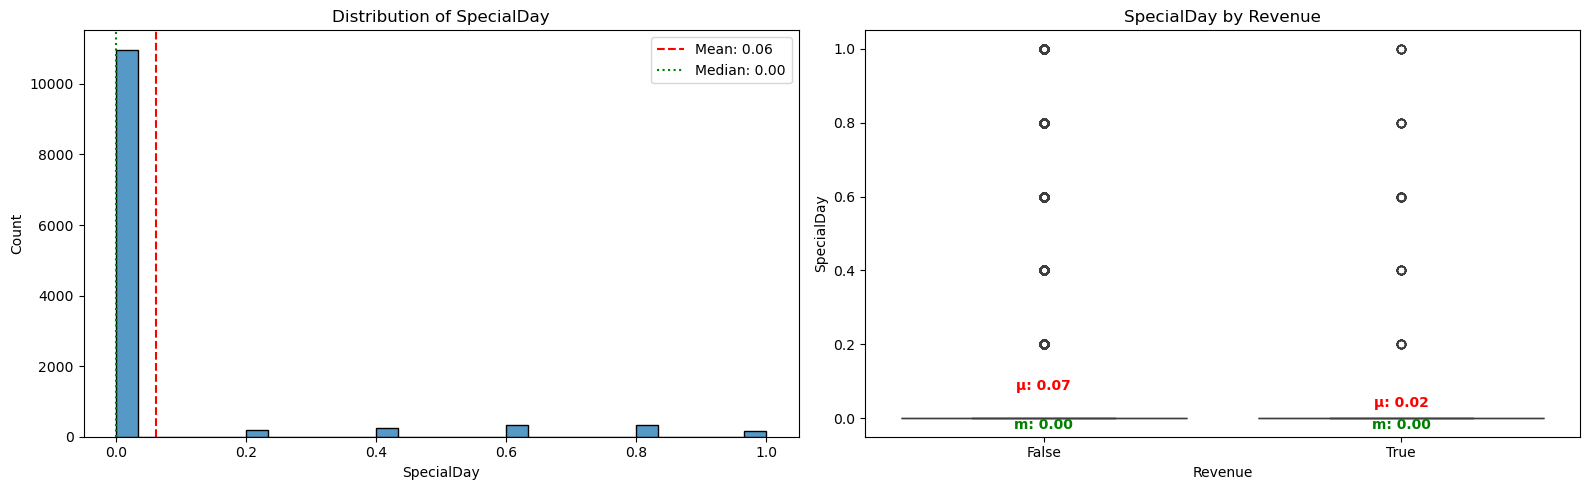


Feature: Month
Description: Month of session
Missing Values: 0 (0.00%)

Top 5 Categories:
Month
May    3196
Nov    2998
Mar    1907
Dec    1727
Oct     549


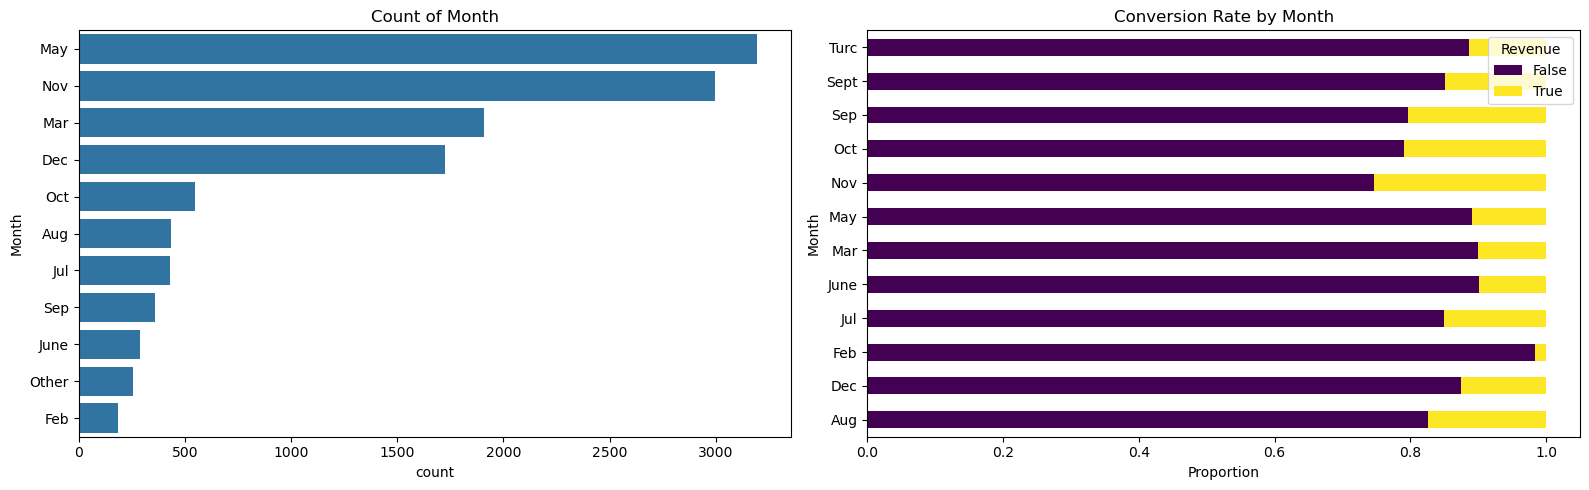


Feature: Weekend
Description: Boolean if the session day was in the weekend
Missing Values: 0 (0.00%)

Top 5 Categories:
Weekend
False        9273
True         2868
Name:Zara     189


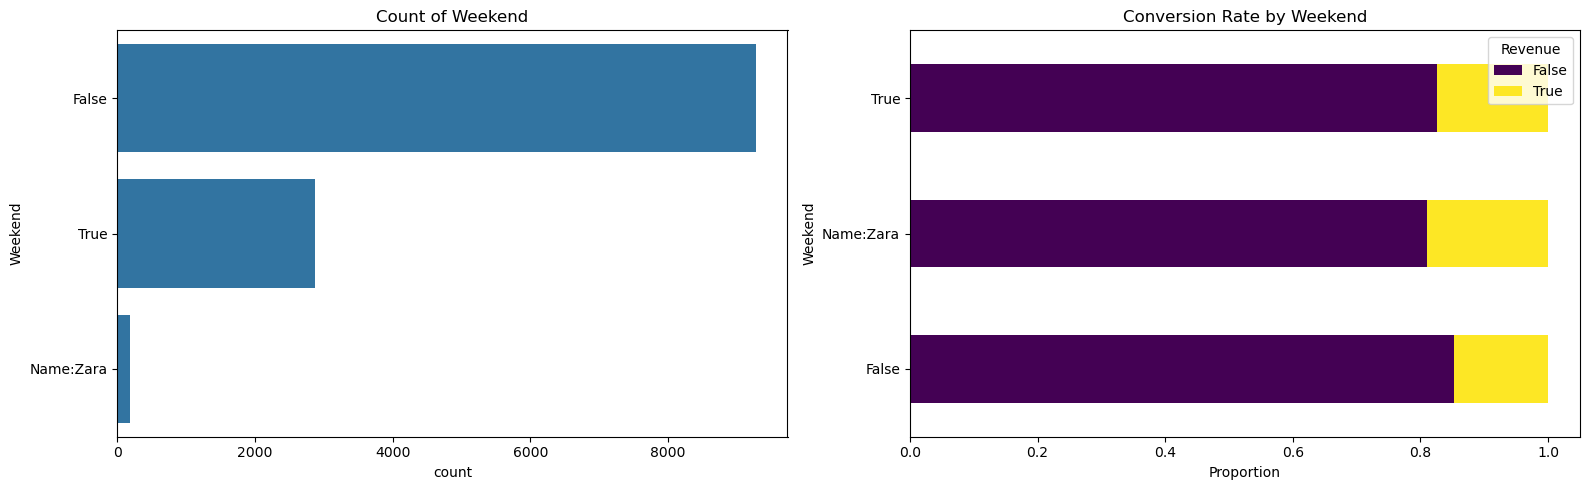


Feature: OperatingSystems
Description: Different OS' represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79


C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_18084\2423952248.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'


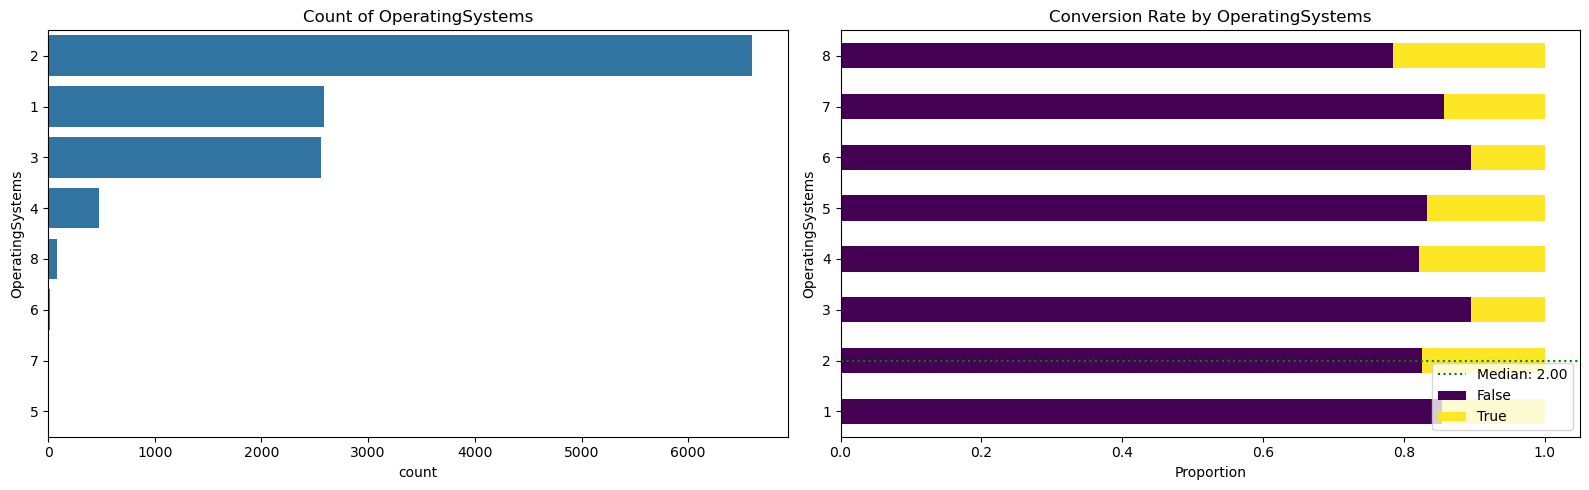


Feature: Browser
Description: Different browsers represented by different integers
Missing Values: 184 (1.49%)

Top 5 Categories:
Browser
2.0    7835
1.0    2424
4.0     725
5.0     465
6.0     171


C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_18084\2423952248.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'


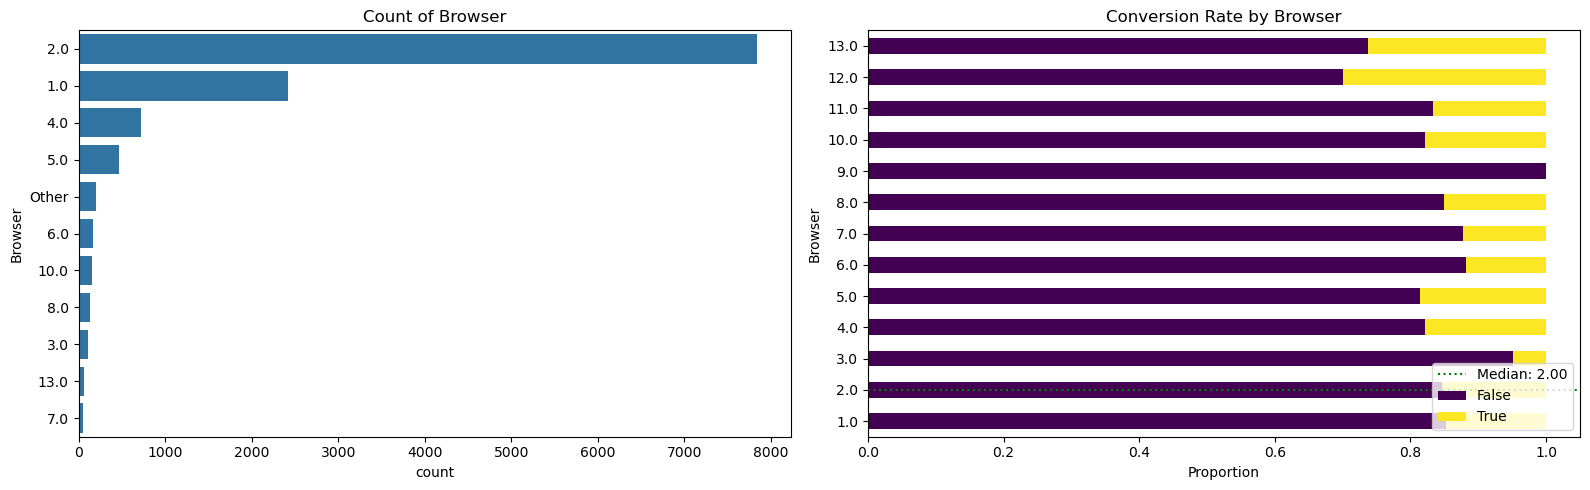


Feature: Region
Description: Different regions represented by different integers
Missing Values: 246 (2.00%)

Top 5 Categories:
Region
1.0    4695
3.0    2345
4.0    1157
2.0    1113
6.0     787


C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_18084\2423952248.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'


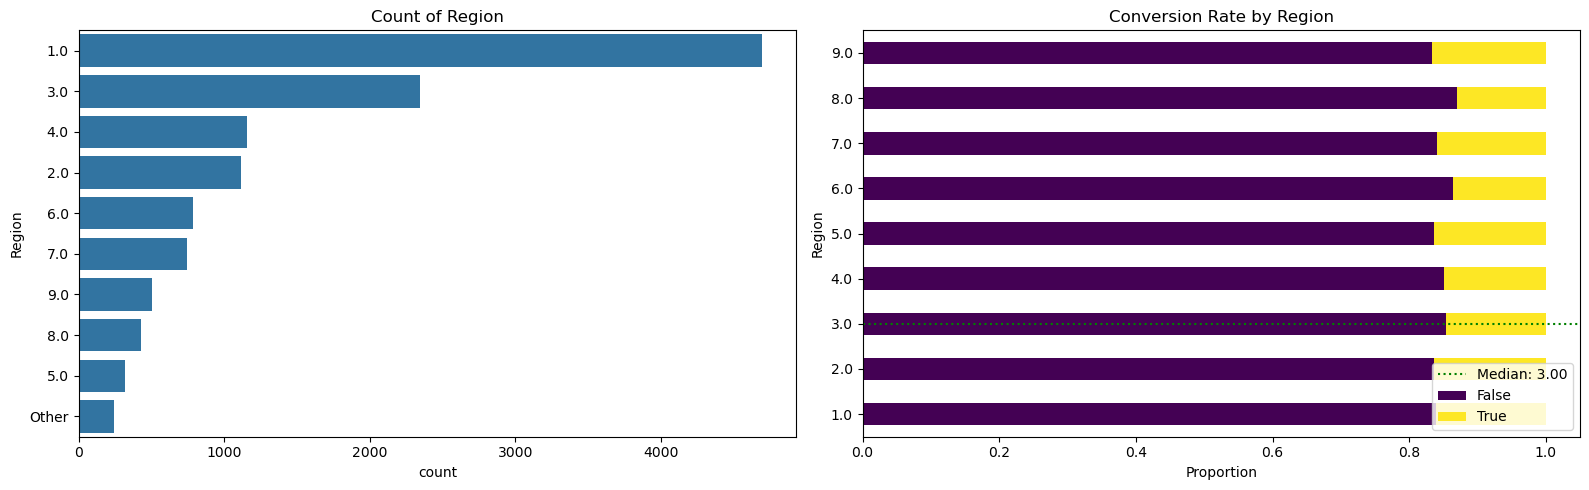


Feature: TrafficType
Description: Different traffic types represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738


C:\Users\SunnyVanderwall\AppData\Local\Temp\ipykernel_18084\2423952248.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  temp_df.loc[~temp_df[feature].isin(top_categories), feature] = 'Other'


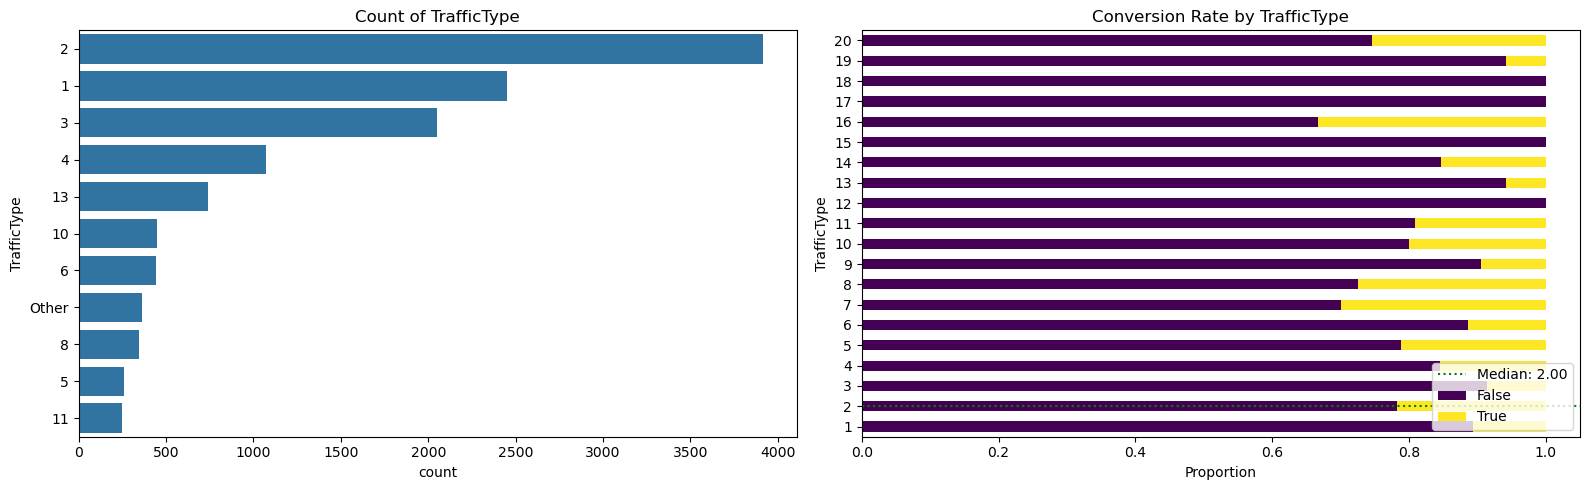


Feature: VisitorType
Description: Different visitor types represented by different categorical values
Missing Values: 0 (0.00%)

Top 5 Categories:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85


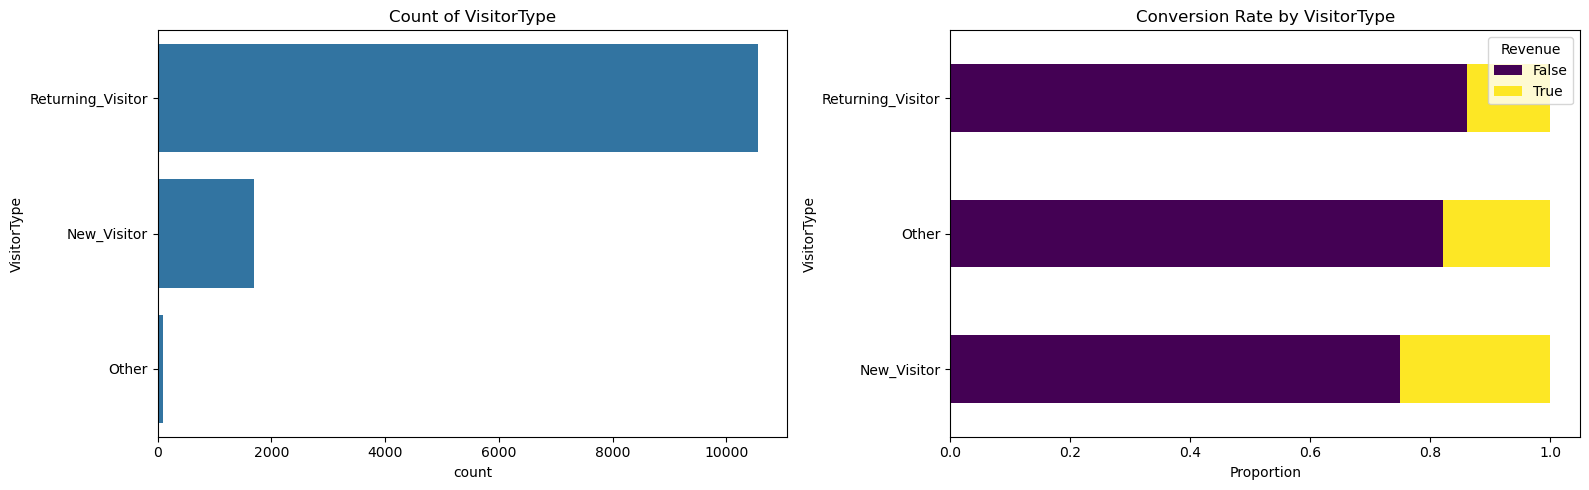

In [36]:
plot_feature_eda(session_data_df, column_descriptions)

In [37]:
def plot_feature_eda(df, column_descriptions, figsize=(16, 5), revenue_col='Revenue', n_cols=2):
    """
    Generates lightweight exploratory data analysis plots for each feature in the dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing all features
    column_descriptions : dict
        Dictionary with feature descriptions and types
    figsize : tuple, optional (default=(16, 5))
        Width, height of each row of plots
    revenue_col : str, optional (default='Revenue')
        Name of the target variable column
    n_cols : int, optional (default=2)
        Number of columns in the subplot grid
        
    Returns:
    --------
    None. Displays plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    
    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue  # Skip the target variable
            
        if isinstance(info, dict):  # If using the structured dictionary format
            if info["type"] == "numeric":
                numeric_features.append(col)
            else:
                categorical_features.append(col)
        else:  # If using the string-based format
            if "Type: numeric" in info:
                numeric_features.append(col)
            else:
                categorical_features.append(col)
    
    # Function to create plots for numeric features
    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Simple histogram with mean and median lines
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[0])
        
        # Add mean line (red dotted)
        mean_val = df[feature].mean()
        axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                       label=f'Mean: {mean_val:.2f}')
        
        # Add median line (green dotted) - using same style as mean line
        median_val = df[feature].median()
        axes[0].axvline(median_val, color='green', linestyle='--', linewidth=1.5,
                       label=f'Median: {median_val:.2f}')
        
        axes[0].legend(loc='best')
        axes[0].set_title(f'Distribution of {feature}')
        axes[0].set_xlabel(feature)
        
        # Right plot: Box plot by Revenue with mean and median annotations at the top
        sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
        
        # Add mean and median for each group at the top of the chart
        for i, rev_val in enumerate([False, True]):
            group_data = df[df[revenue_col] == rev_val][feature].dropna()
            
            if len(group_data) > 0:
                group_mean = group_data.mean()
                group_median = group_data.median()
                
                # Get y-axis limits to position annotations at the top
                ymin, ymax = axes[1].get_ylim()
                annotation_y = ymax - (ymax - ymin) * 0.05
                
                # Create combined annotation at the top
                axes[1].text(i, annotation_y, 
                           f"μ: {group_mean:.2f}\nm: {group_median:.2f}", 
                           ha='center', va='top', fontweight='bold',
                           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
                
        axes[1].set_title(f'{feature} by {revenue_col}')
            
        plt.tight_layout()
        plt.show()
    
    # Function to create plots for categorical features
    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Count plot with all categories
        order = df[feature].value_counts().index
        sns.countplot(y=feature, data=df, order=order, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)
        
        # Right plot: Stacked bar chart by Revenue showing comparison to overall conversion rate
        crosstab = pd.crosstab(df[feature], df[revenue_col], normalize='index')
        crosstab.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
        
        # Calculate overall proportion of True/False in the dataset
        overall_true_proportion = df[revenue_col].mean() if df[revenue_col].dtype == bool else df[revenue_col].eq(True).mean()
        
        # Add a reference line for the overall proportion
        axes[1].axvline(x=overall_true_proportion, color='red', linestyle='--', linewidth=1.5,
                        label=f'Overall True: {overall_true_proportion:.2f}')
        
        # Add a reference line for where 50% would be
        axes[1].axvline(x=0.5, color='black', linestyle=':', linewidth=1,
                        label='50% mark')
        
        axes[1].legend(loc='lower right')
        axes[1].set_title(f'Conversion Rate by {feature} vs. Overall Rate')
        axes[1].set_xlabel('Proportion')
        axes[1].set_ylabel(feature)
        
        plt.tight_layout()
        plt.show()
    
    # Function to show basic stats before plotting
    def plot_feature(feature):
        print(f"\n{'='*40}")
        
        # Extract and print feature description
        if isinstance(column_descriptions[feature], dict):
            desc = column_descriptions[feature]["description"]
        else:
            desc = column_descriptions[feature].split("Type:")[0].strip()
            
        print(f"Feature: {feature}")
        print(f"Description: {desc}")
        print(f"Missing Values: {df[feature].isna().sum()} ({df[feature].isna().mean():.2%})")
        
        if feature in numeric_features:
            # Print only basic summary statistics
            stats_df = pd.DataFrame({
                'Min': df[feature].min(),
                'Max': df[feature].max(),
                'Mean': df[feature].mean(),
                'Median': df[feature].median()
            }, index=[0])
            print("\nBasic Statistics:")
            print(stats_df.to_string(index=False))
            
            plot_numeric_feature(feature)
        else:
            # Print only top categories
            value_counts = df[feature].value_counts()
            print("\nTop 5 Categories:")
            print(value_counts.head(5).to_string())
            
            plot_categorical_feature(feature)
    
    # Plot each feature
    for feature in numeric_features + categorical_features:
        plot_feature(feature)


Feature: Administrative
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max   Mean  Median
 -10   27 2.2382     1.0


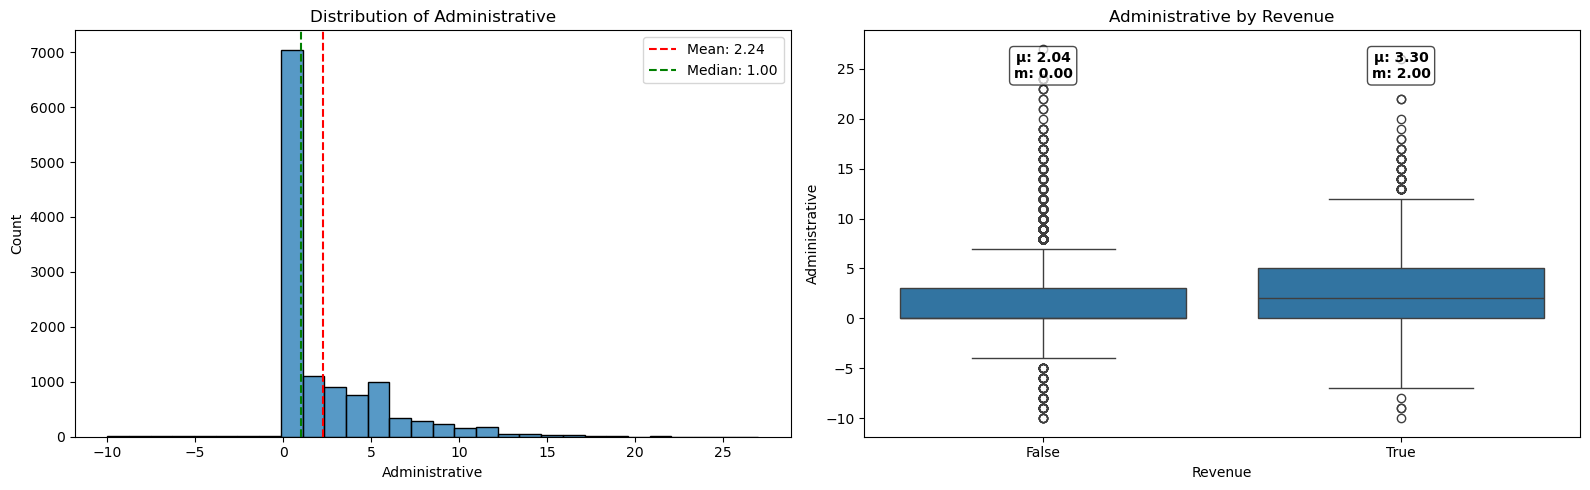


Feature: Administrative_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max        Mean  Median
 0.0 989493.0 1269.776004     8.0


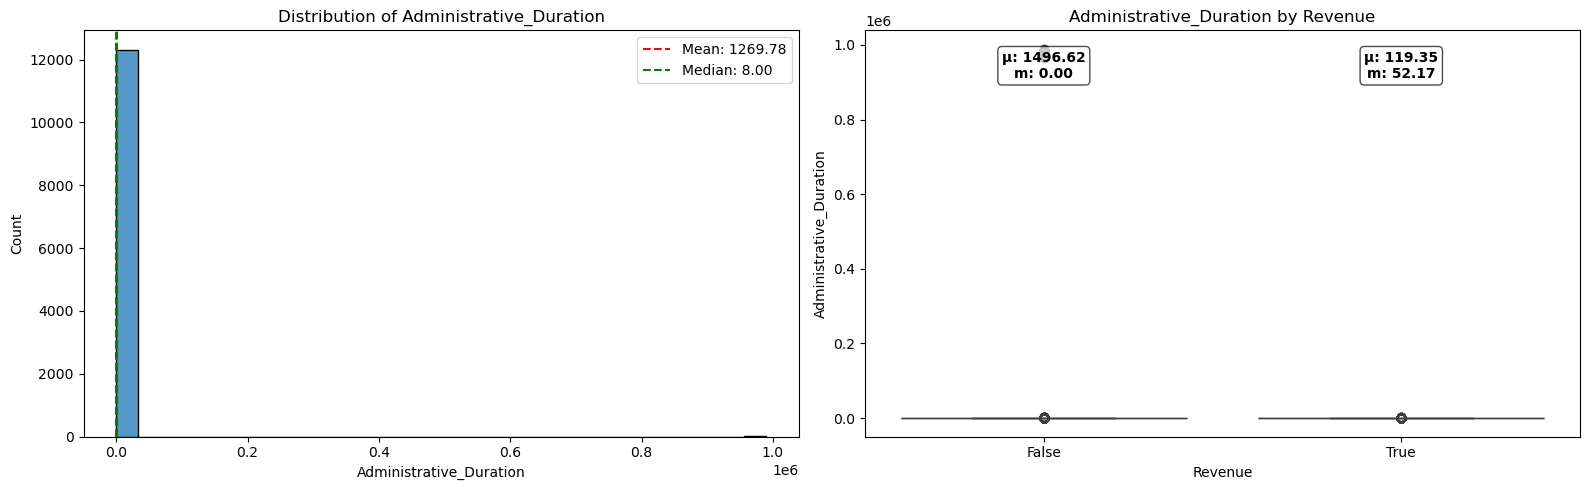


Feature: Informational
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean  Median
   0   24 0.503569     0.0


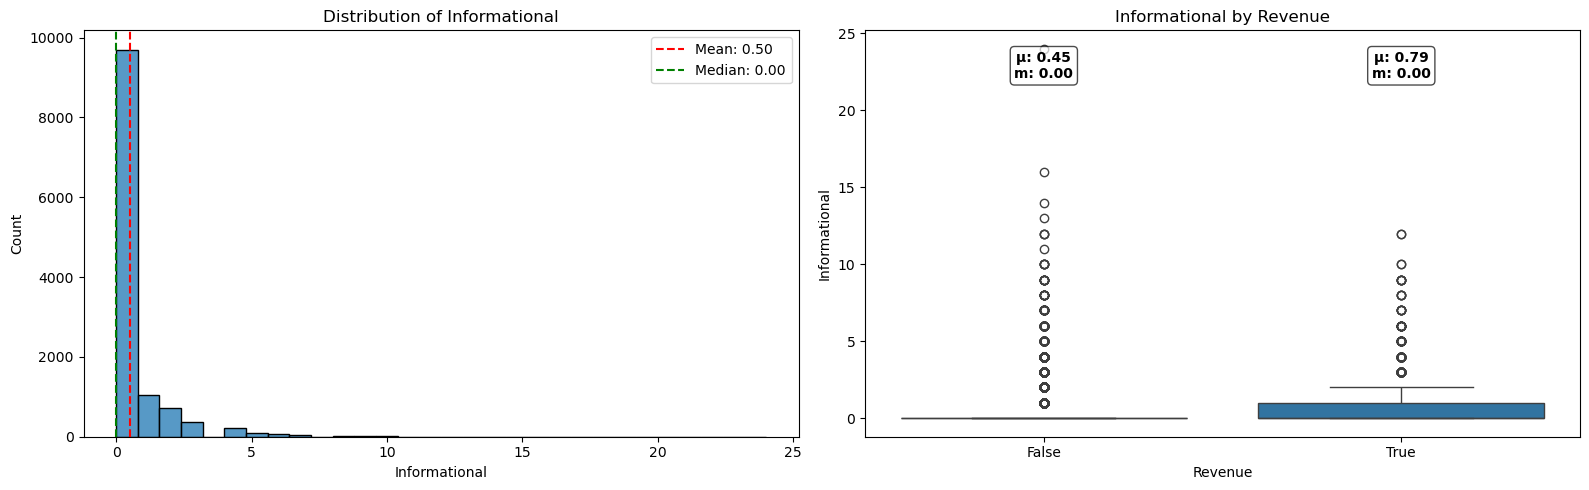


Feature: Informational_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max      Mean  Median
 0.0 2549.375 34.472398     0.0


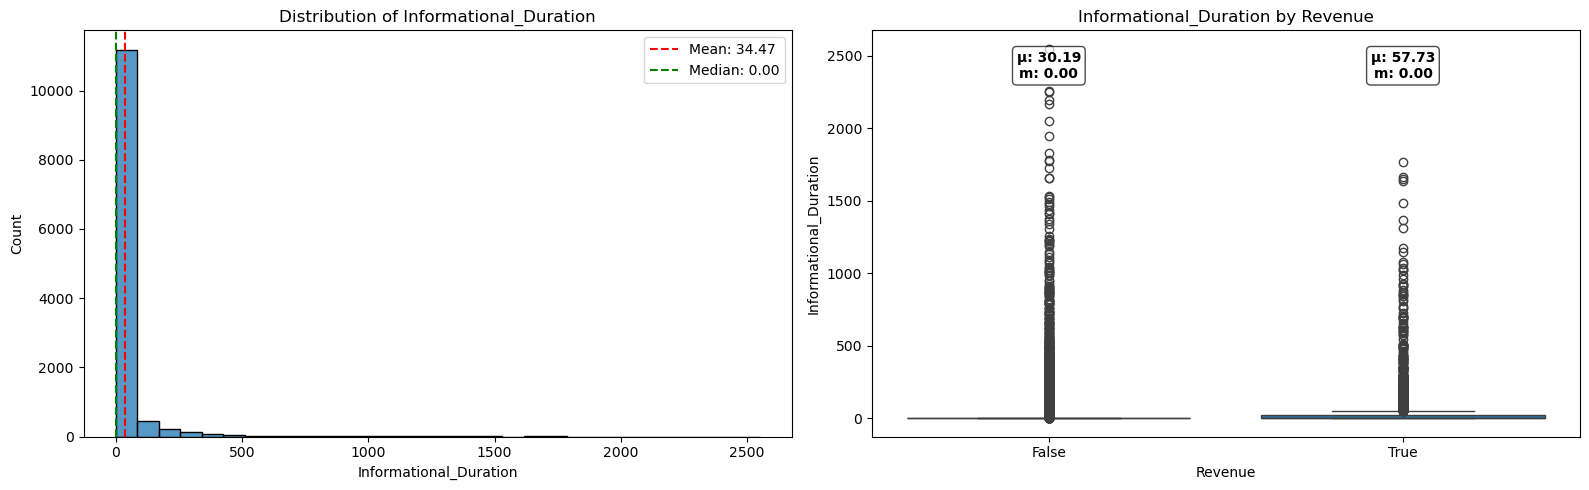


Feature: ProductRelated
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max      Mean  Median
   0  705 31.731468    18.0


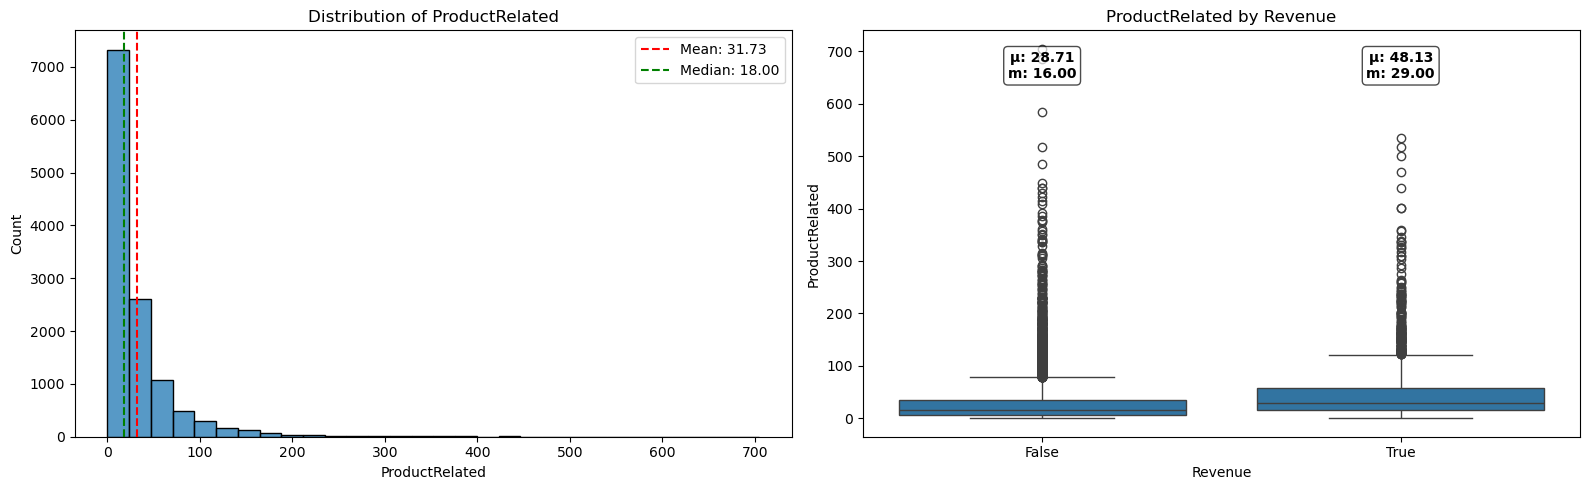


Feature: ProductRelated_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min         Max       Mean     Median
 0.0 63973.52223 1194.74622 598.936905


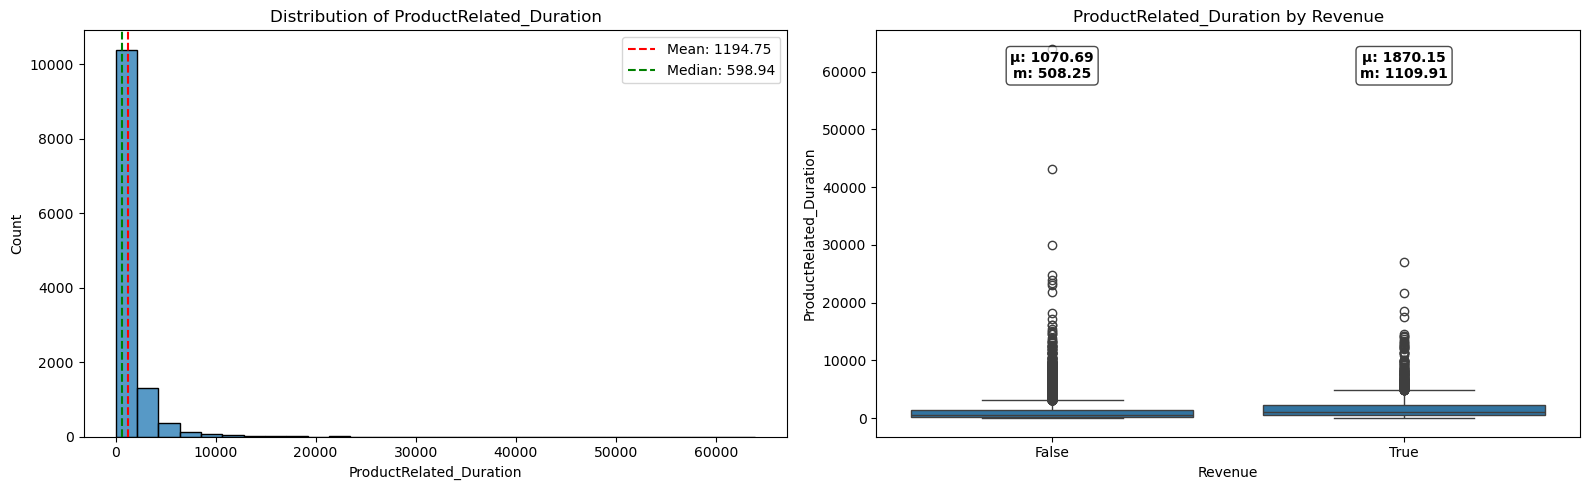


Feature: BounceRates
Description: Bounce rate of current page
Missing Values: 0 (0.00%)

Basic Statistics:
     Min      Max     Mean   Median
-0.49868 2.098952 0.044239 0.002896


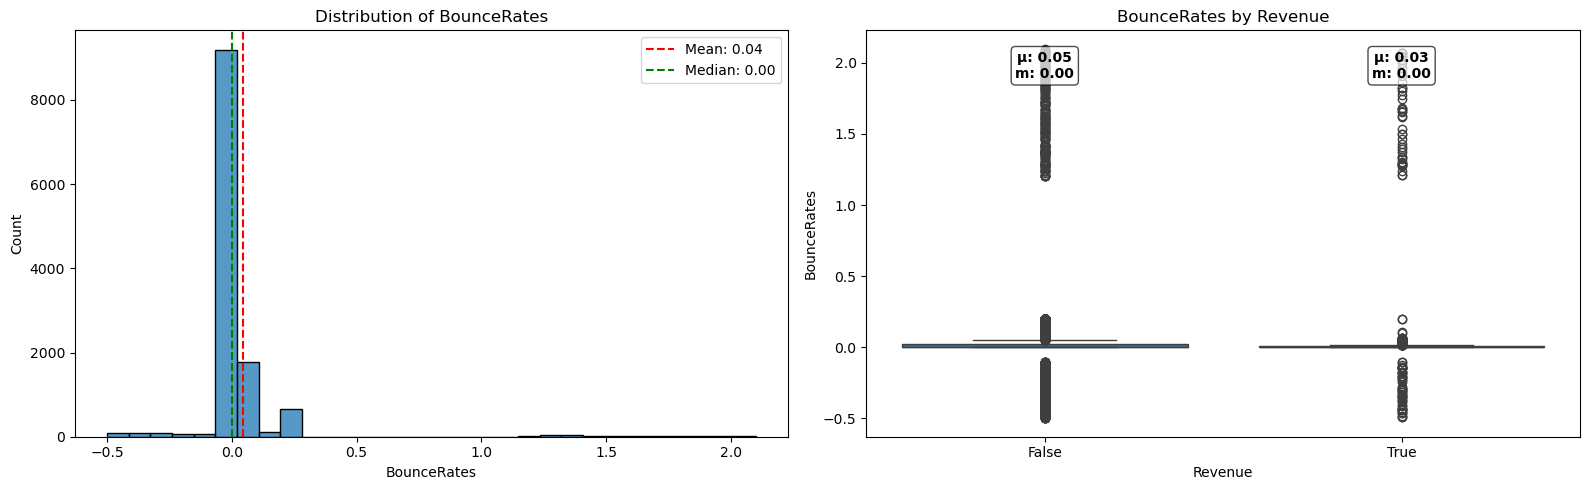


Feature: ExitRates
Description: Exit rate value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean   Median
 0.0  0.2 0.043073 0.025156


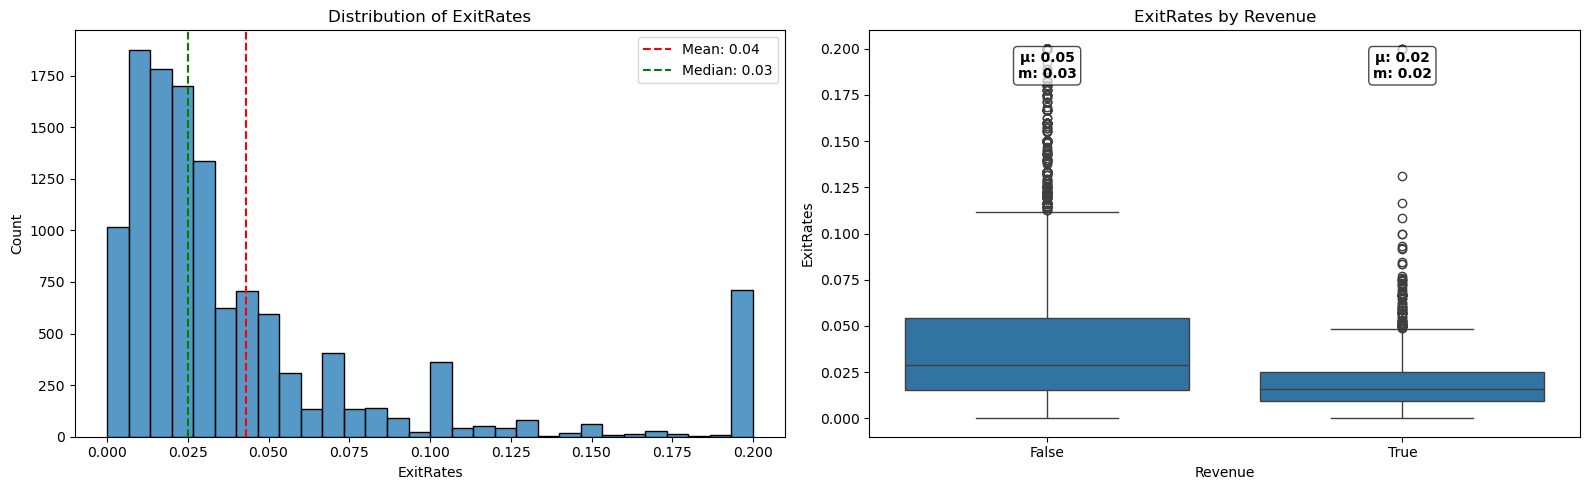


Feature: PageValues
Description: Page value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min        Max     Mean  Median
 0.0 361.763742 5.889258     0.0


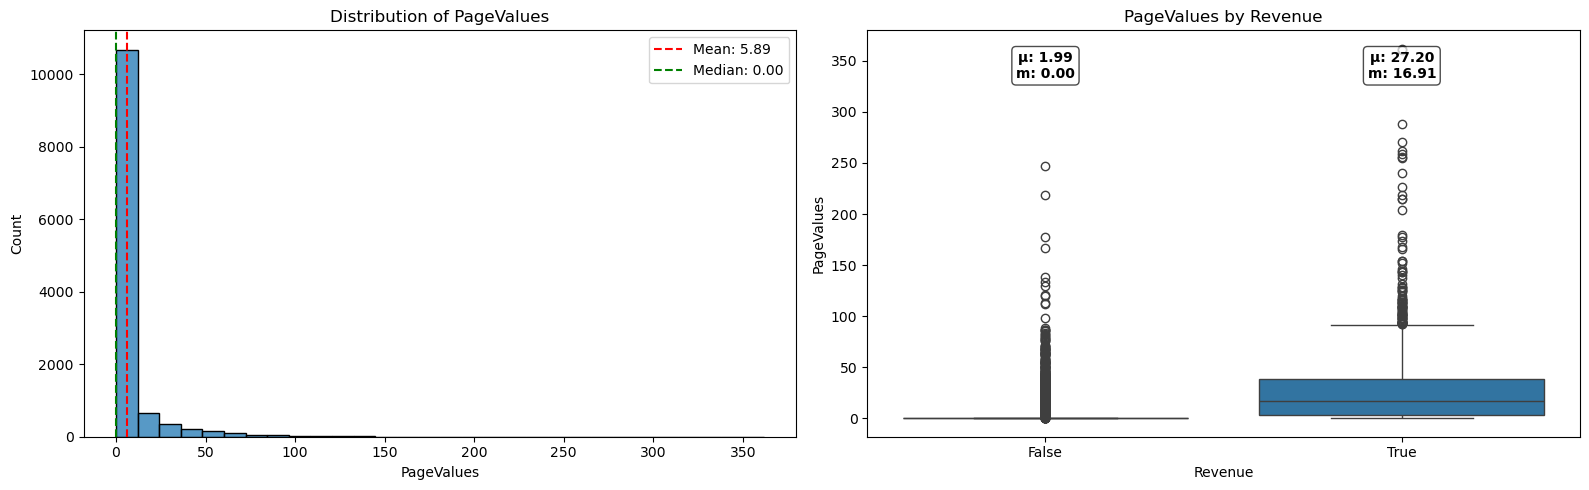


Feature: SpecialDay
Description: Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.
Missing Values: 123 (1.00%)

Basic Statistics:
 Min  Max    Mean  Median
 0.0  1.0 0.06126     0.0


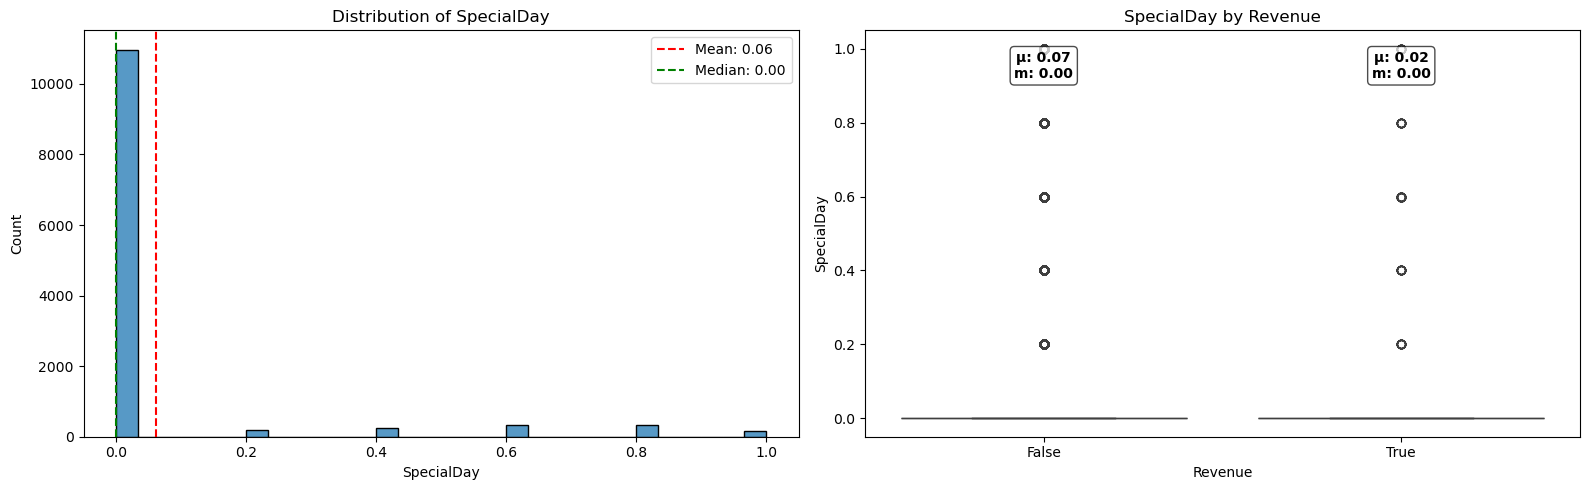


Feature: Month
Description: Month of session
Missing Values: 0 (0.00%)

Top 5 Categories:
Month
May    3196
Nov    2998
Mar    1907
Dec    1727
Oct     549


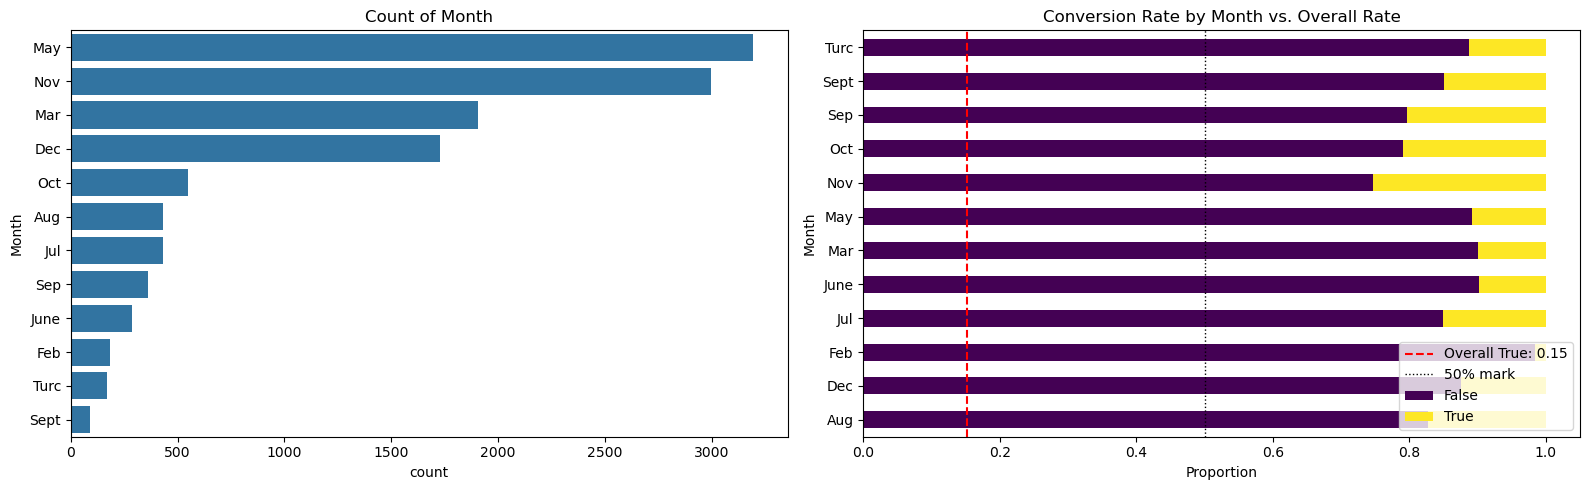


Feature: Weekend
Description: Boolean if the session day was in the weekend
Missing Values: 0 (0.00%)

Top 5 Categories:
Weekend
False        9273
True         2868
Name:Zara     189


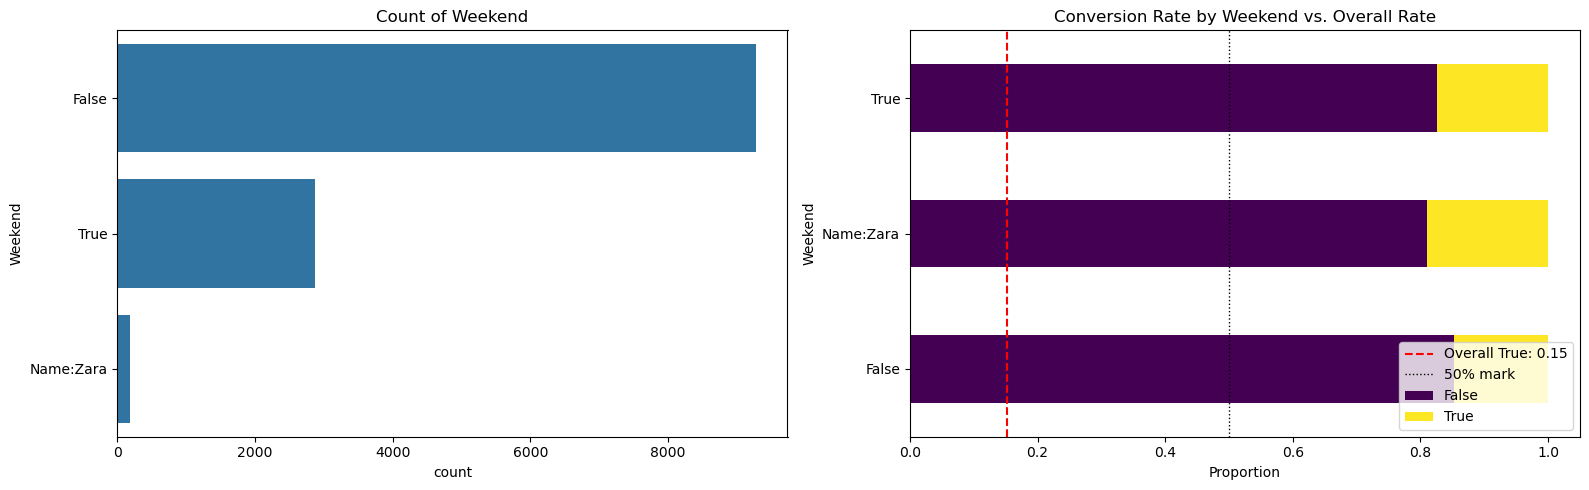


Feature: OperatingSystems
Description: Different OS' represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79


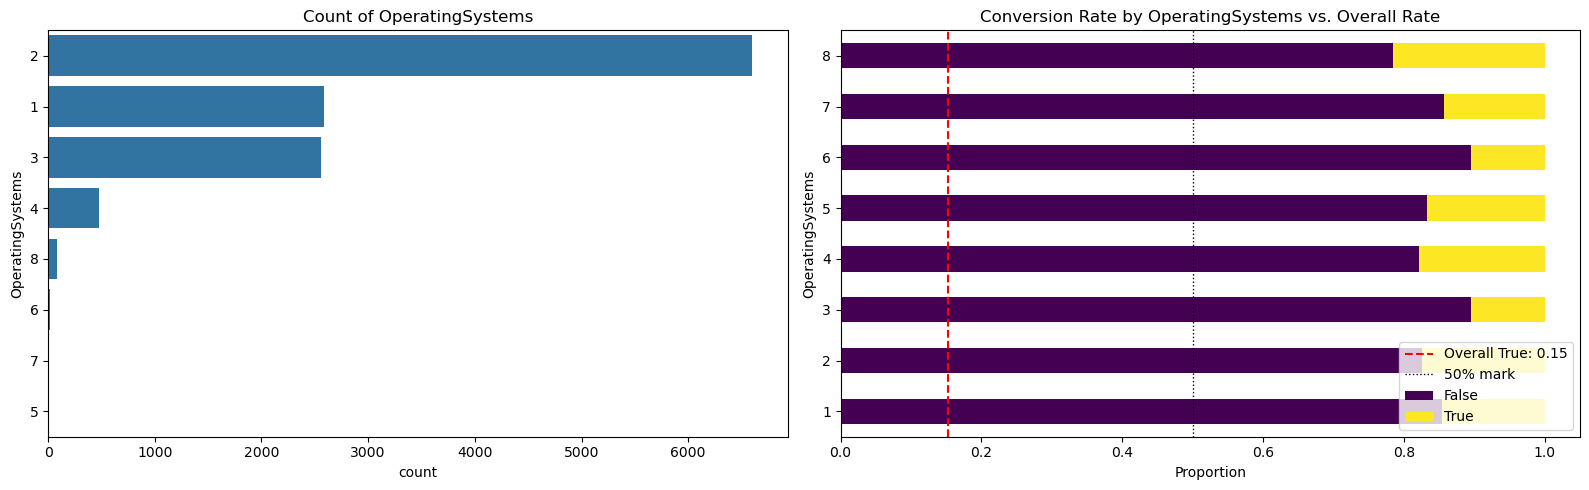


Feature: Browser
Description: Different browsers represented by different integers
Missing Values: 184 (1.49%)

Top 5 Categories:
Browser
2.0    7835
1.0    2424
4.0     725
5.0     465
6.0     171


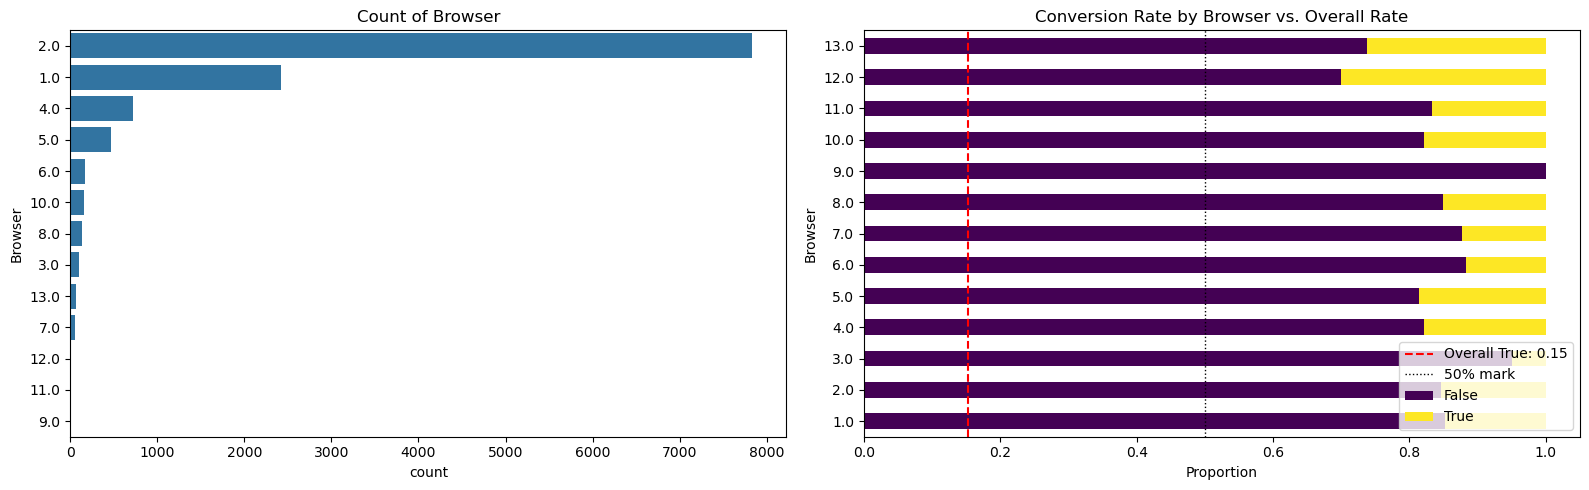


Feature: Region
Description: Different regions represented by different integers
Missing Values: 246 (2.00%)

Top 5 Categories:
Region
1.0    4695
3.0    2345
4.0    1157
2.0    1113
6.0     787


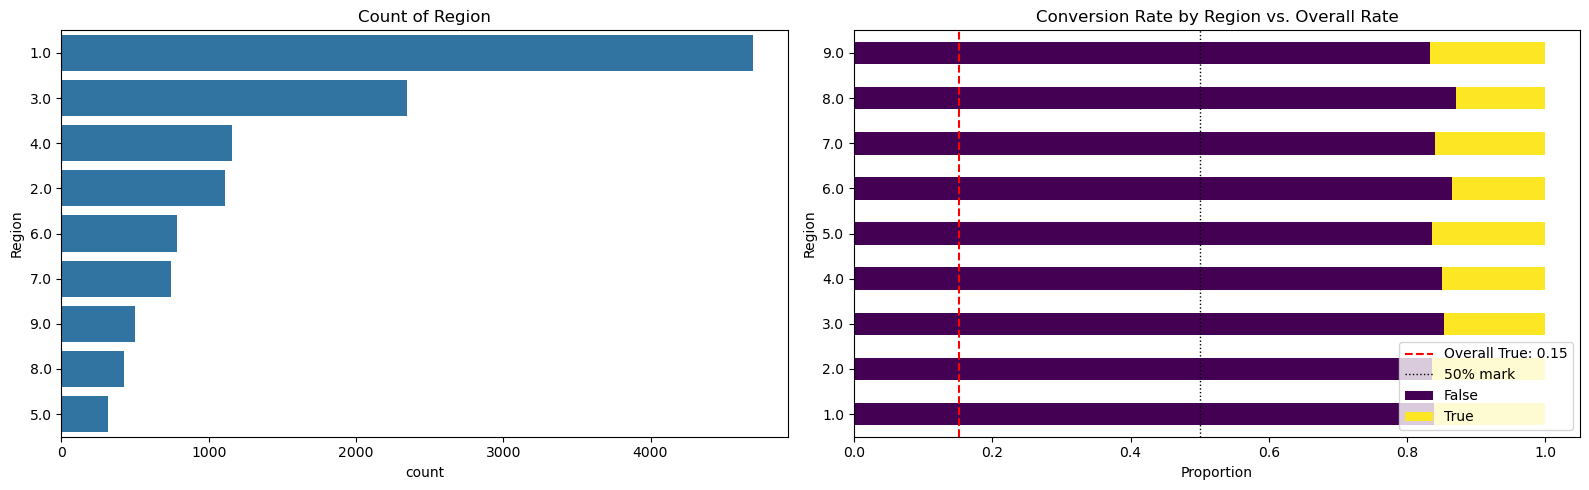


Feature: TrafficType
Description: Different traffic types represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738


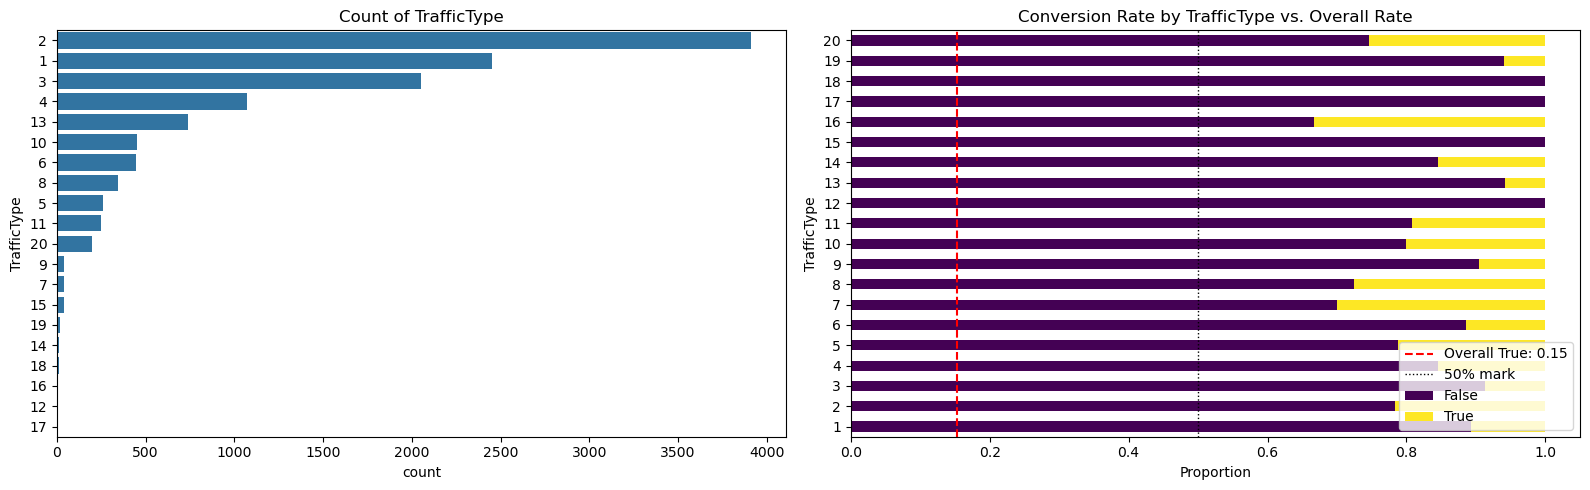


Feature: VisitorType
Description: Different visitor types represented by different categorical values
Missing Values: 0 (0.00%)

Top 5 Categories:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85


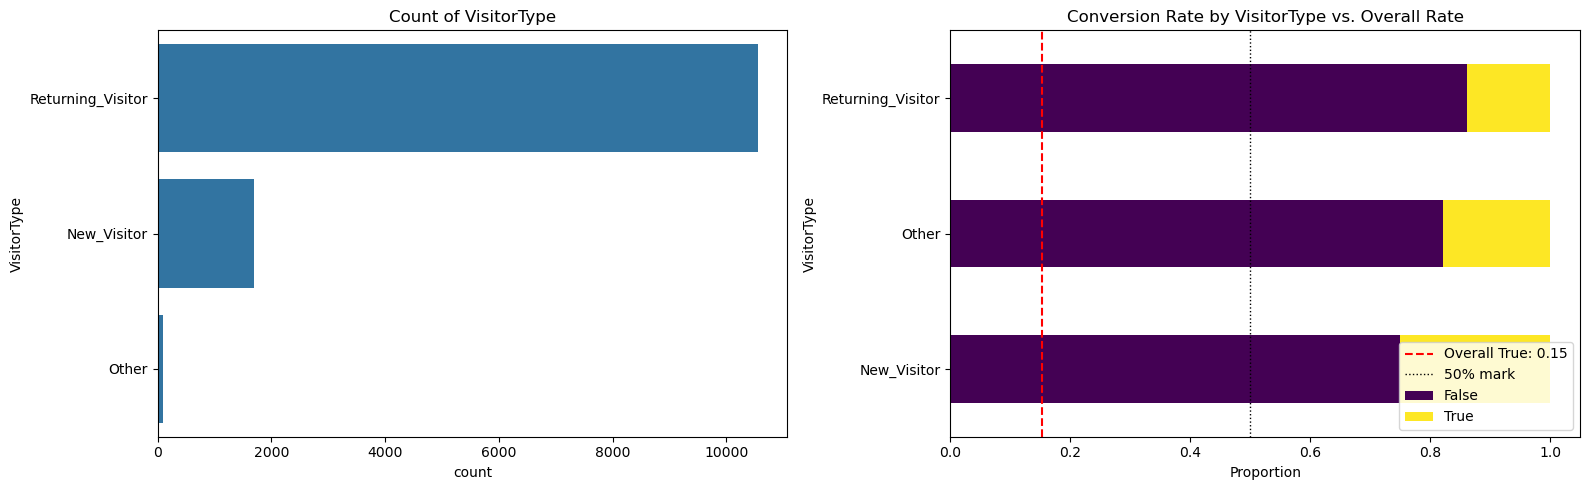

In [38]:
plot_feature_eda(session_data_df, column_descriptions)

In [39]:
def plot_feature_eda(df, column_descriptions, figsize=(16, 5), revenue_col='Revenue', n_cols=2):
    """
    Generates lightweight exploratory data analysis plots for each feature in the dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing all features
    column_descriptions : dict
        Dictionary with feature descriptions and types
    figsize : tuple, optional (default=(16, 5))
        Width, height of each row of plots
    revenue_col : str, optional (default='Revenue')
        Name of the target variable column
    n_cols : int, optional (default=2)
        Number of columns in the subplot grid
        
    Returns:
    --------
    None. Displays plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    
    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue  # Skip the target variable
            
        if isinstance(info, dict):  # If using the structured dictionary format
            if info["type"] == "numeric":
                numeric_features.append(col)
            else:
                categorical_features.append(col)
        else:  # If using the string-based format
            if "Type: numeric" in info:
                numeric_features.append(col)
            else:
                categorical_features.append(col)
    
    # Function to create plots for numeric features
    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Simple histogram with mean and median lines
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[0])
        
        # Add mean line (red dotted)
        mean_val = df[feature].mean()
        axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                       label=f'Mean: {mean_val:.2f}')
        
        # Add median line (green dotted) - using same style as mean line
        median_val = df[feature].median()
        axes[0].axvline(median_val, color='green', linestyle='--', linewidth=1.5,
                       label=f'Median: {median_val:.2f}')
        
        axes[0].legend(loc='best')
        axes[0].set_title(f'Distribution of {feature}')
        axes[0].set_xlabel(feature)
        
        # Right plot: Box plot by Revenue with mean and median annotations at the top
        sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
        
        # Add mean and median for each group at the top of the chart
        for i, rev_val in enumerate([False, True]):
            group_data = df[df[revenue_col] == rev_val][feature].dropna()
            
            if len(group_data) > 0:
                group_mean = group_data.mean()
                group_median = group_data.median()
                
                # Get y-axis limits to position annotations at the top
                ymin, ymax = axes[1].get_ylim()
                annotation_y = ymax - (ymax - ymin) * 0.05
                
                # Create combined annotation at the top
                axes[1].text(i, annotation_y, 
                           f"μ: {group_mean:.2f}\nm: {group_median:.2f}", 
                           ha='center', va='top', fontweight='bold',
                           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
                
        axes[1].set_title(f'{feature} by {revenue_col}')
            
        plt.tight_layout()
        plt.show()
    
    # Function to create plots for categorical features
    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Count plot with all categories
        order = df[feature].value_counts().index
        sns.countplot(y=feature, data=df, order=order, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)
        
        # Right plot: Stacked bar chart by Revenue showing comparison to overall conversion rate
        # Reorder the columns to make True appear on the left side
        crosstab = pd.crosstab(df[feature], df[revenue_col], normalize='index')
        if True in crosstab.columns and False in crosstab.columns:
            crosstab = crosstab[[True, False]]  # Reorder columns to put True on left
        
        # Plot with True on the left
        crosstab.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
        
        # Calculate overall proportion of True/False in the dataset
        overall_true_proportion = df[revenue_col].mean() if df[revenue_col].dtype == bool else df[revenue_col].eq(True).mean()
        
        # Add a reference line for the overall proportion - now on the left side
        axes[1].axvline(x=overall_true_proportion, color='red', linestyle='--', linewidth=1.5,
                        label=f'Overall True: {overall_true_proportion:.2f}')
        
        axes[1].legend(loc='lower right')
        axes[1].set_title(f'Conversion Rate by {feature} vs. Overall Rate')
        axes[1].set_xlabel('Proportion')
        axes[1].set_ylabel(feature)
        
        plt.tight_layout()
        plt.show()
    
    # Function to show basic stats before plotting
    def plot_feature(feature):
        print(f"\n{'='*40}")
        
        # Extract and print feature description
        if isinstance(column_descriptions[feature], dict):
            desc = column_descriptions[feature]["description"]
        else:
            desc = column_descriptions[feature].split("Type:")[0].strip()
            
        print(f"Feature: {feature}")
        print(f"Description: {desc}")
        print(f"Missing Values: {df[feature].isna().sum()} ({df[feature].isna().mean():.2%})")
        
        if feature in numeric_features:
            # Print only basic summary statistics
            stats_df = pd.DataFrame({
                'Min': df[feature].min(),
                'Max': df[feature].max(),
                'Mean': df[feature].mean(),
                'Median': df[feature].median()
            }, index=[0])
            print("\nBasic Statistics:")
            print(stats_df.to_string(index=False))
            
            plot_numeric_feature(feature)
        else:
            # Print only top categories
            value_counts = df[feature].value_counts()
            print("\nTop 5 Categories:")
            print(value_counts.head(5).to_string())
            
            plot_categorical_feature(feature)
    
    # Plot each feature
    for feature in numeric_features + categorical_features:
        plot_feature(feature)


Feature: Administrative
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max   Mean  Median
 -10   27 2.2382     1.0


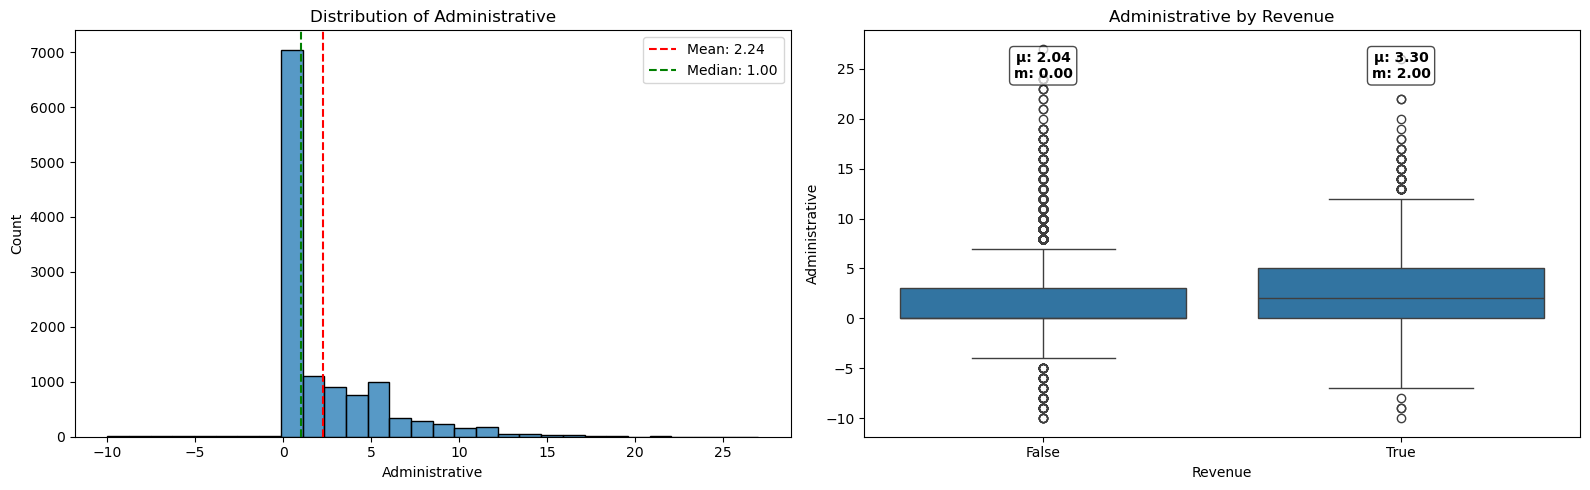


Feature: Administrative_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max        Mean  Median
 0.0 989493.0 1269.776004     8.0


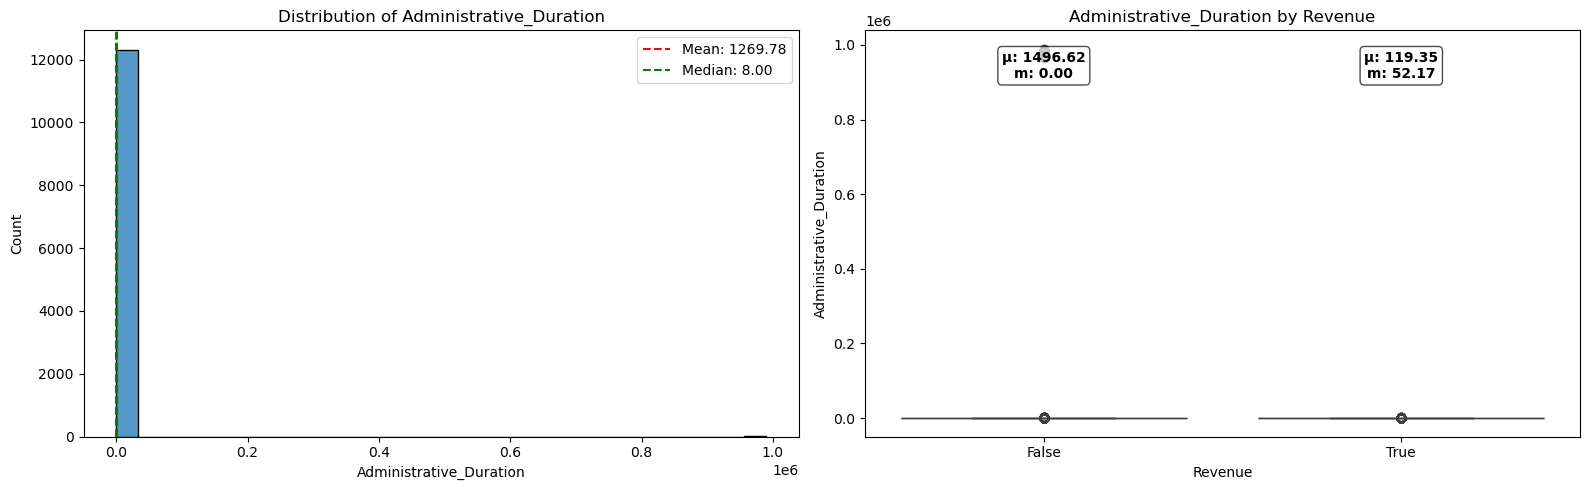


Feature: Informational
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean  Median
   0   24 0.503569     0.0


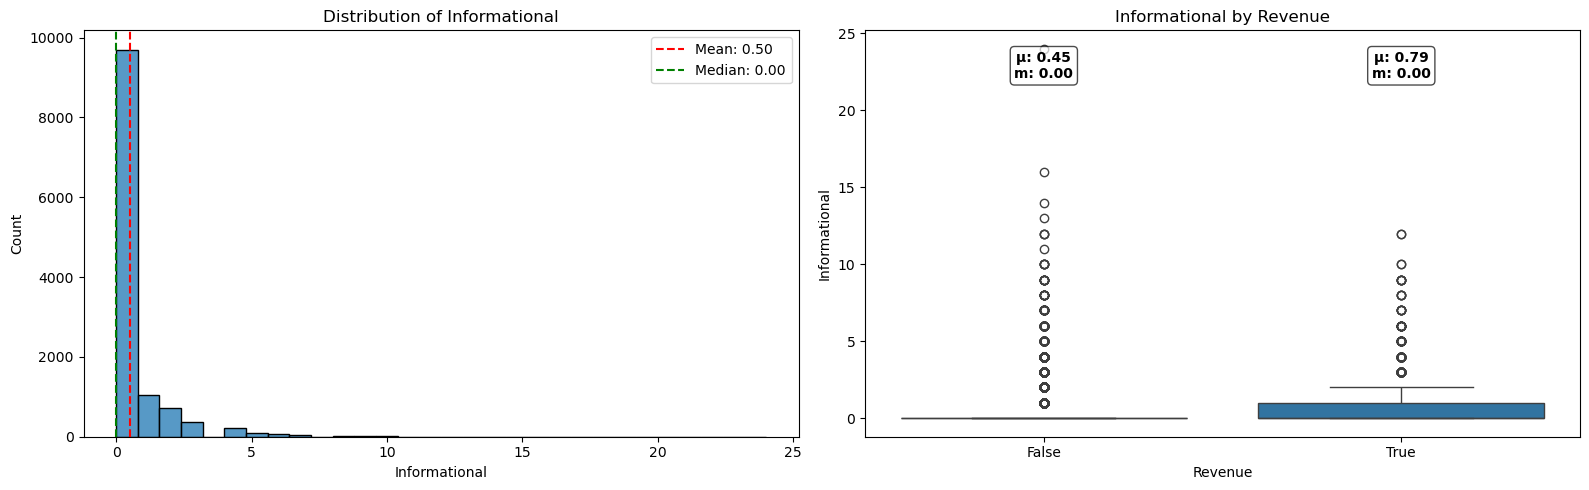


Feature: Informational_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max      Mean  Median
 0.0 2549.375 34.472398     0.0


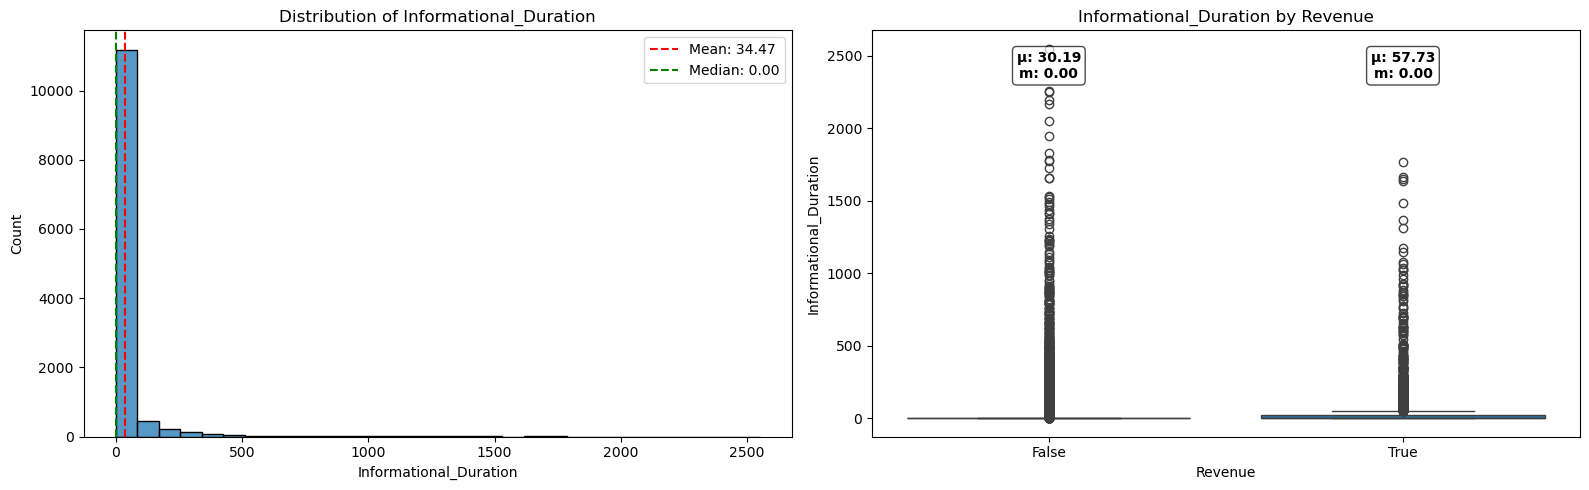


Feature: ProductRelated
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max      Mean  Median
   0  705 31.731468    18.0


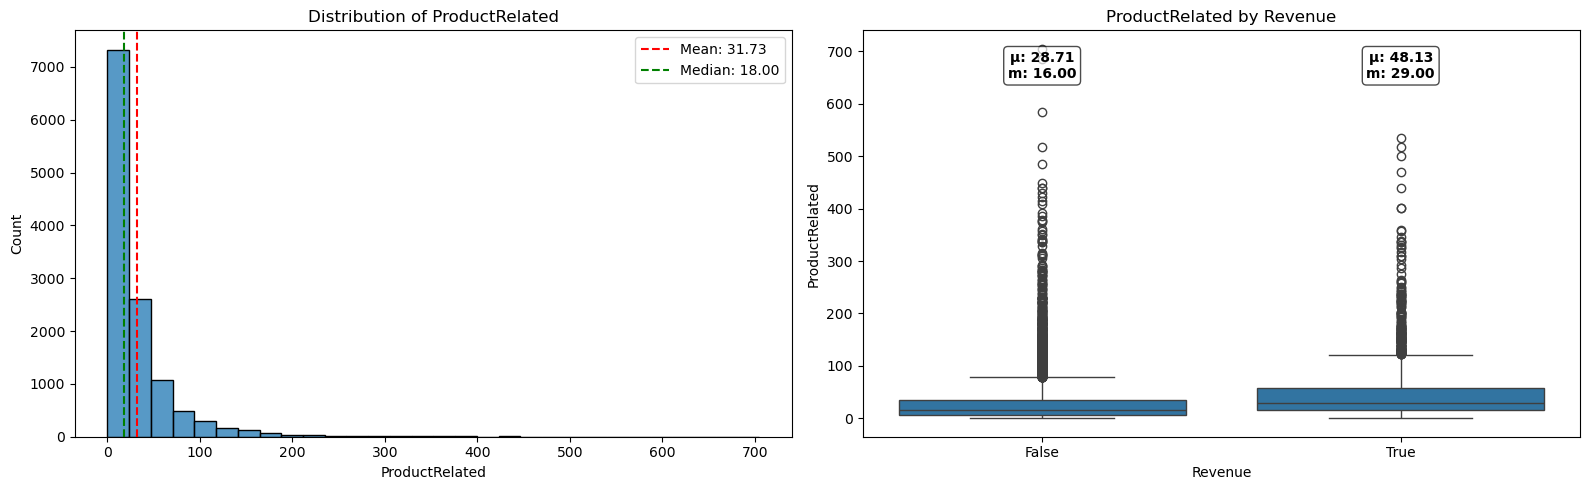


Feature: ProductRelated_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min         Max       Mean     Median
 0.0 63973.52223 1194.74622 598.936905


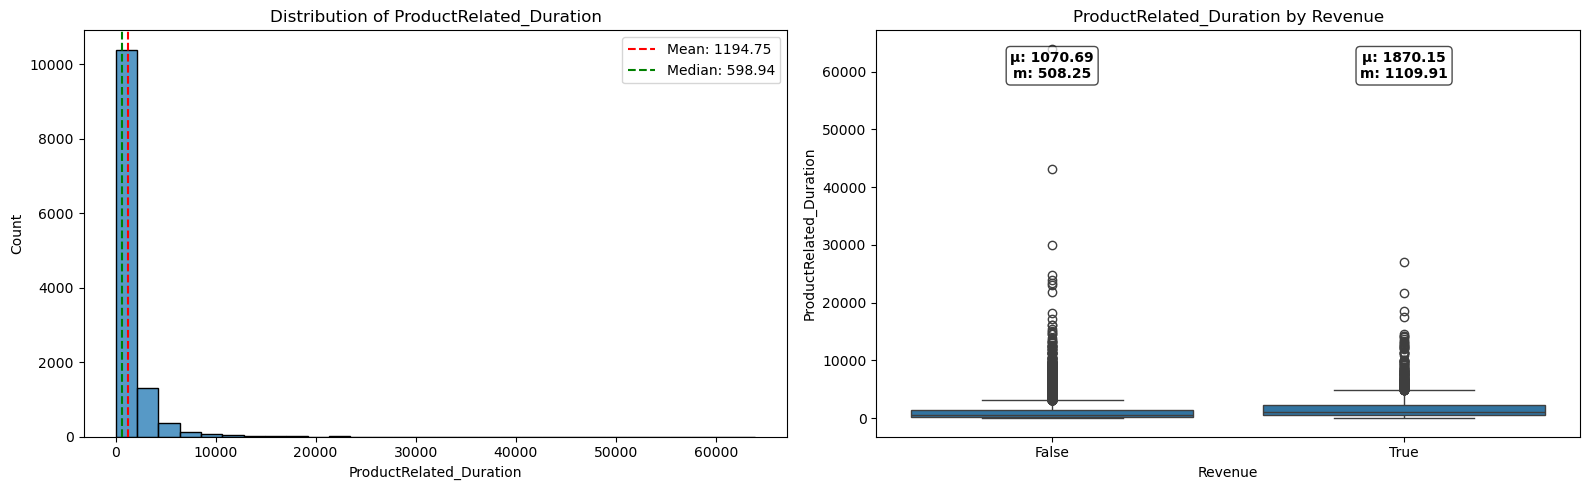


Feature: BounceRates
Description: Bounce rate of current page
Missing Values: 0 (0.00%)

Basic Statistics:
     Min      Max     Mean   Median
-0.49868 2.098952 0.044239 0.002896


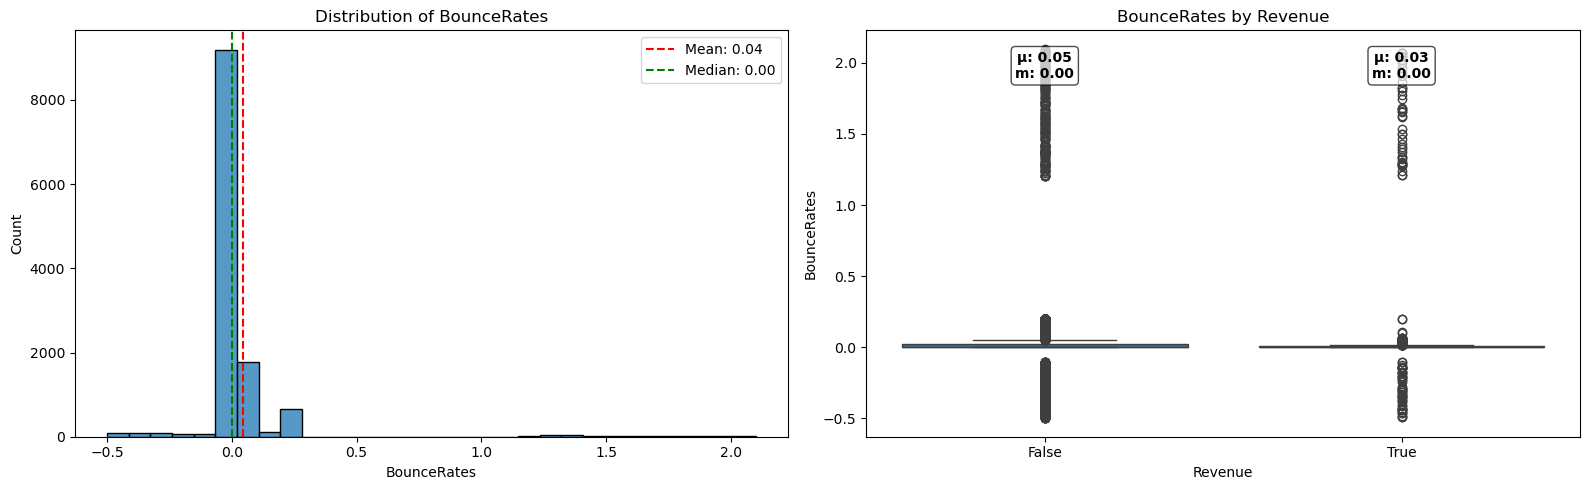


Feature: ExitRates
Description: Exit rate value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean   Median
 0.0  0.2 0.043073 0.025156


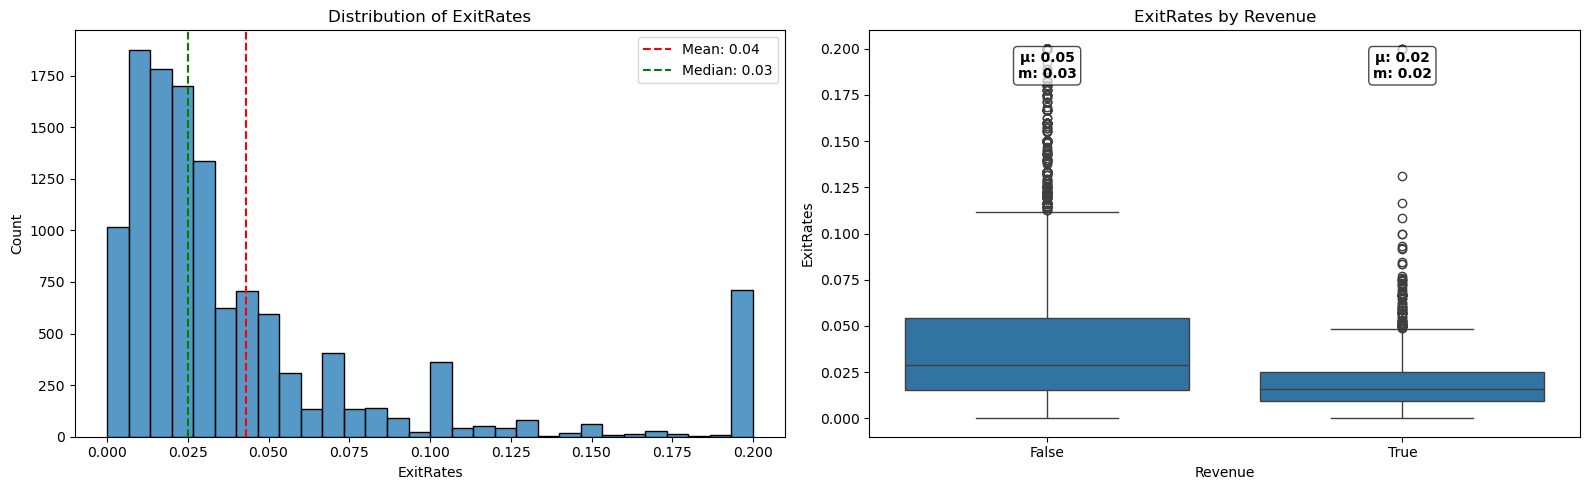


Feature: PageValues
Description: Page value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min        Max     Mean  Median
 0.0 361.763742 5.889258     0.0


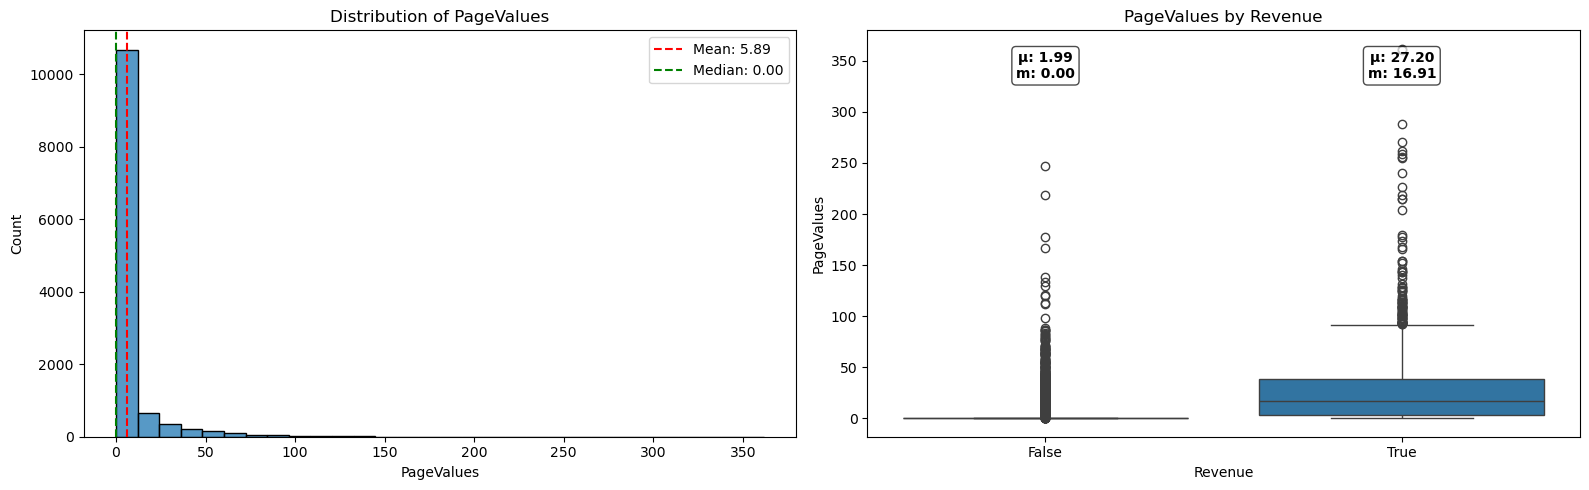


Feature: SpecialDay
Description: Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.
Missing Values: 123 (1.00%)

Basic Statistics:
 Min  Max    Mean  Median
 0.0  1.0 0.06126     0.0


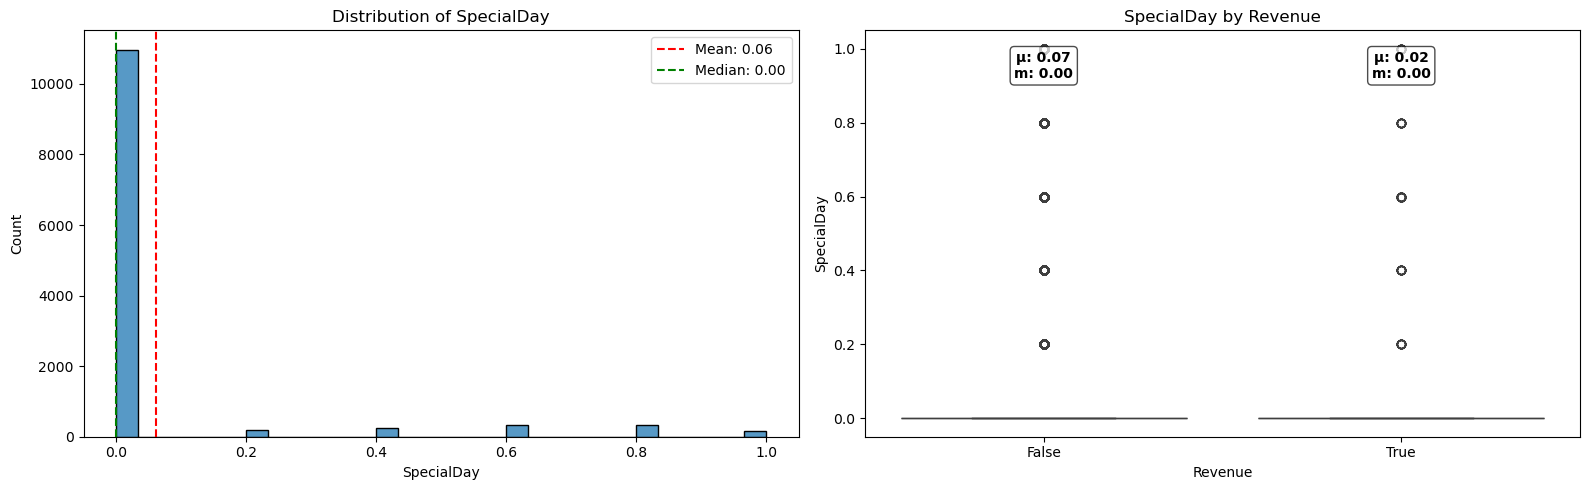


Feature: Month
Description: Month of session
Missing Values: 0 (0.00%)

Top 5 Categories:
Month
May    3196
Nov    2998
Mar    1907
Dec    1727
Oct     549


ValueError: Item wrong length 2 instead of 12.

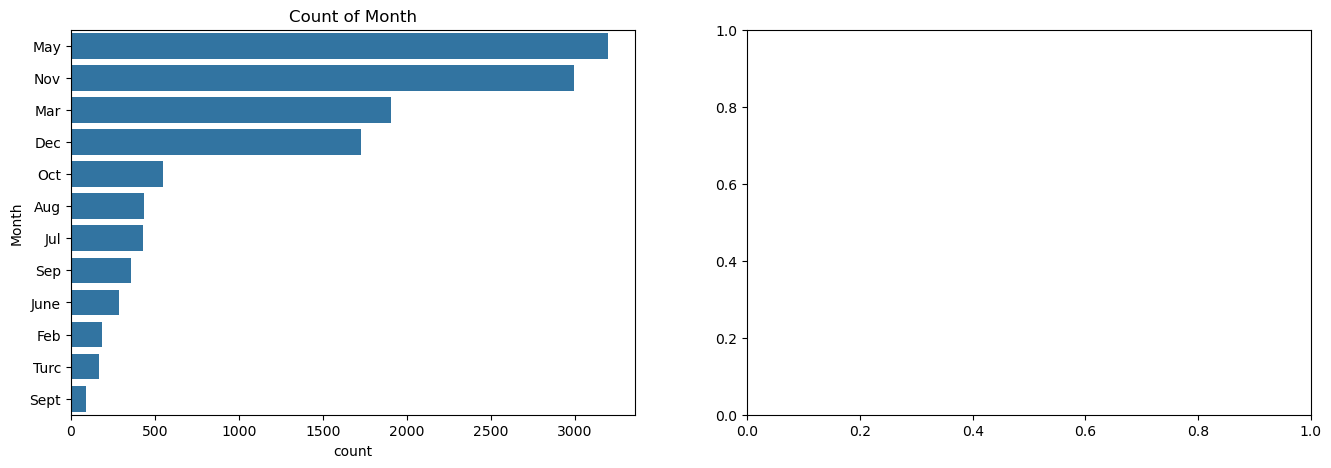

In [41]:
plot_feature_eda(session_data_df, column_descriptions)

In [42]:
def plot_feature_eda(df, column_descriptions, figsize=(16, 5), revenue_col='Revenue', n_cols=2):
    """
    Generates lightweight exploratory data analysis plots for each feature in the dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing all features
    column_descriptions : dict
        Dictionary with feature descriptions and types
    figsize : tuple, optional (default=(16, 5))
        Width, height of each row of plots
    revenue_col : str, optional (default='Revenue')
        Name of the target variable column
    n_cols : int, optional (default=2)
        Number of columns in the subplot grid
        
    Returns:
    --------
    None. Displays plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    
    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue  # Skip the target variable
            
        if isinstance(info, dict):  # If using the structured dictionary format
            if info["type"] == "numeric":
                numeric_features.append(col)
            else:
                categorical_features.append(col)
        else:  # If using the string-based format
            if "Type: numeric" in info:
                numeric_features.append(col)
            else:
                categorical_features.append(col)
    
    # Function to create plots for numeric features
    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Simple histogram with mean and median lines
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[0])
        
        # Add mean line (red dotted)
        mean_val = df[feature].mean()
        axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                       label=f'Mean: {mean_val:.2f}')
        
        # Add median line (green dotted) - using same style as mean line
        median_val = df[feature].median()
        axes[0].axvline(median_val, color='green', linestyle='--', linewidth=1.5,
                       label=f'Median: {median_val:.2f}')
        
        axes[0].legend(loc='best')
        axes[0].set_title(f'Distribution of {feature}')
        axes[0].set_xlabel(feature)
        
        # Right plot: Box plot by Revenue with mean and median annotations at the top
        sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
        
        # Add mean and median for each group at the top of the chart
        for i, rev_val in enumerate([False, True]):
            group_data = df[df[revenue_col] == rev_val][feature].dropna()
            
            if len(group_data) > 0:
                group_mean = group_data.mean()
                group_median = group_data.median()
                
                # Get y-axis limits to position annotations at the top
                ymin, ymax = axes[1].get_ylim()
                annotation_y = ymax - (ymax - ymin) * 0.05
                
                # Create combined annotation at the top
                axes[1].text(i, annotation_y, 
                           f"μ: {group_mean:.2f}\nm: {group_median:.2f}", 
                           ha='center', va='top', fontweight='bold',
                           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
                
        axes[1].set_title(f'{feature} by {revenue_col}')
            
        plt.tight_layout()
        plt.show()
    
    # Function to create plots for categorical features
    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Count plot with all categories
        order = df[feature].value_counts().index
        sns.countplot(y=feature, data=df, order=order, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)
        
        # Right plot: Stacked bar chart by Revenue showing comparison to overall conversion rate
        crosstab = pd.crosstab(df[feature], df[revenue_col], normalize='index')
        
        # Try to reorder columns to make True appear on the left side, but handle both string and boolean types
        column_order = []
        if 'True' in crosstab.columns and 'False' in crosstab.columns:
            column_order = ['True', 'False']
        elif True in crosstab.columns and False in crosstab.columns:
            column_order = [True, False]
            
        if column_order:
            try:
                crosstab = crosstab[column_order]  # Reorder columns to put True on left
            except:
                # If reordering fails, just use the original order
                pass
        
        # Plot with True hopefully on the left
        crosstab.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
        
        # Calculate overall proportion of True/False in the dataset
        overall_true_proportion = df[revenue_col].mean() if df[revenue_col].dtype == bool else df[revenue_col].eq(True).mean()
        
        # Add a reference line for the overall proportion - now on the left side
        axes[1].axvline(x=overall_true_proportion, color='red', linestyle='--', linewidth=1.5,
                        label=f'Overall True: {overall_true_proportion:.2f}')
        
        axes[1].legend(loc='lower right')
        axes[1].set_title(f'Conversion Rate by {feature} vs. Overall Rate')
        axes[1].set_xlabel('Proportion')
        axes[1].set_ylabel(feature)
        
        plt.tight_layout()
        plt.show()
    
    # Function to show basic stats before plotting
    def plot_feature(feature):
        print(f"\n{'='*40}")
        
        # Extract and print feature description
        if isinstance(column_descriptions[feature], dict):
            desc = column_descriptions[feature]["description"]
        else:
            desc = column_descriptions[feature].split("Type:")[0].strip()
            
        print(f"Feature: {feature}")
        print(f"Description: {desc}")
        print(f"Missing Values: {df[feature].isna().sum()} ({df[feature].isna().mean():.2%})")
        
        if feature in numeric_features:
            # Print only basic summary statistics
            stats_df = pd.DataFrame({
                'Min': df[feature].min(),
                'Max': df[feature].max(),
                'Mean': df[feature].mean(),
                'Median': df[feature].median()
            }, index=[0])
            print("\nBasic Statistics:")
            print(stats_df.to_string(index=False))
            
            plot_numeric_feature(feature)
        else:
            # Print only top categories
            value_counts = df[feature].value_counts()
            print("\nTop 5 Categories:")
            print(value_counts.head(5).to_string())
            
            plot_categorical_feature(feature)
    
    # Plot each feature
    for feature in numeric_features + categorical_features:
        plot_feature(feature)


Feature: Administrative
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max   Mean  Median
 -10   27 2.2382     1.0


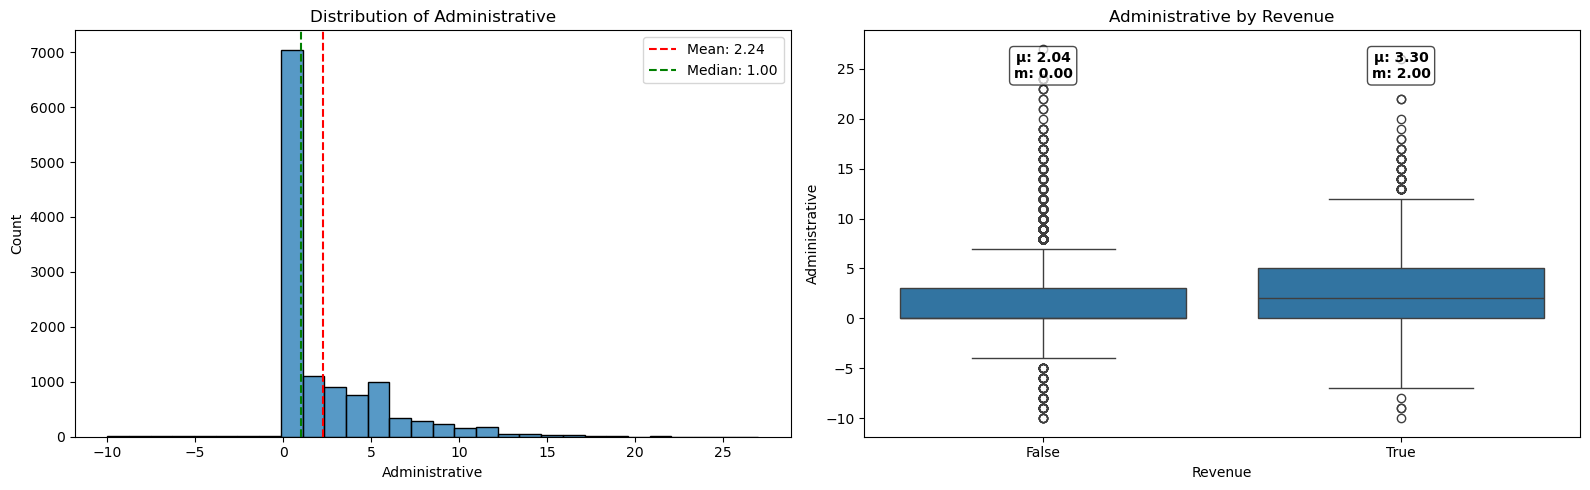


Feature: Administrative_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max        Mean  Median
 0.0 989493.0 1269.776004     8.0


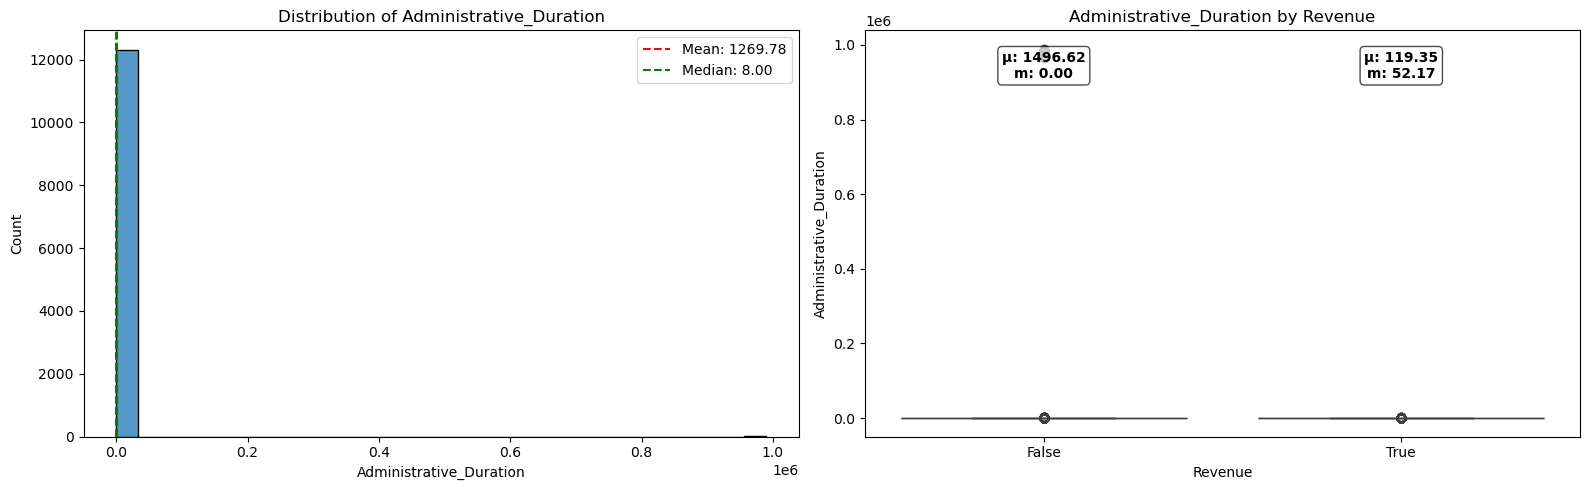


Feature: Informational
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean  Median
   0   24 0.503569     0.0


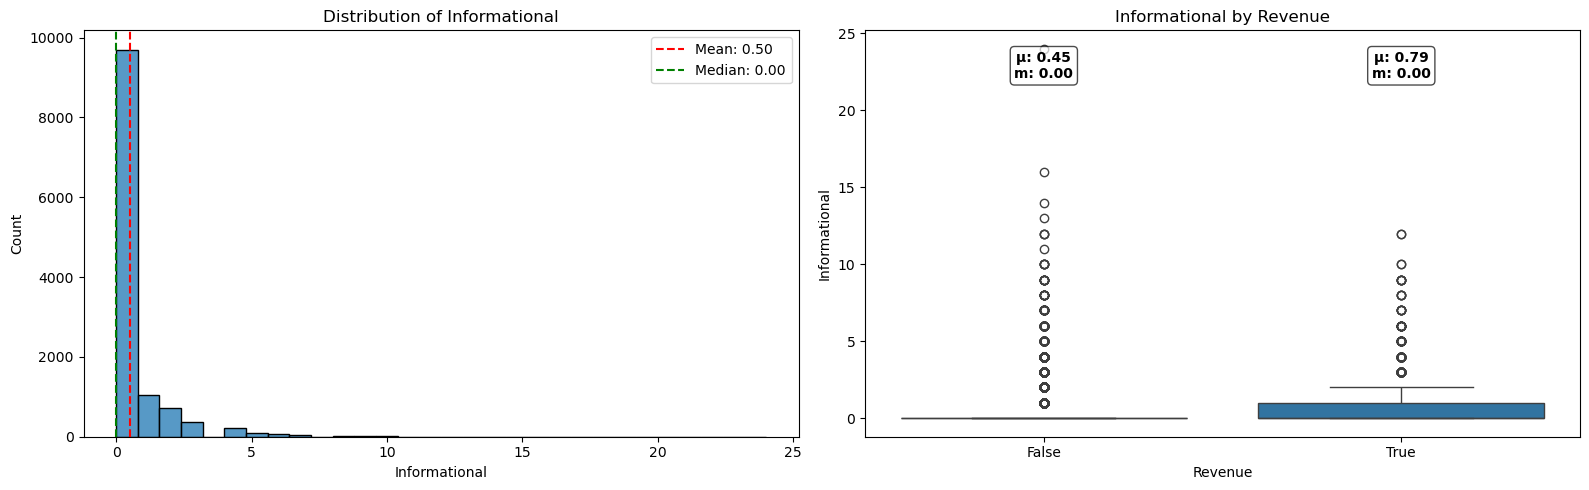


Feature: Informational_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max      Mean  Median
 0.0 2549.375 34.472398     0.0


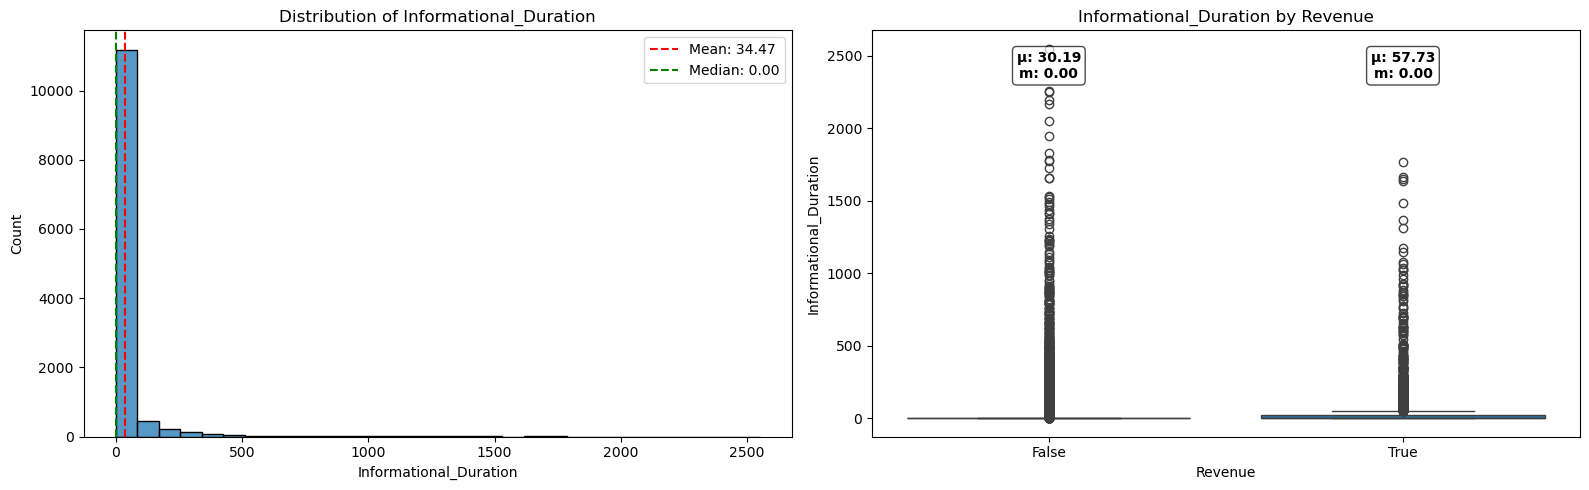


Feature: ProductRelated
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max      Mean  Median
   0  705 31.731468    18.0


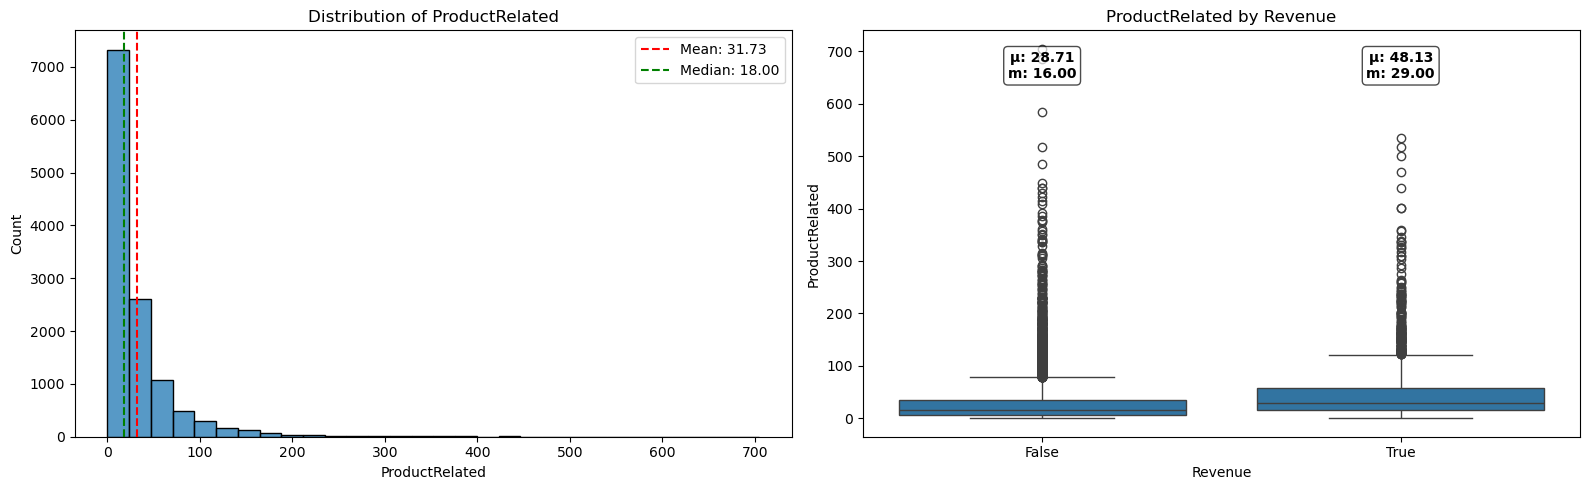


Feature: ProductRelated_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min         Max       Mean     Median
 0.0 63973.52223 1194.74622 598.936905


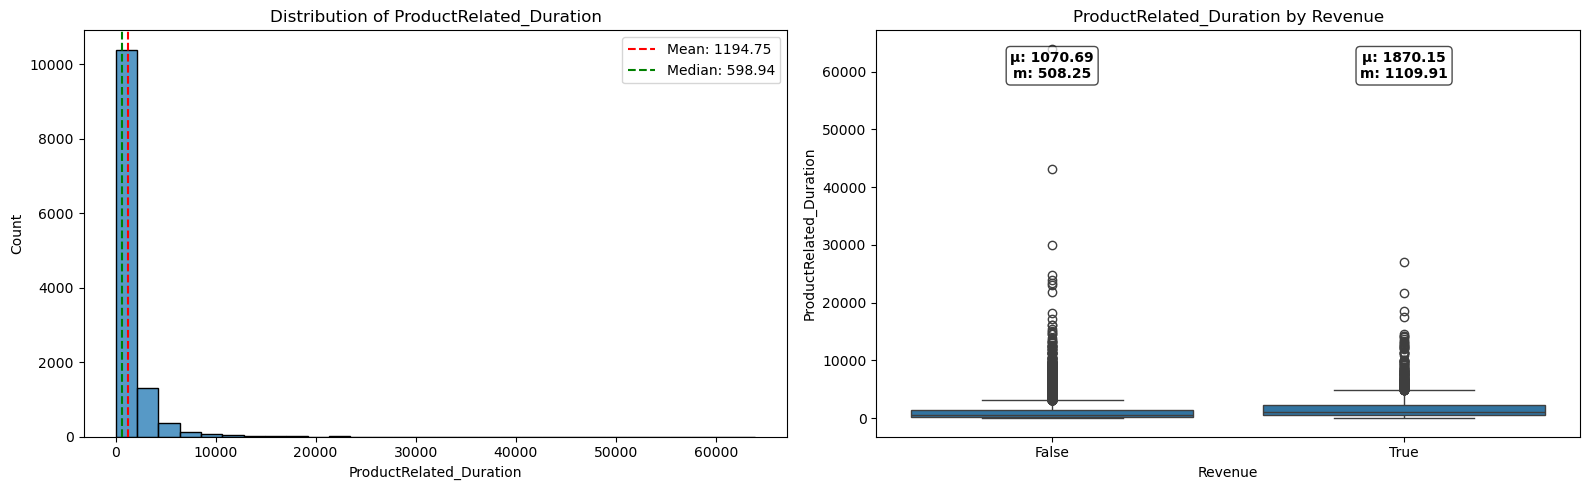


Feature: BounceRates
Description: Bounce rate of current page
Missing Values: 0 (0.00%)

Basic Statistics:
     Min      Max     Mean   Median
-0.49868 2.098952 0.044239 0.002896


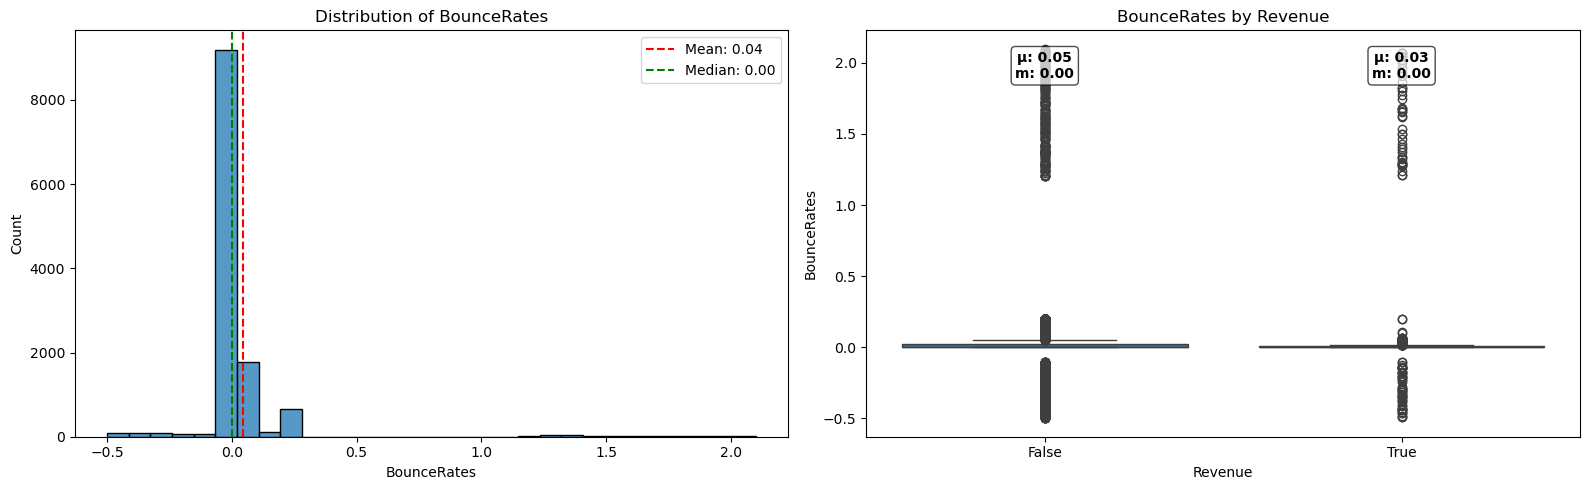


Feature: ExitRates
Description: Exit rate value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean   Median
 0.0  0.2 0.043073 0.025156


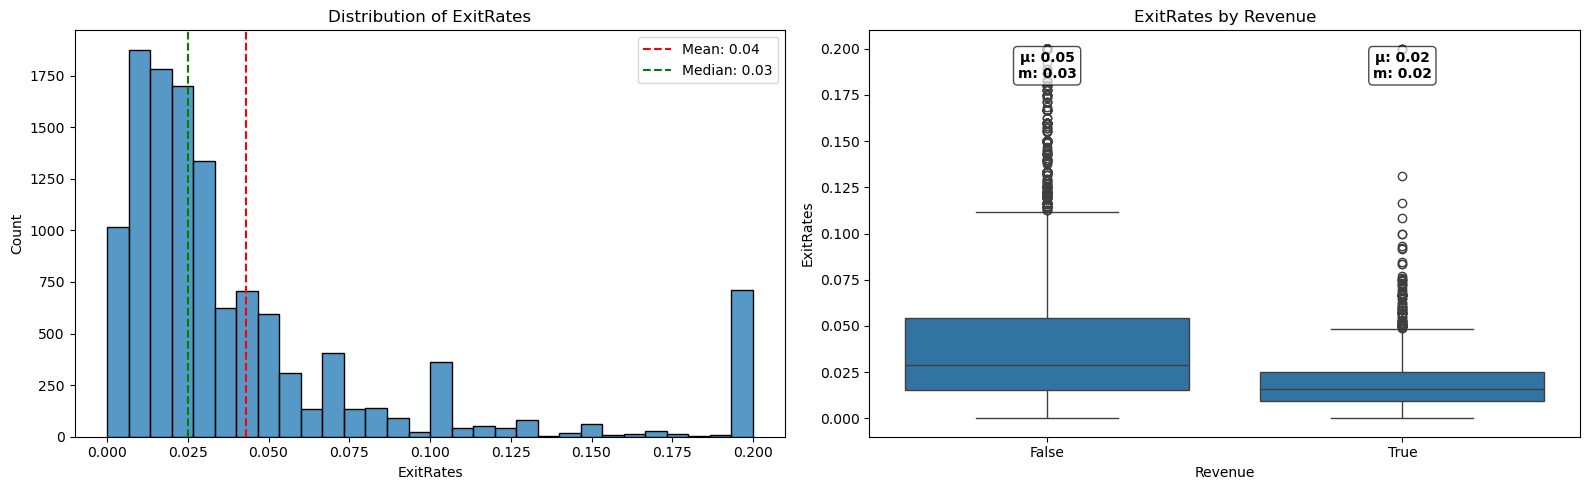


Feature: PageValues
Description: Page value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min        Max     Mean  Median
 0.0 361.763742 5.889258     0.0


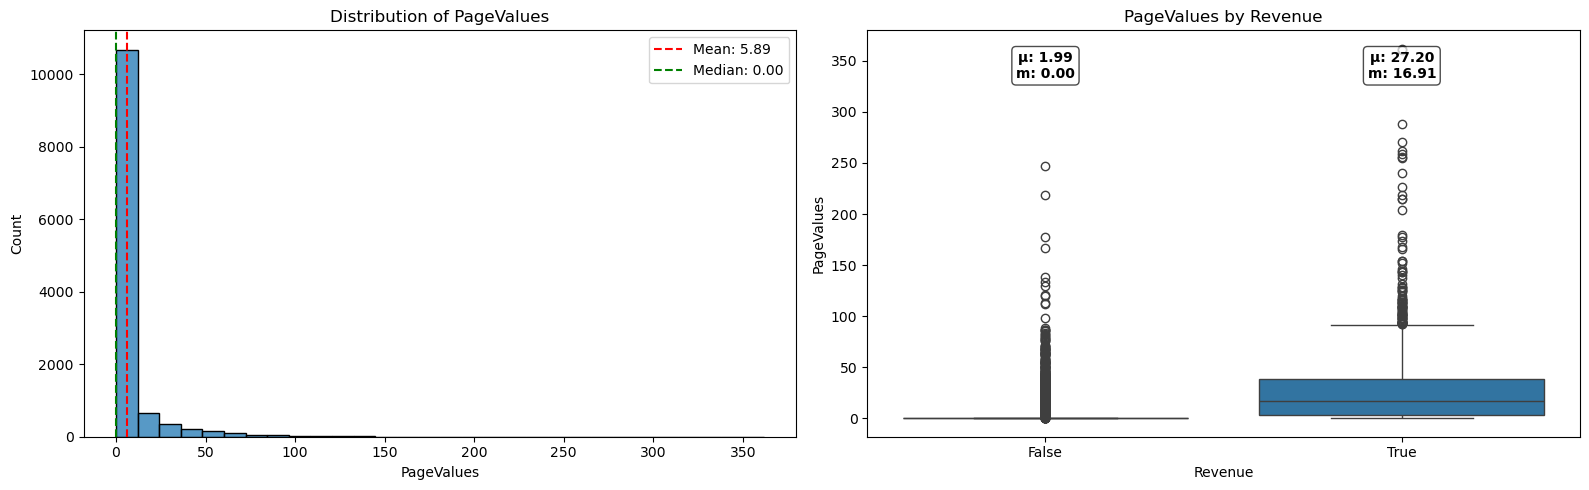


Feature: SpecialDay
Description: Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.
Missing Values: 123 (1.00%)

Basic Statistics:
 Min  Max    Mean  Median
 0.0  1.0 0.06126     0.0


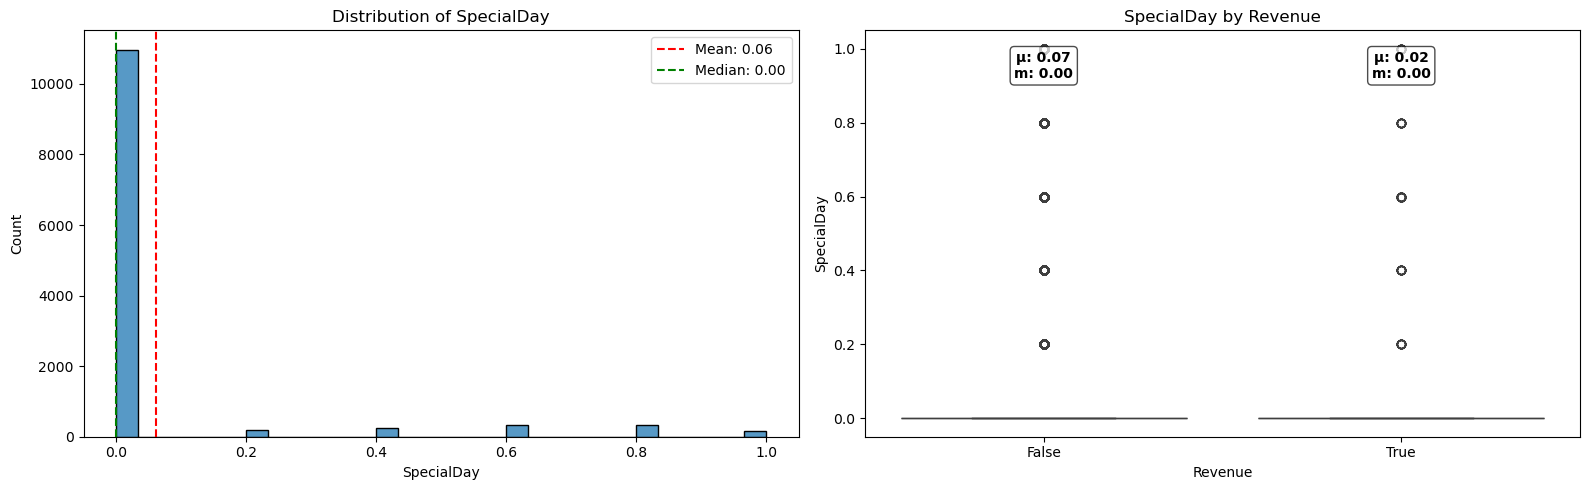


Feature: Month
Description: Month of session
Missing Values: 0 (0.00%)

Top 5 Categories:
Month
May    3196
Nov    2998
Mar    1907
Dec    1727
Oct     549


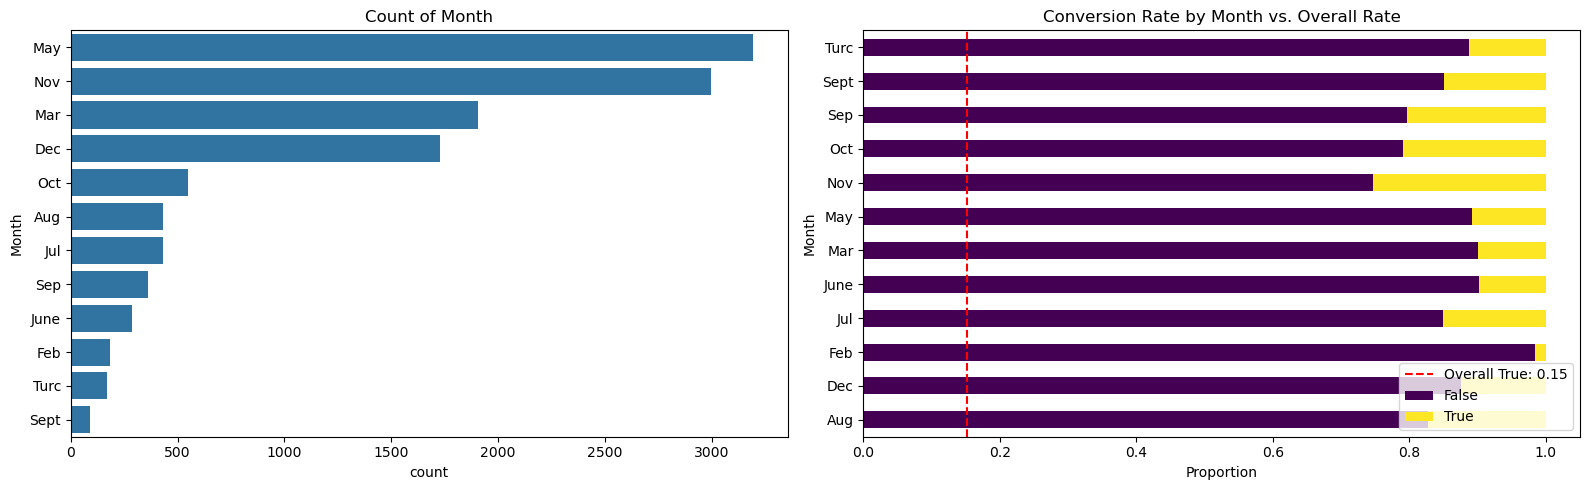


Feature: Weekend
Description: Boolean if the session day was in the weekend
Missing Values: 0 (0.00%)

Top 5 Categories:
Weekend
False        9273
True         2868
Name:Zara     189


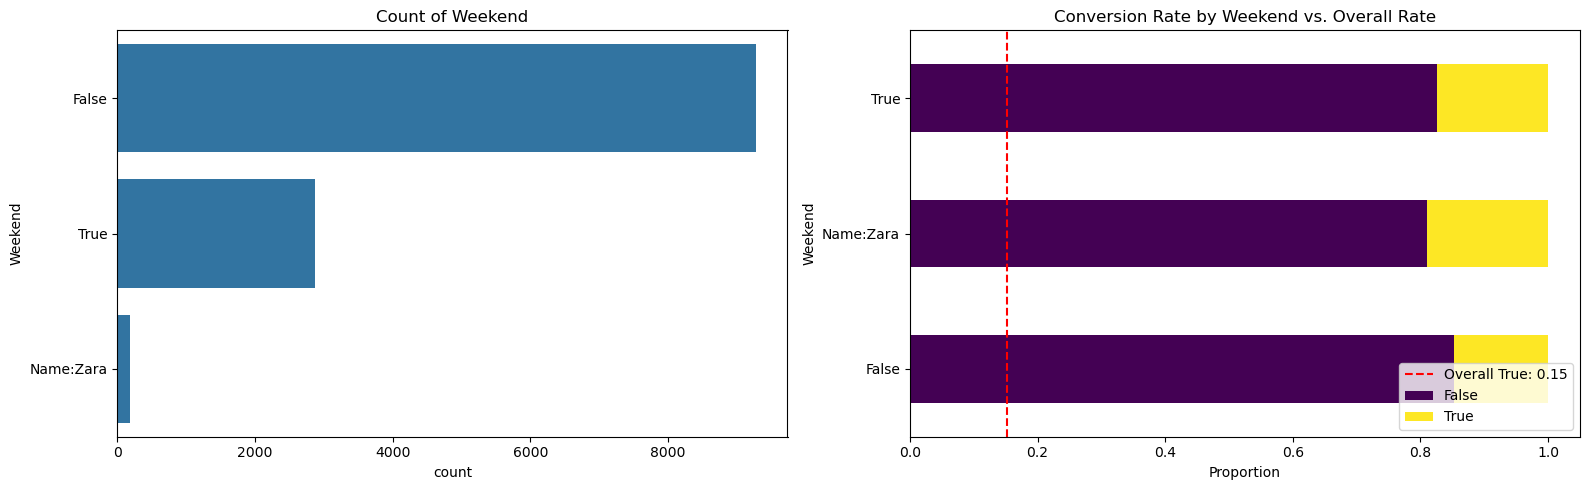


Feature: OperatingSystems
Description: Different OS' represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79


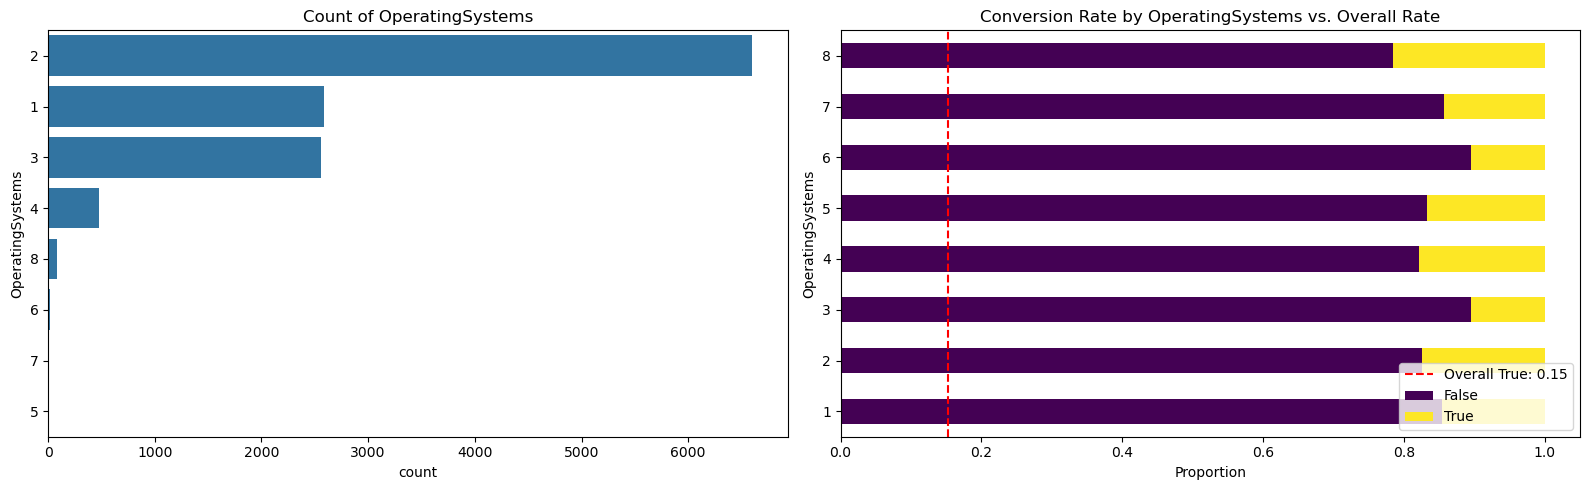


Feature: Browser
Description: Different browsers represented by different integers
Missing Values: 184 (1.49%)

Top 5 Categories:
Browser
2.0    7835
1.0    2424
4.0     725
5.0     465
6.0     171


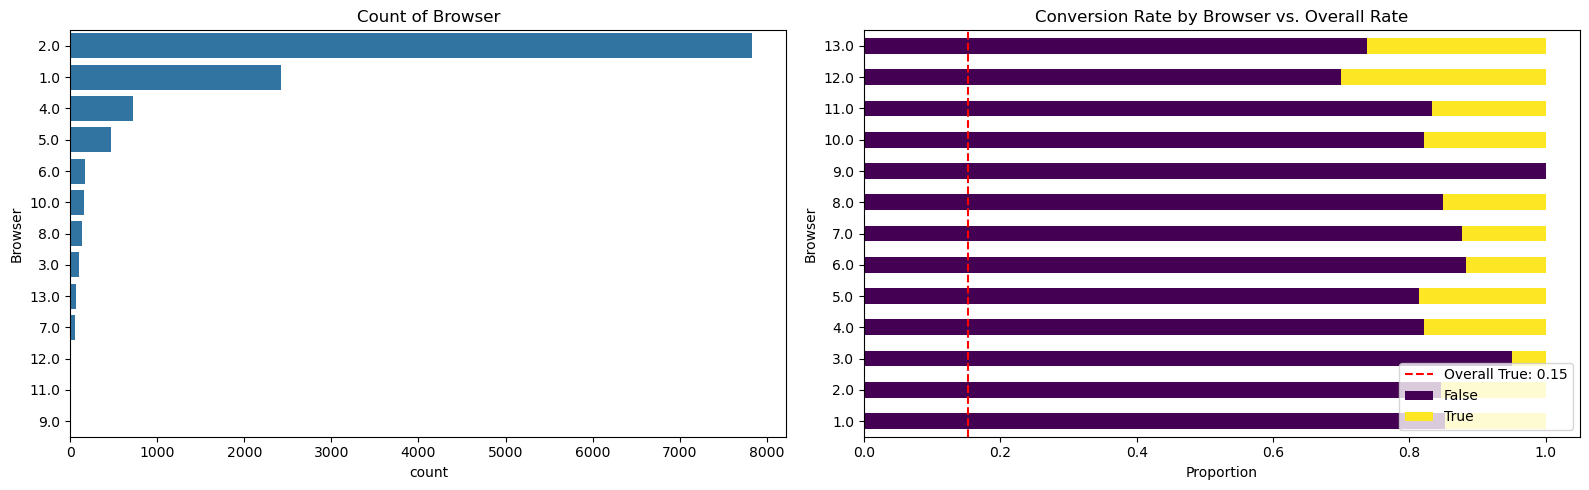


Feature: Region
Description: Different regions represented by different integers
Missing Values: 246 (2.00%)

Top 5 Categories:
Region
1.0    4695
3.0    2345
4.0    1157
2.0    1113
6.0     787


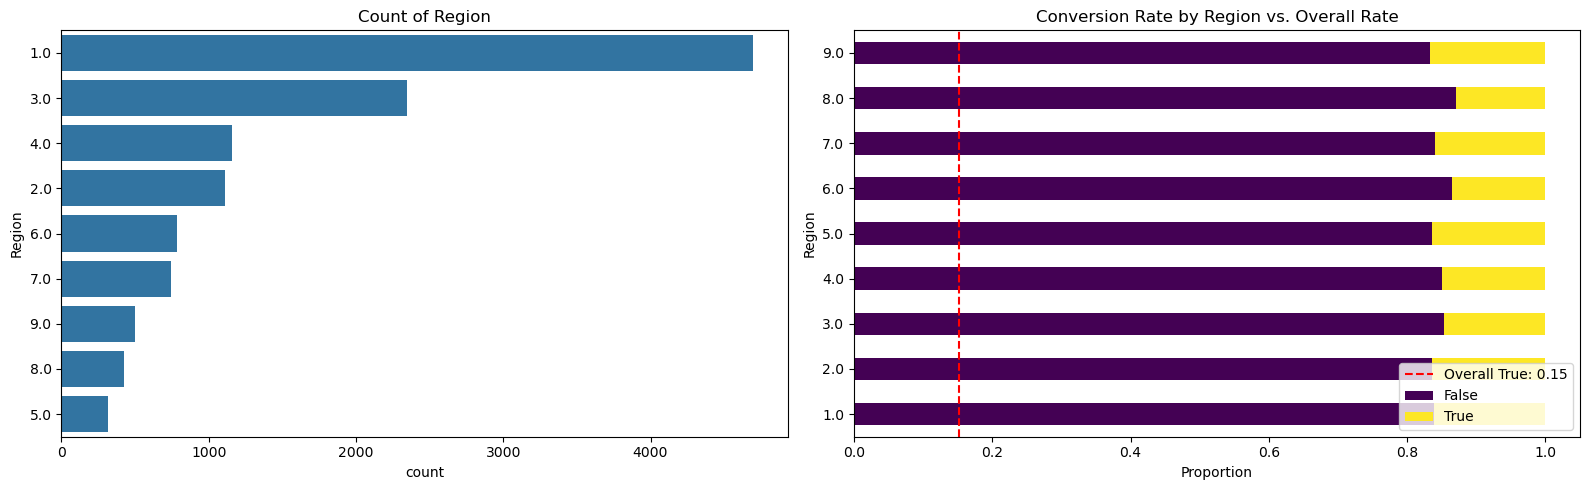


Feature: TrafficType
Description: Different traffic types represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738


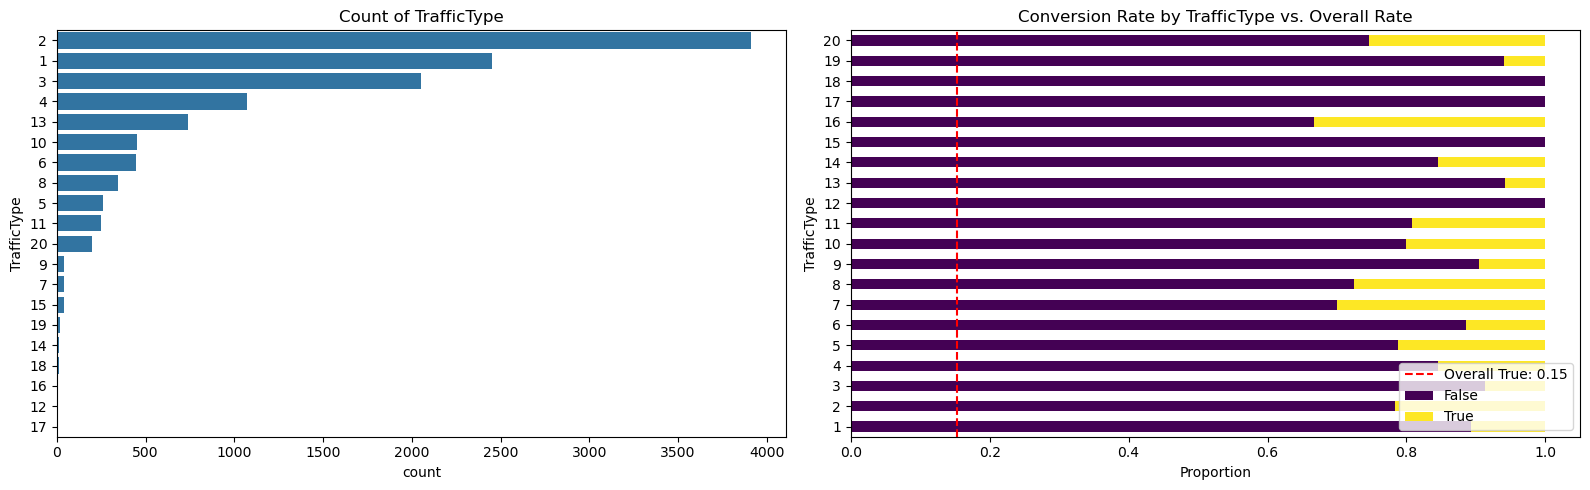


Feature: VisitorType
Description: Different visitor types represented by different categorical values
Missing Values: 0 (0.00%)

Top 5 Categories:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85


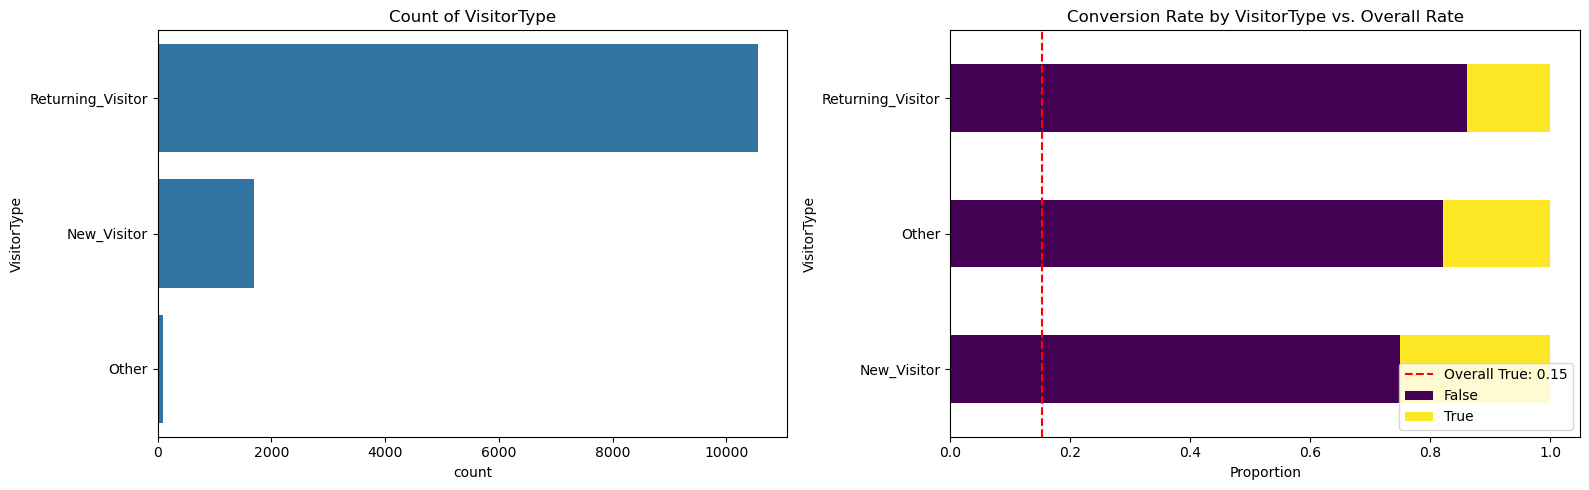

In [43]:
plot_feature_eda(session_data_df, column_descriptions)

In [44]:
def plot_feature_eda(df, column_descriptions, figsize=(16, 5), revenue_col='Revenue', n_cols=2):
    """
    Generates lightweight exploratory data analysis plots for each feature in the dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing all features
    column_descriptions : dict
        Dictionary with feature descriptions and types
    figsize : tuple, optional (default=(16, 5))
        Width, height of each row of plots
    revenue_col : str, optional (default='Revenue')
        Name of the target variable column
    n_cols : int, optional (default=2)
        Number of columns in the subplot grid
        
    Returns:
    --------
    None. Displays plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    
    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue  # Skip the target variable
            
        if isinstance(info, dict):  # If using the structured dictionary format
            if info["type"] == "numeric":
                numeric_features.append(col)
            else:
                categorical_features.append(col)
        else:  # If using the string-based format
            if "Type: numeric" in info:
                numeric_features.append(col)
            else:
                categorical_features.append(col)
    
    # Function to create plots for numeric features
    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Simple histogram with mean and median lines
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[0])
        
        # Add mean line (red dotted)
        mean_val = df[feature].mean()
        axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                       label=f'Mean: {mean_val:.2f}')
        
        # Add median line (green dotted) - using same style as mean line
        median_val = df[feature].median()
        axes[0].axvline(median_val, color='green', linestyle='--', linewidth=1.5,
                       label=f'Median: {median_val:.2f}')
        
        axes[0].legend(loc='best')
        axes[0].set_title(f'Distribution of {feature}')
        axes[0].set_xlabel(feature)
        
        # Right plot: Box plot by Revenue with mean and median annotations at the top
        sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
        
        # Add mean and median for each group at the top of the chart
        for i, rev_val in enumerate([False, True]):
            group_data = df[df[revenue_col] == rev_val][feature].dropna()
            
            if len(group_data) > 0:
                group_mean = group_data.mean()
                group_median = group_data.median()
                
                # Get y-axis limits to position annotations at the top
                ymin, ymax = axes[1].get_ylim()
                annotation_y = ymax - (ymax - ymin) * 0.05
                
                # Create combined annotation at the top
                axes[1].text(i, annotation_y, 
                           f"μ: {group_mean:.2f}\nm: {group_median:.2f}", 
                           ha='center', va='top', fontweight='bold',
                           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))
                
        axes[1].set_title(f'{feature} by {revenue_col}')
            
        plt.tight_layout()
        plt.show()
    
    # Function to create plots for categorical features
    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        
        # Left plot: Count plot with all categories
        order = df[feature].value_counts().index
        sns.countplot(y=feature, data=df, order=order, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)
        
        # Right plot: Stacked bar chart by Revenue showing comparison to overall conversion rate
        crosstab = pd.crosstab(df[feature], df[revenue_col], normalize='index')
        
        # Make sure True is always on the left side
        # First, identify which column corresponds to True (could be True or 'True')
        true_column = None
        if True in crosstab.columns:
            true_column = True
        elif 'True' in crosstab.columns:
            true_column = 'True'
            
        # Create custom color dictionary to ensure True always has the same color
        colors = {'True': 'gold', True: 'gold', 'False': 'steelblue', False: 'steelblue'}
        
        # Create the plot, with True first if possible
        if true_column is not None:
            # First create a new dataframe with columns in the order we want
            false_column = False if isinstance(true_column, bool) else 'False'
            columns_to_use = [col for col in crosstab.columns if col not in [true_column, false_column]]
            new_order = [true_column, false_column] + columns_to_use
            
            # Try to reorder - use only columns that exist
            available_columns = [col for col in new_order if col in crosstab.columns]
            try:
                ordered_crosstab = crosstab[available_columns]
                ordered_crosstab.plot(kind='barh', stacked=True, ax=axes[1], color=[colors.get(col, None) for col in available_columns])
            except:
                # Fallback if reordering fails
                crosstab.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
        else:
            # If we can't identify True column, just use the original dataframe
            crosstab.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
        
        # Calculate overall proportion of True/False in the dataset
        overall_true_proportion = df[revenue_col].mean() if df[revenue_col].dtype == bool else df[revenue_col].eq(True).mean()
        
        # Add a reference line for the overall proportion - now on the left side
        axes[1].axvline(x=overall_true_proportion, color='red', linestyle='--', linewidth=1.5,
                        label=f'Overall True: {overall_true_proportion:.2f}')
        
        axes[1].legend(loc='lower right')
        axes[1].set_title(f'Conversion Rate by {feature} vs. Overall Rate')
        axes[1].set_xlabel('Proportion')
        axes[1].set_ylabel(feature)
        
        plt.tight_layout()
        plt.show()
    
    # Function to show basic stats before plotting
    def plot_feature(feature):
        print(f"\n{'='*40}")
        
        # Extract and print feature description
        if isinstance(column_descriptions[feature], dict):
            desc = column_descriptions[feature]["description"]
        else:
            desc = column_descriptions[feature].split("Type:")[0].strip()
            
        print(f"Feature: {feature}")
        print(f"Description: {desc}")
        print(f"Missing Values: {df[feature].isna().sum()} ({df[feature].isna().mean():.2%})")
        
        if feature in numeric_features:
            # Print only basic summary statistics
            stats_df = pd.DataFrame({
                'Min': df[feature].min(),
                'Max': df[feature].max(),
                'Mean': df[feature].mean(),
                'Median': df[feature].median()
            }, index=[0])
            print("\nBasic Statistics:")
            print(stats_df.to_string(index=False))
            
            plot_numeric_feature(feature)
        else:
            # Print only top categories
            value_counts = df[feature].value_counts()
            print("\nTop 5 Categories:")
            print(value_counts.head(5).to_string())
            
            plot_categorical_feature(feature)
    
    # Plot each feature
    for feature in numeric_features + categorical_features:
        plot_feature(feature)


Feature: Administrative
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max   Mean  Median
 -10   27 2.2382     1.0


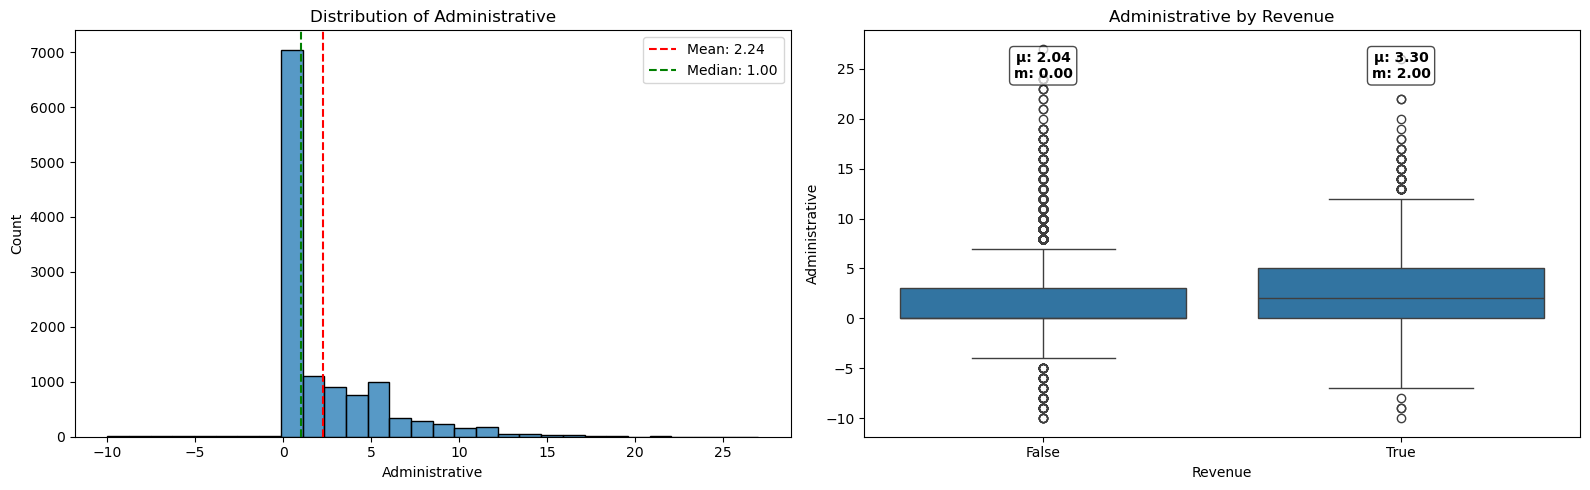


Feature: Administrative_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max        Mean  Median
 0.0 989493.0 1269.776004     8.0


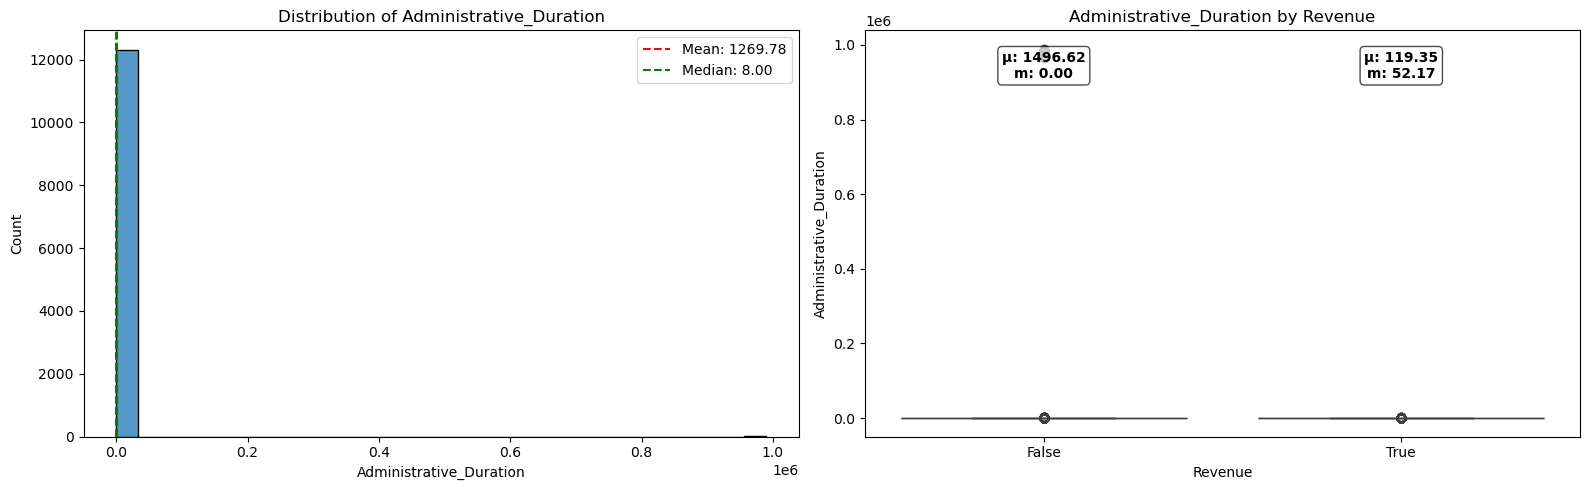


Feature: Informational
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean  Median
   0   24 0.503569     0.0


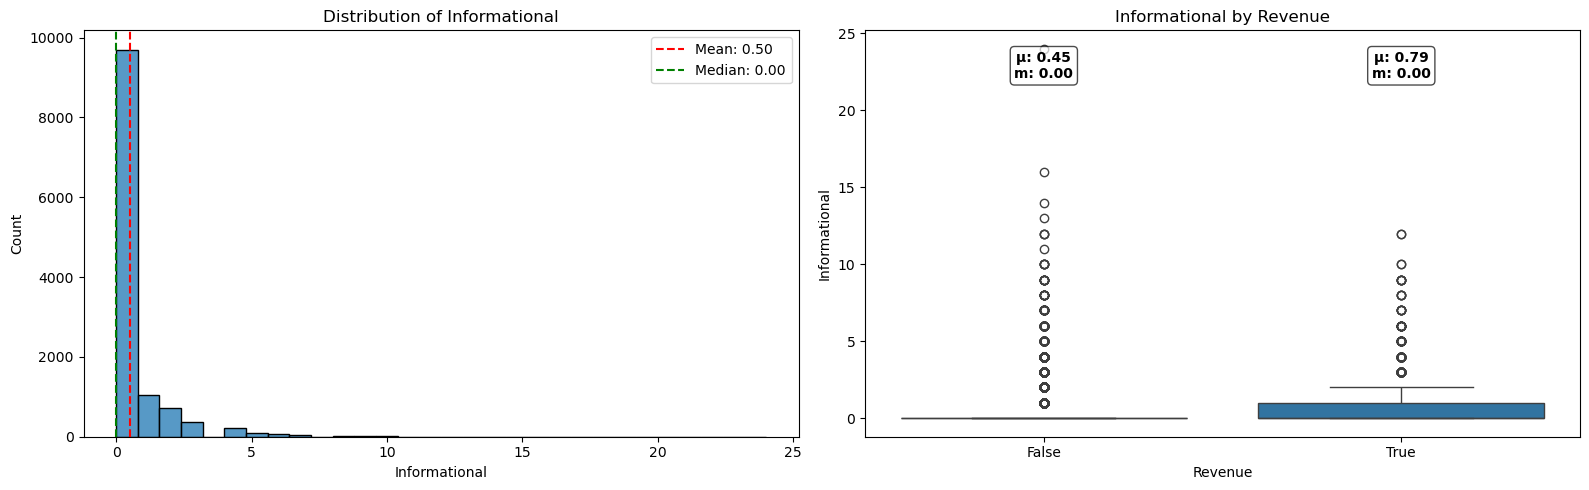


Feature: Informational_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min      Max      Mean  Median
 0.0 2549.375 34.472398     0.0


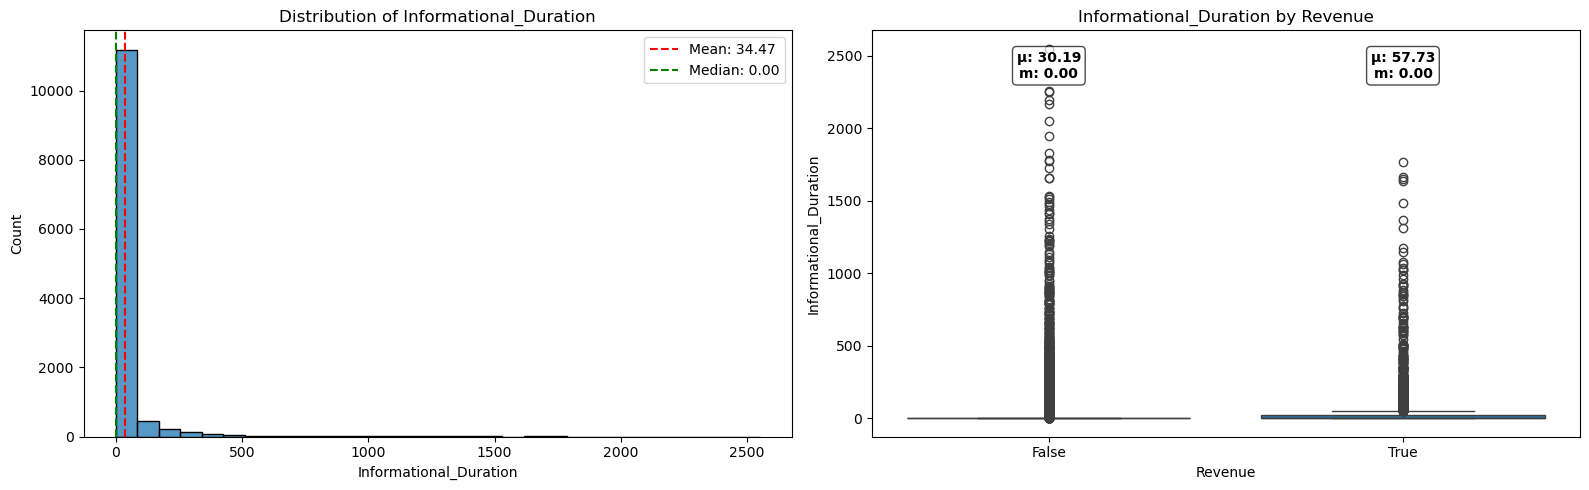


Feature: ProductRelated
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max      Mean  Median
   0  705 31.731468    18.0


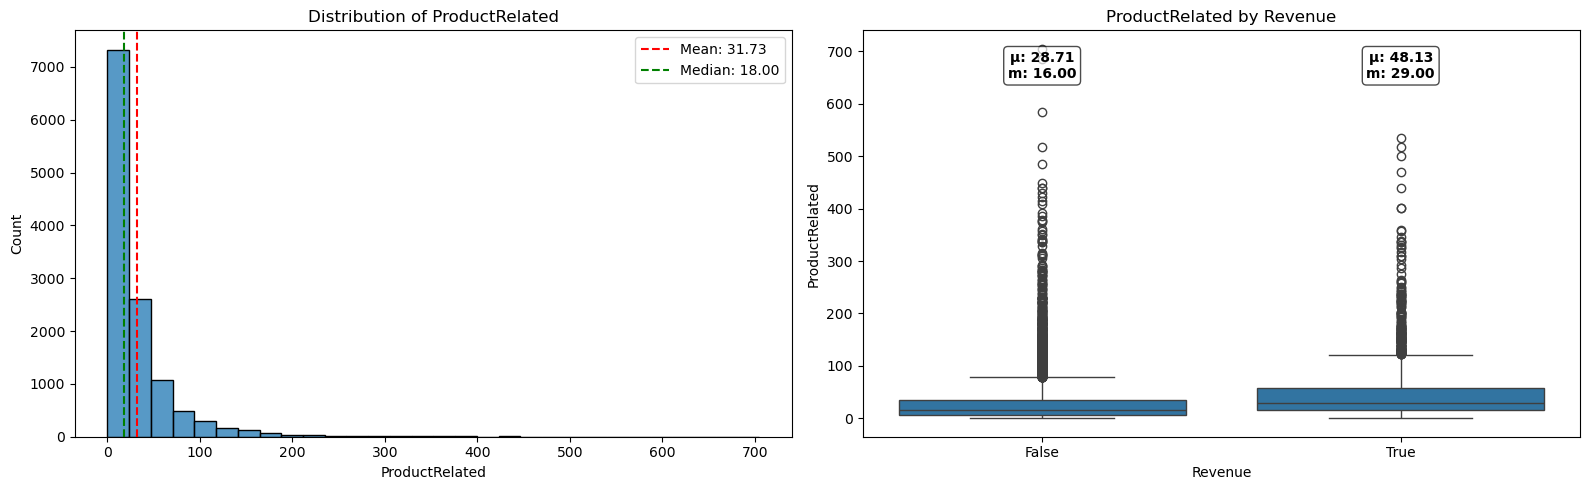


Feature: ProductRelated_Duration
Description: Time spent within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min         Max       Mean     Median
 0.0 63973.52223 1194.74622 598.936905


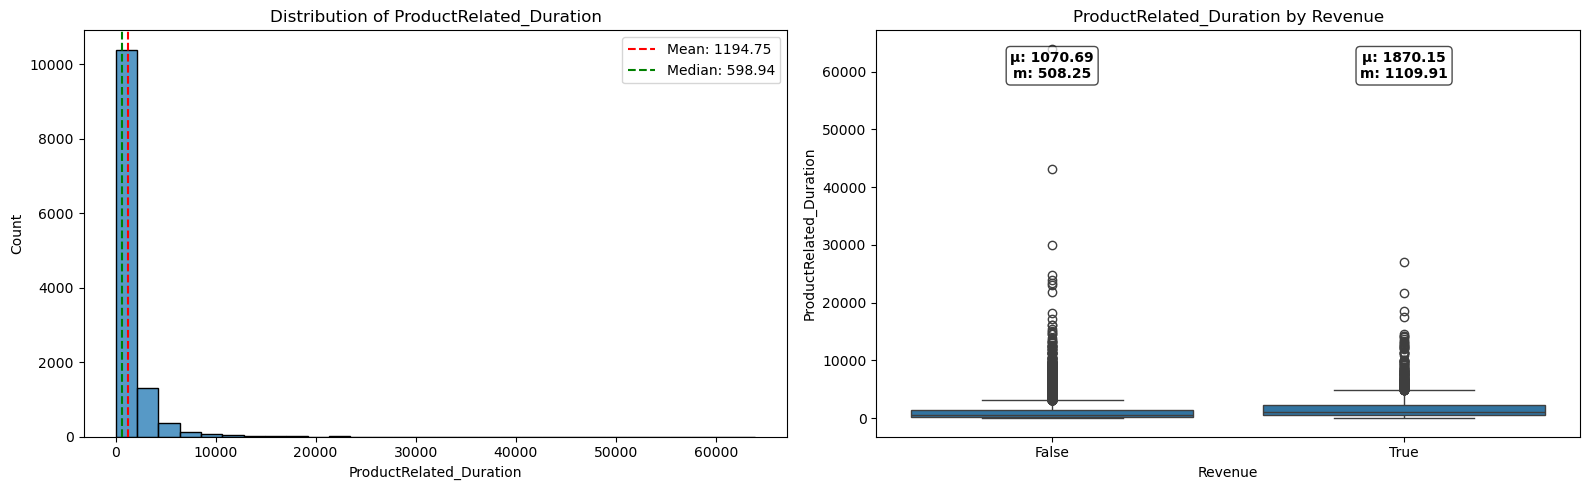


Feature: BounceRates
Description: Bounce rate of current page
Missing Values: 0 (0.00%)

Basic Statistics:
     Min      Max     Mean   Median
-0.49868 2.098952 0.044239 0.002896


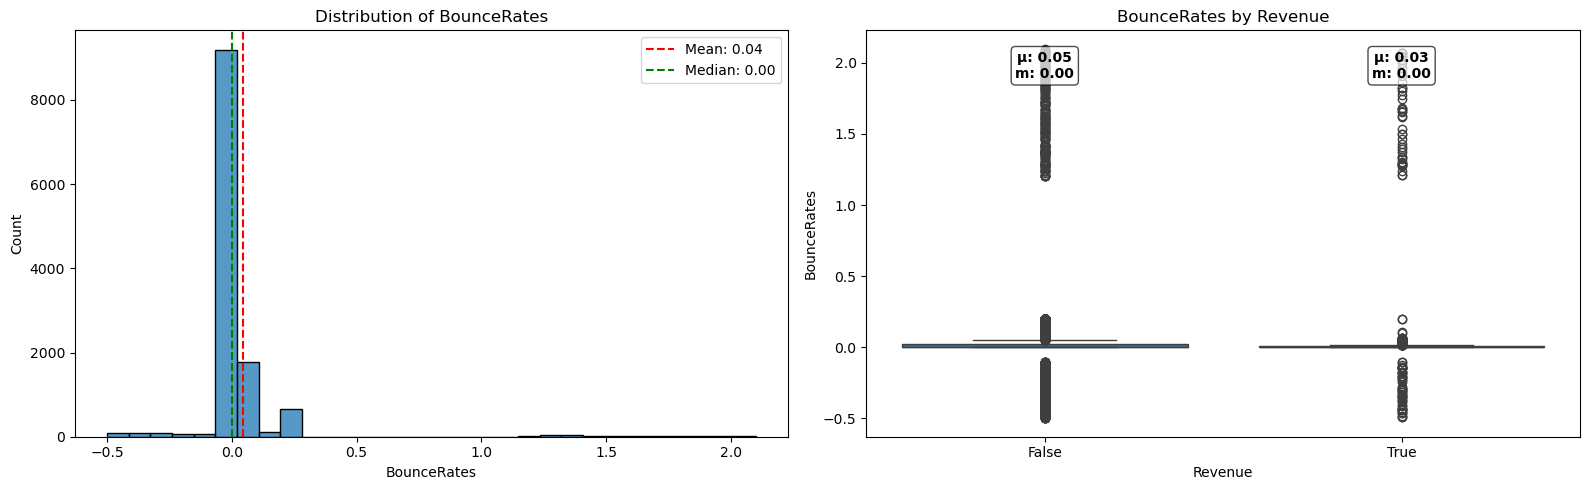


Feature: ExitRates
Description: Exit rate value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max     Mean   Median
 0.0  0.2 0.043073 0.025156


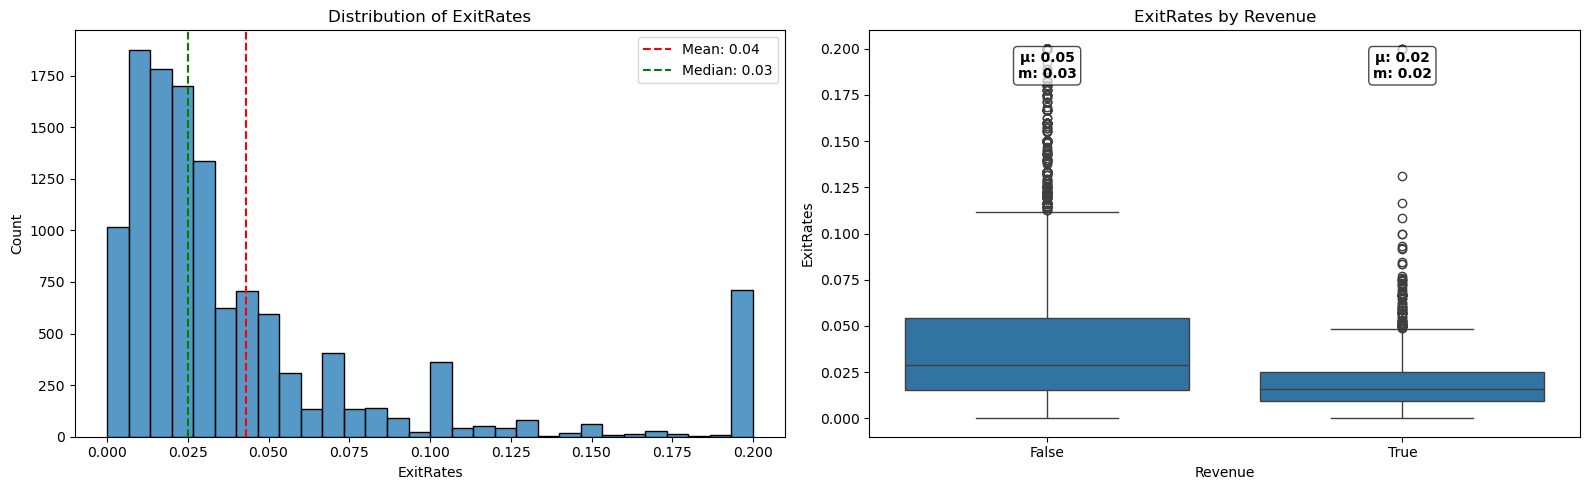


Feature: PageValues
Description: Page value of current page
Missing Values: 0 (0.00%)

Basic Statistics:
 Min        Max     Mean  Median
 0.0 361.763742 5.889258     0.0


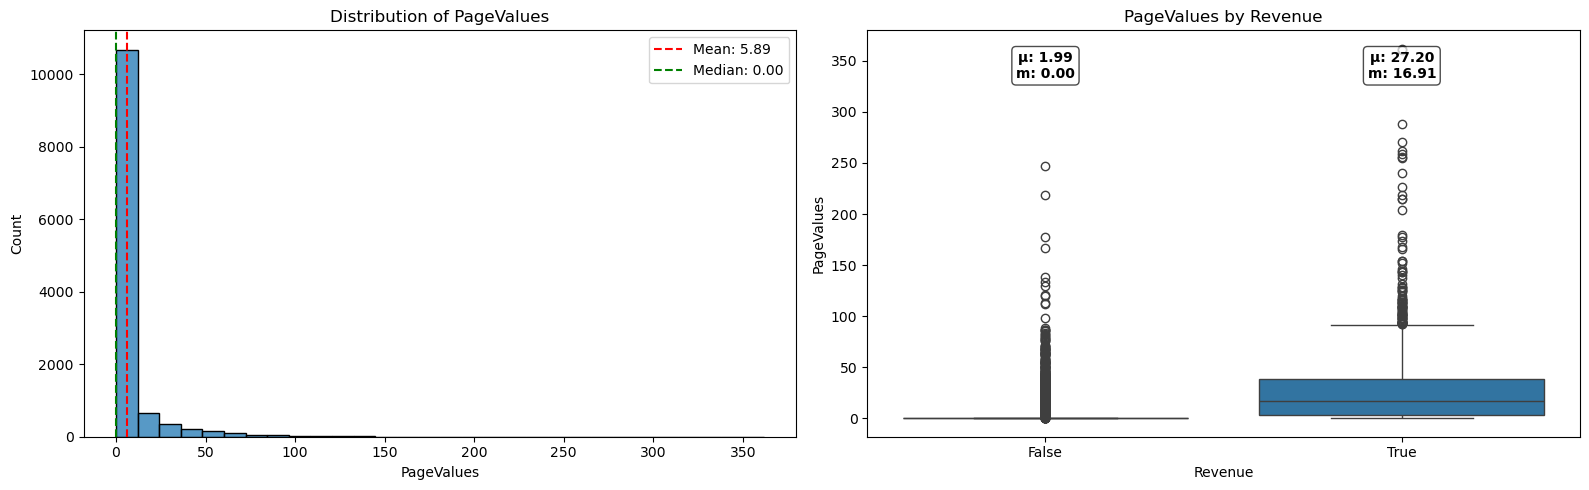


Feature: SpecialDay
Description: Proximity in time of the session to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina's day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8.
Missing Values: 123 (1.00%)

Basic Statistics:
 Min  Max    Mean  Median
 0.0  1.0 0.06126     0.0


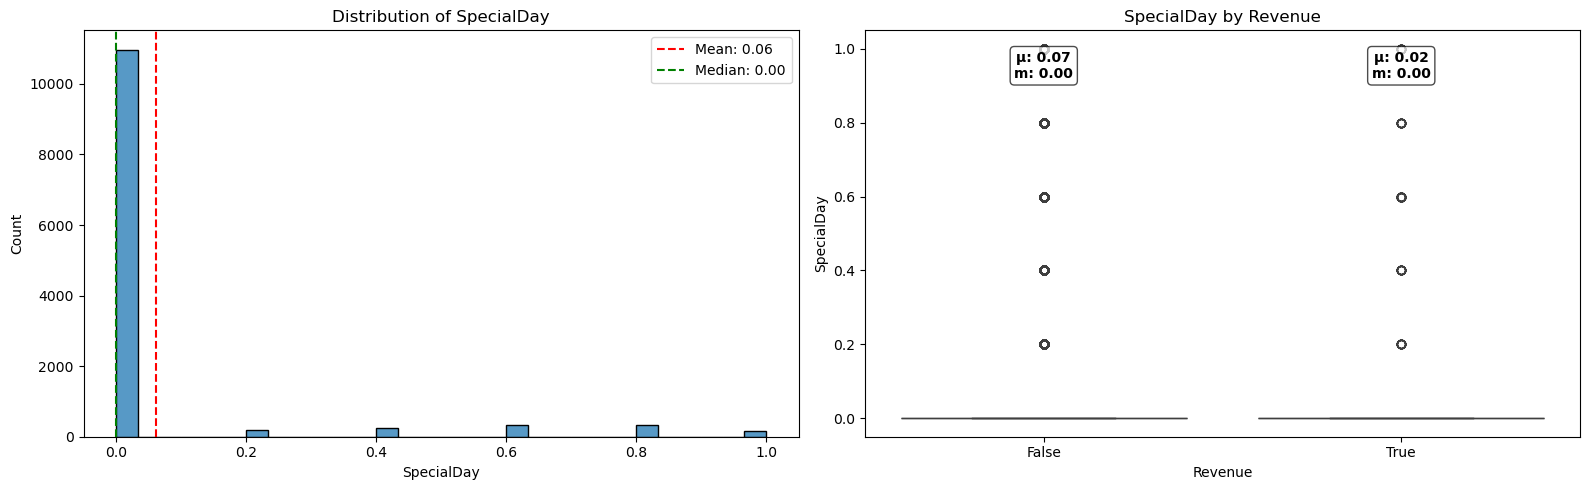


Feature: Month
Description: Month of session
Missing Values: 0 (0.00%)

Top 5 Categories:
Month
May    3196
Nov    2998
Mar    1907
Dec    1727
Oct     549


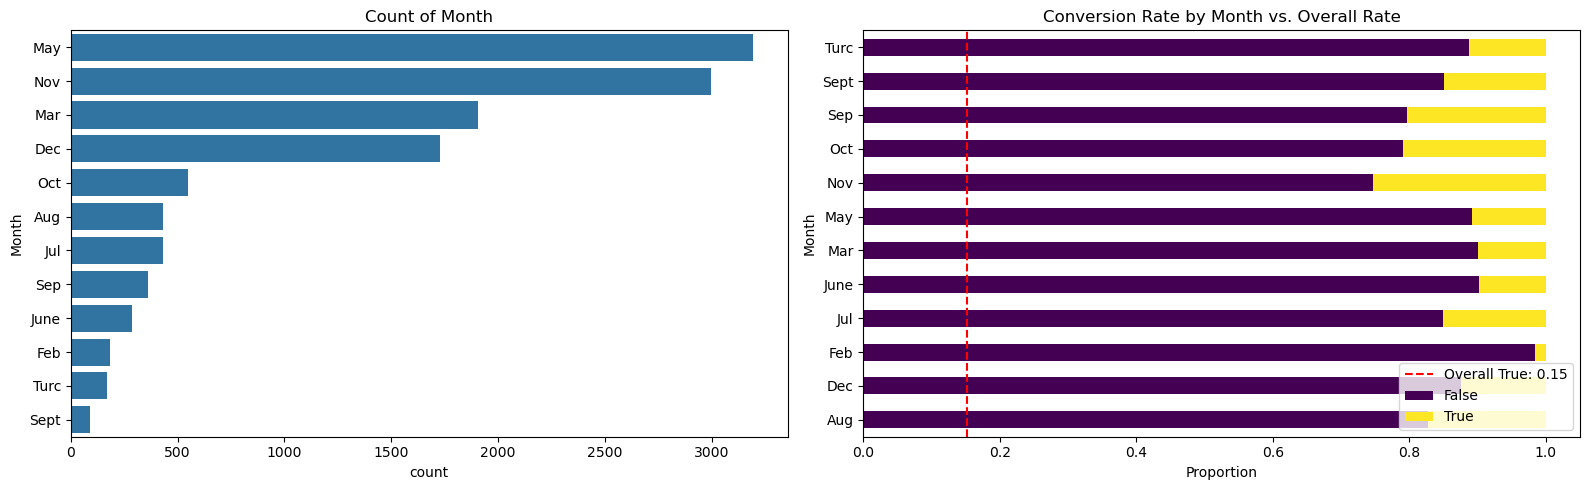


Feature: Weekend
Description: Boolean if the session day was in the weekend
Missing Values: 0 (0.00%)

Top 5 Categories:
Weekend
False        9273
True         2868
Name:Zara     189


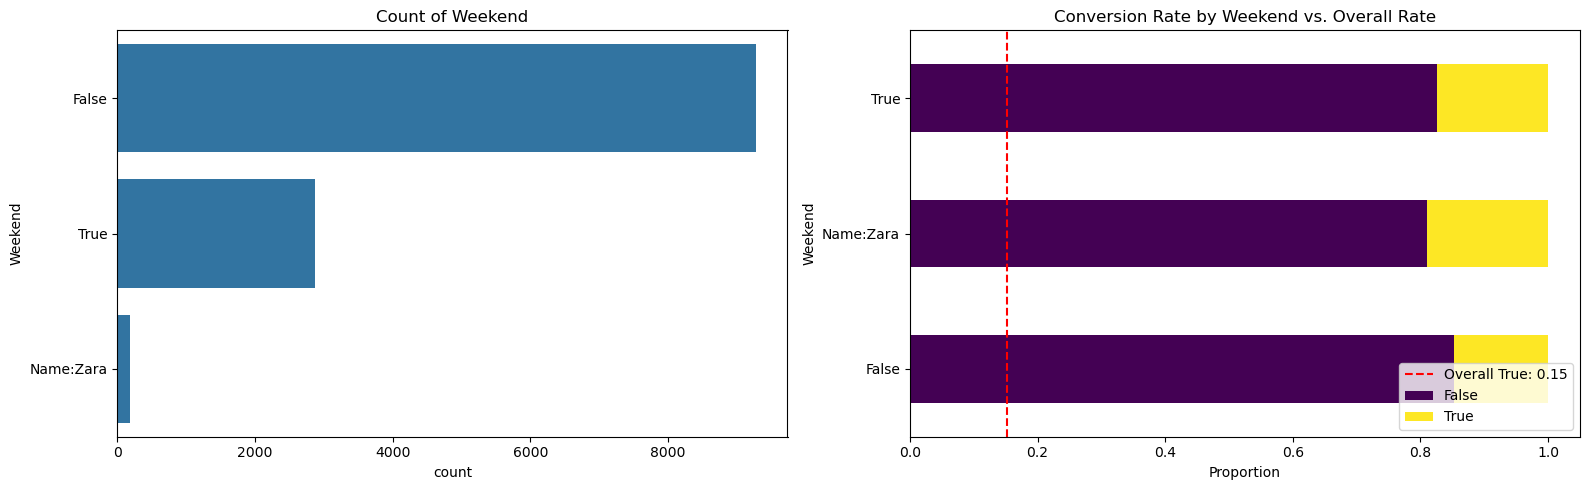


Feature: OperatingSystems
Description: Different OS' represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79


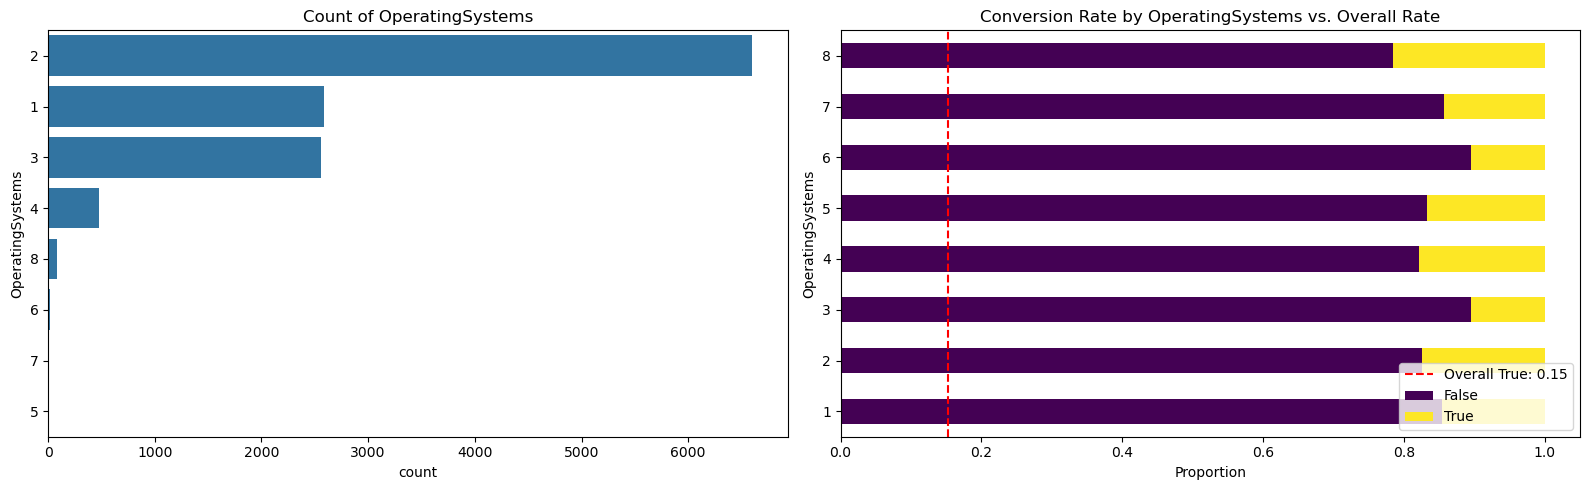


Feature: Browser
Description: Different browsers represented by different integers
Missing Values: 184 (1.49%)

Top 5 Categories:
Browser
2.0    7835
1.0    2424
4.0     725
5.0     465
6.0     171


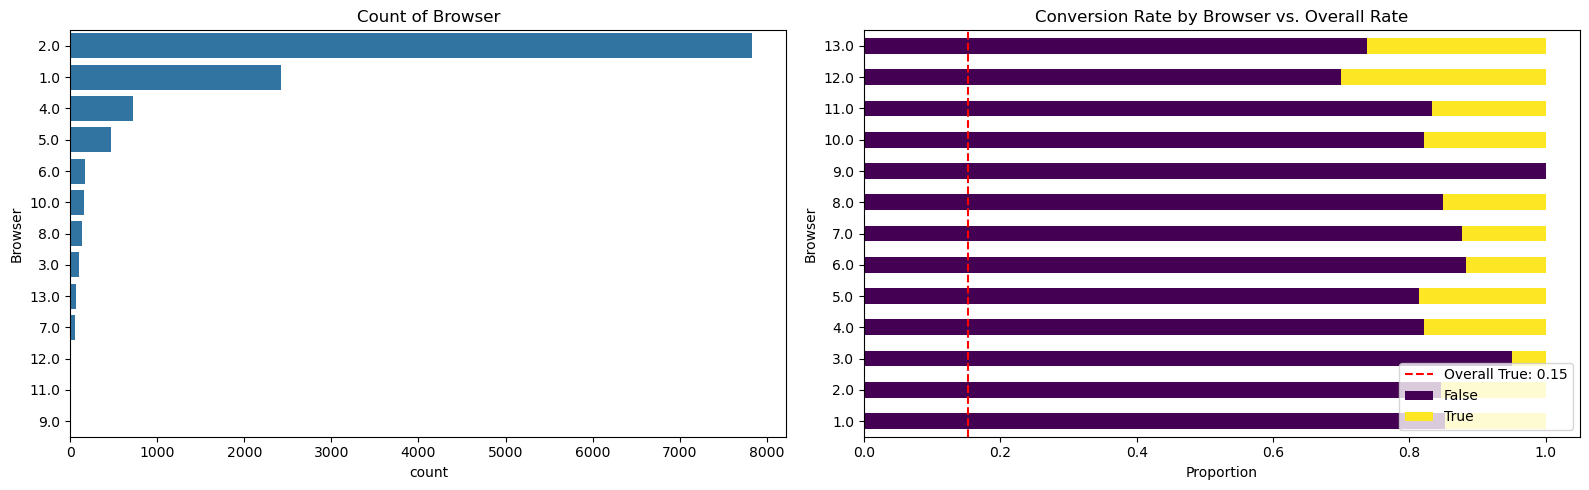


Feature: Region
Description: Different regions represented by different integers
Missing Values: 246 (2.00%)

Top 5 Categories:
Region
1.0    4695
3.0    2345
4.0    1157
2.0    1113
6.0     787


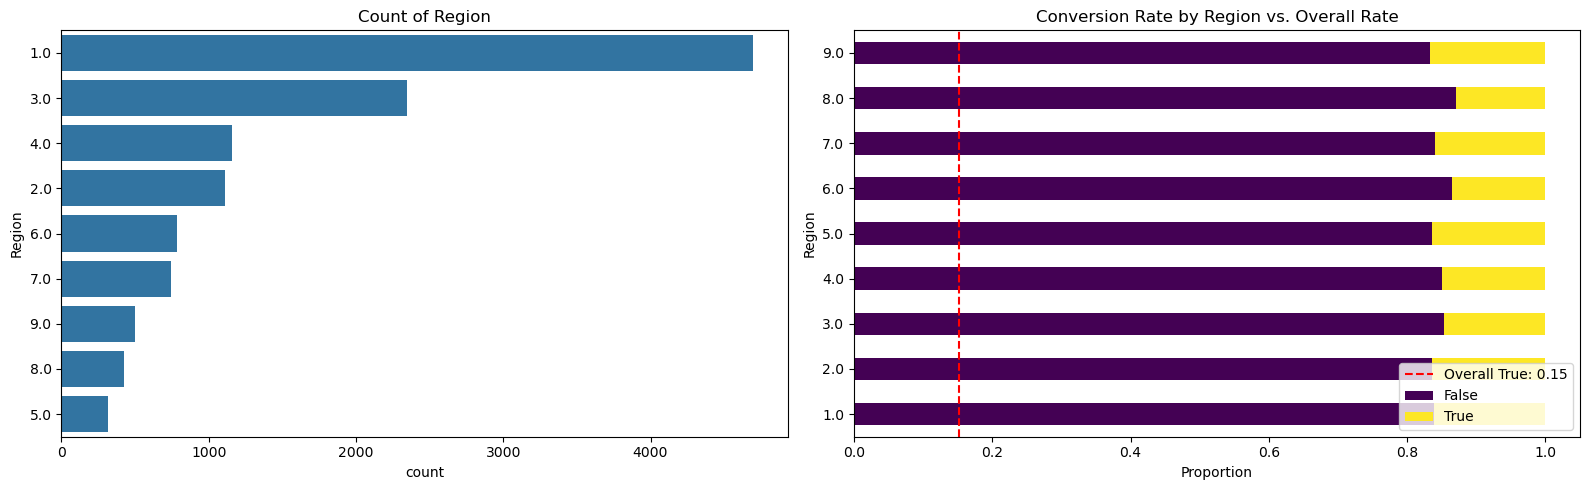


Feature: TrafficType
Description: Different traffic types represented by different integers
Missing Values: 0 (0.00%)

Top 5 Categories:
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738


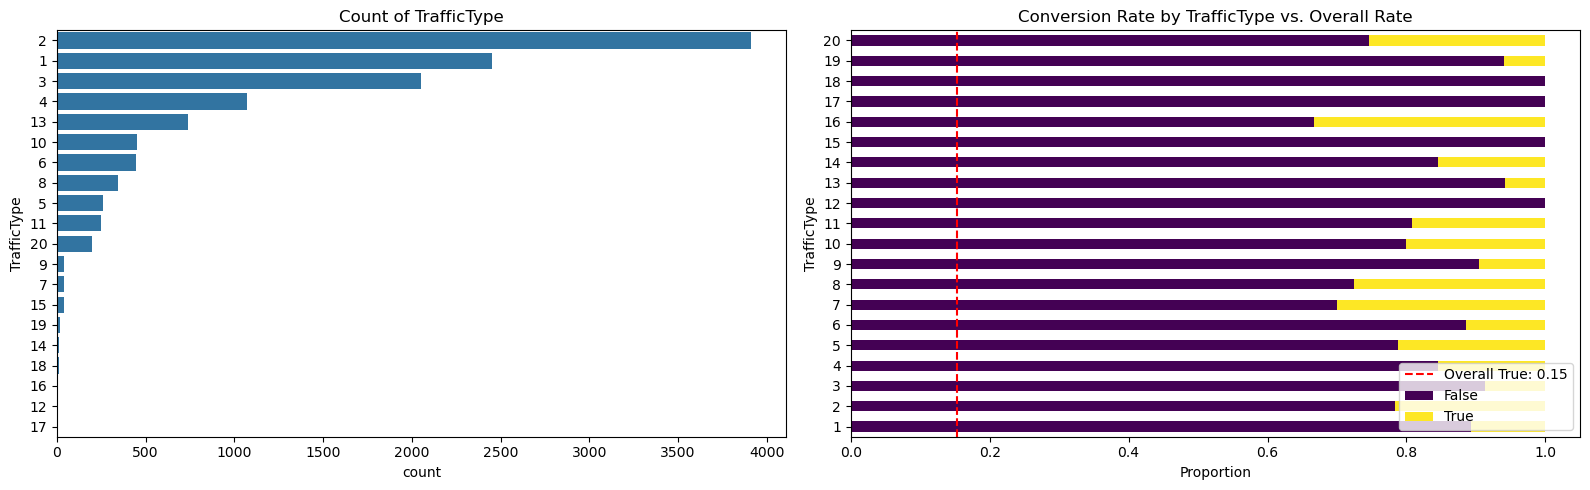


Feature: VisitorType
Description: Different visitor types represented by different categorical values
Missing Values: 0 (0.00%)

Top 5 Categories:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85


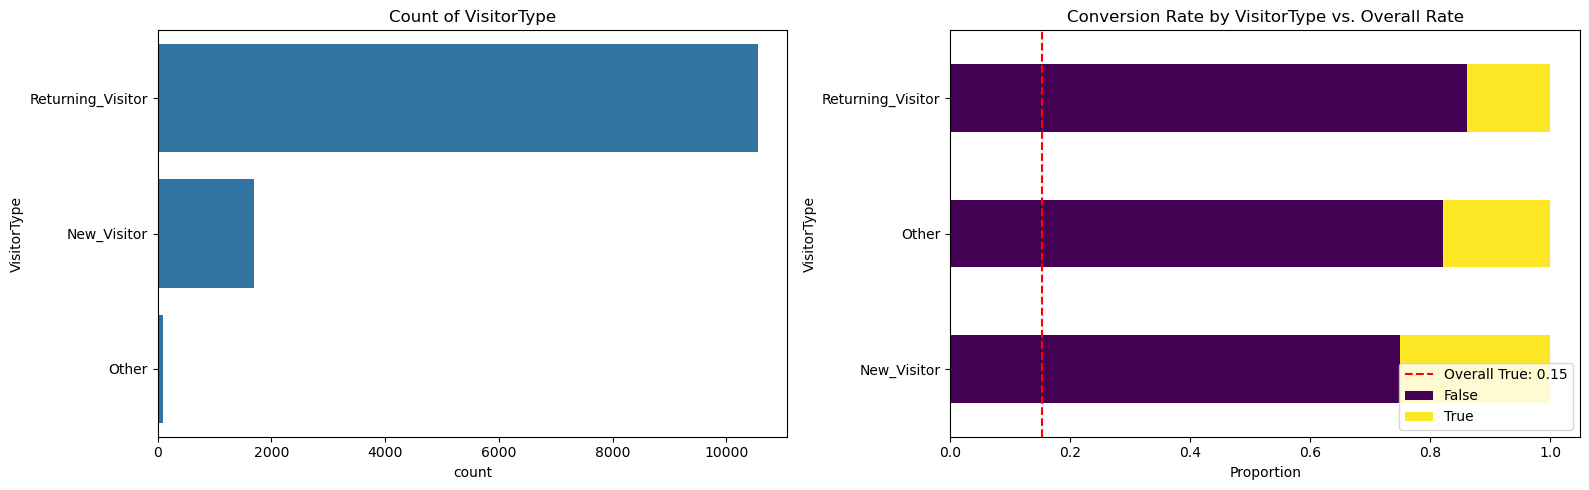

In [45]:
plot_feature_eda(session_data_df, column_descriptions)

In [46]:
def plot_feature_eda(df, column_descriptions, figsize=(16, 5), revenue_col='Revenue', n_cols=2):
    """
    Generates lightweight exploratory data analysis plots for each feature in the dataset.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Extract feature types from column_descriptions
    numeric_features = []
    categorical_features = []
    for col, info in column_descriptions.items():
        if col == revenue_col:
            continue
        # Only boolean check now
        if isinstance(info, dict) and info.get('type') == 'numeric':
            numeric_features.append(col)
        elif isinstance(info, str) and 'Type: numeric' in info:
            numeric_features.append(col)
        else:
            categorical_features.append(col)

    def plot_numeric_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        # Histogram
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[0])
        mean_val = df[feature].mean()
        median_val = df[feature].median()
        axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
        axes[0].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
        axes[0].legend(loc='best')
        axes[0].set_title(f'Distribution of {feature}')
        axes[0].set_xlabel(feature)

        # Box plot with annotations on right-hand side
        sns.boxplot(x=revenue_col, y=feature, data=df, ax=axes[1])
        xlim = axes[1].get_xlim()
        x_offset = (xlim[1] - xlim[0]) * 0.02
        for i, rev_val in enumerate([False, True]):
            group = df[df[revenue_col] == rev_val][feature].dropna()
            if not group.empty:
                g_mean = group.mean()
                g_med = group.median()
                # Position at group median, slightly to the right
                annotation_x = i + x_offset
                annotation_y = g_med
                textstr = (
                    r"$\color{red}{Mean: %.2f}$\n"
                    r"$\color{green}{Median: %.2f}$"
                ) % (g_mean, g_med)
                axes[1].text(
                    annotation_x, annotation_y, textstr,
                    ha='left', va='center', fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3')
                )
        axes[1].set_title(f'{feature} by {revenue_col}')
        plt.tight_layout()
        plt.show()

    def plot_categorical_feature(feature):
        fig, axes = plt.subplots(1, n_cols, figsize=figsize)
        # Count plot
        order = df[feature].value_counts().index
        sns.countplot(y=feature, data=df, order=order, ax=axes[0])
        axes[0].set_title(f'Count of {feature}')
        axes[0].set_ylabel(feature)

        # Stacked bar: True on left
        crosstab = pd.crosstab(df[feature], df[revenue_col], normalize='index')
        # Only boolean columns
        cols = [col for col in [True, False] if col in crosstab.columns]
        ordered = crosstab[cols]
        colors = ['gold', 'steelblue'][:len(cols)]
        ordered.plot(kind='barh', stacked=True, ax=axes[1], color=colors)

        overall_true = df[revenue_col].mean()
        axes[1].axvline(overall_true, color='red', linestyle='--', linewidth=1.5,
                        label=f'Overall True: {overall_true:.2f}')
        axes[1].legend(loc='lower right')
        axes[1].set_title(f'Conversion Rate by {feature} vs. Overall Rate')
        axes[1].set_xlabel('Proportion')
        axes[1].set_ylabel(feature)
        plt.tight_layout()
        plt.show()

    def plot_feature(feature):
        print(f"\n{'='*40}")
        info = column_descriptions[feature]
        desc = info.get('description') if isinstance(info, dict) else info.split('Type:')[0].strip()
        print(f"Feature: {feature}\nDescription: {desc}")
        miss = df[feature].isna().sum()
        print(f"Missing Values: {miss} ({miss/len(df):.2%})")

        if feature in numeric_features:
            stats = pd.DataFrame({
                'Min': [df[feature].min()],
                'Max': [df[feature].max()],
                'Mean': [df[feature].mean()],
                'Median': [df[feature].median()]
            })
            print("\nBasic Statistics:")
            print(stats.to_string(index=False))
            plot_numeric_feature(feature)
        else:
            print("\nTop 5 Categories:")
            print(df[feature].value_counts().head(5).to_string())
            plot_categorical_feature(feature)

    for feat in numeric_features + categorical_features:
        plot_feature(feat)


In [47]:
plot_feature_eda(session_data_df, column_descriptions)


Feature: Administrative
Description: Number of page visits within this category
Missing Values: 0 (0.00%)

Basic Statistics:
 Min  Max   Mean  Median
 -10   27 2.2382     1.0


ValueError: 
\color{red}{Mean: 2.04}
^
ParseFatalException: Unknown symbol: \color, found '\'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x000002192F3D39C0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
\color{red}{Mean: 2.04}
^
ParseFatalException: Unknown symbol: \color, found '\'  (at char 0), (line:1, col:1)

ValueError: 
\color{red}{Mean: 2.04}
^
ParseFatalException: Unknown symbol: \color, found '\'  (at char 0), (line:1, col:1)

<Figure size 1600x500 with 2 Axes>